<a href="https://colab.research.google.com/github/radomskia/Kod_Historyka/blob/main/BadaniaNLP_Nowa_ksi%C4%85%C5%BCka_pnb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:


# Wczytaj dokument Worda
doc = Document("King.docx")

# Wyodrębnij i połącz tekst z paragrafów
full_text = []
for para in doc.paragraphs:
    full_text.append(para.text)

# Połącz wszystko w jeden ciąg tekstowy
text = "\n".join(full_text)
print(text)


In [ ]:
!pip install python-docx
from docx import Document

# Wczytaj dokument Worda
doc = Document("King.docx")

# Wyodrębnij i połącz tekst z paragrafów
full_text = []
for para in doc.paragraphs:
    full_text.append(para.text)

# Połącz wszystko w jeden ciąg tekstowy
text = "\n".join(full_text)
print(text)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.3/244.3 kB 3.7 MB/s eta 0:00:00

DR. MARTIN LUTHER KING, JR. – AUGUST 28, 1963
I am happy to join with you today in what will go down in history as the greatest demonstration for freedom in the history of our
nation.
Five score years ago, a great American, in whose symbolic shadow we stand today, signed the Emancipation Proclamation. This
momentous decree came as a great beacon of hope to millions of slaves, who had been seared in the flames of whithering
injustice. It came as a joyous daybreak to end the long night of their captivity. But one hundred years later, the colored America is
still not free. One hundred years later, the life of the colored American is still sadly crippled by the manacle of segregation and
the chains of discrimination.
One hundred years later, the colored American lives on a lonely island of poverty in the midst of a vast ocean of material
prosperity. One hundred years later, the colored American is still langui

In [ ]:
# prompt: napisz kod w Python po polski, ktory dokona analizy sentymentu i polaryzacja tekstu z pliku: King.docx

import numpy as np
!pip install spacy textblob
!python -m textblob.download_corpora
!python -m spacy download pl_core_news_sm

from textblob import TextBlob
import spacy

# Załaduj model języka polskiego
nlp = spacy.load("pl_core_news_sm")

# Analiza sentymentu
# TextBlob najlepiej działa z językiem angielskim, ale spróbujemy użyć go bezpośrednio na polskim tekście
# Alternatywnie można przetłumaczyć tekst na angielski przed analizą sentymentu.

# Tworzenie obiektu TextBlob z tekstem
blob = TextBlob(text)

# Analiza sentymentu (polarity - polaryzacja od -1 (negatywny) do 1 (pozytywny))
# Subiektywność (subjectivity - od 0 (obiektywny) do 1 (subiektywny))
try:
    # TextBlob może mieć problemy z polskim, jeśli korpusy nie są odpowiednie
    # Możemy spróbować przetłumaczyć na angielski i analizować
    translated_text = str(blob.translate(to='en'))
    translated_blob = TextBlob(translated_text)
    polaryzacja = translated_blob.sentiment.polarity
    subiektywnosc = translated_blob.sentiment.subjectivity
except Exception as e:
    print(f"Błąd podczas analizy sentymentu lub tłumaczenia: {e}")
    polaryzacja = "Nie można obliczyć"
    subiektywnosc = "Nie można obliczyć"


print(f"\nAnaliza Sentymentu:")
print(f"Polaryzacja (Polarity): {polaryzacja}")
print(f"Subiektywność (Subjectivity): {subiektywnosc}")

# Aby uzyskać bardziej zaawansowaną analizę sentymentu w języku polskim,
# należałoby użyć modeli i narzędzi dedykowanych dla języka polskiego,
# np. modeli opartych na uczeniu maszynowym wytrenowanych na polskich korpusach.
# TextBlob w dużej mierze opiera się na korpusach NLTK, które są głównie angielskie.

# Poniżej przykład jak można by przetworzyć tekst za pomocą spaCy dla innych celów (np. ekstrakcja nazw, fraz),
# ale spaCy domyślnie nie dostarcza gotowego narzędzia do analizy sentymentu w języku polskim.

doc_spacy = nlp(text)

# Przykład użycia spaCy - identyfikacja jednostek nazwanych
# print("\nJednostki nazwane:")
# for ent in doc_spacy.ents:
#     print(f"{ent.text} ({ent.label_})")

# Przykład użycia spaCy - tokenizacja i lematyzacja
# print("\nTokenizacja i Lematyzacja (pierwsze 20 tokenów):")
# for token in doc_spacy[:20]:
#      print(f"{token.text} -> {token.lemma_}")



[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
Finished.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 33.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pl_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all t

In [ ]:
# prompt: a teraz napisz kod, który dokona analizy sentymentu i polaryzacji tego tekstu powyżej

!pip install transformers
# prompt: a teraz napisz kod, który dokona analizy sentymentu i polaryzacji tego tekstu powyżej

!pip install transformers
!pip install torch

from transformers import pipeline

# Utworzenie potoku do analizy sentymentu
# You can specify a model here if you need one with a larger sequence length,
# but for demonstration, we'll use the default and split the text.
sentiment_analyzer = pipeline("sentiment-analysis")

# Define the maximum sequence length for the model (usually 512 for default models like distilbert)
max_seq_length = 512

# Split the text into chunks that fit within the maximum sequence length
# A simple approach is to split by sentences or a fixed number of tokens/characters
# A more robust approach would use the tokenizer's max length and handle overlap
# For this example, we'll do a simple split based on character count
text_chunks = []
current_chunk = ""
for sentence in text.split('.'): # Splitting by sentence as a simple approach
    if len(current_chunk) + len(sentence) + 1 <= max_seq_length: # +1 for the dot
        current_chunk += sentence + "."
    else:
        text_chunks.append(current_chunk.strip())
        current_chunk = sentence + "."

if current_chunk.strip():
    text_chunks.append(current_chunk.strip())

# Analiza sentymentu dla każdego fragmentu
sentiment_results = []
for chunk in text_chunks:
    if chunk: # Ensure chunk is not empty
        try:
            result = sentiment_analyzer(chunk)
            sentiment_results.append(result[0]) # sentiment_analyzer returns a list with one dict
        except Exception as e:
            print(f"Error analyzing chunk: {chunk[:100]}... Error: {e}")


# Wypisanie wyników dla każdego fragmentu
for i, result in enumerate(sentiment_results):
    print(f"Chunk {i+1}: Label: {result['label']}, Score: {result['score']:.4f}")

# Optional: Summarize the overall sentiment (e.g., average score or count of positive/negative)
positive_count = sum(1 for r in sentiment_results if r['label'] == 'POSITIVE')
negative_count = sum(1 for r in sentiment_results if r['label'] == 'NEGATIVE')
neutral_count = sum(1 for r in sentiment_results if r['label'] == 'NEUTRAL') # Default model doesn't have neutral

print(f"\nOverall Summary:")
print(f"Positive chunks: {positive_count}")
print(f"Negative chunks: {negative_count}")
# print(f"Neutral chunks: {neutral_count}") # Uncomment if using a model with a neutral label

# You might want to store or process sentiment_results further
# For instance, calculate the average sentiment score if the model provides scores
# prompt: a teraz napisz kod, który dokona analizy sentymentu i polaryzacji tego tekstu powyżej

!pip install transformers
!pip install torch

from transformers import pipeline

# Utworzenie potoku do analizy sentymentu
# You can specify a model here if you need one with a larger sequence length,
# but for demonstration, we'll use the default and split the text.
sentiment_analyzer = pipeline("sentiment-analysis")

# Define the maximum sequence length for the model (usually 512 for default models like distilbert)
max_seq_length = 512

# Split the text into chunks that fit within the maximum sequence length
# A simple approach is to split by sentences or a fixed number of tokens/characters
# A more robust approach would use the tokenizer's max length and handle overlap
# For this example, we'll do a simple split based on character count
text_chunks = []
current_chunk = ""
for sentence in text.split('.'): # Splitting by sentence as a simple approach
    if len(current_chunk) + len(sentence) + 1 <= max_seq_length: # +1 for the dot
        current_chunk += sentence + "."
    else:
        text_chunks.append(current_chunk.strip())
        current_chunk = sentence + "."

if current_chunk.strip():
    text_chunks.append(current_chunk.strip())

# Analiza sentymentu dla każdego fragmentu
sentiment_results = []
for chunk in text_chunks:
    if chunk: # Ensure chunk is not empty
        try:
            result = sentiment_analyzer(chunk)
            sentiment_results.append(result[0]) # sentiment_analyzer returns a list with one dict
        except Exception as e:
            print(f"Error analyzing chunk: {chunk[:100]}... Error: {e}")


# Wypisanie wyników dla każdego fragmentu
for i, result in enumerate(sentiment_results):
    print(f"Chunk {i+1}: Label: {result['label']}, Score: {result['score']:.4f}")

# Optional: Summarize the overall sentiment (e.g., average score or count of positive/negative)
positive_count = sum(1 for r in sentiment_results if r['label'] == 'POSITIVE')
negative_count = sum(1 for r in sentiment_results if r['label'] == 'NEGATIVE')
neutral_count = sum(1 for r in sentiment_results if r['label'] == 'NEUTRAL') # Default model doesn't have neutral

print(f"\nOverall Summary:")
print(f"Positive chunks: {positive_count}")
print(f"Negative chunks: {negative_count}")
# print(f"Neutral chunks: {neutral_count}") # Uncomment if using a model with a neutral label

# You might want to store or process sentiment_results further
# For instance, calculate the average sentiment score if the model provides scores
max_seq_length = 512

# Split the text into chunks that fit within the maximum sequence length
# A simple approach is to split by sentences or a fixed number of tokens/characters
# A more robust approach would use the tokenizer's max length and handle overlap
# For this example, we'll do a simple split based on character count
text_chunks = []
current_chunk = ""
for sentence in text.split('.'): # Splitting by sentence as a simple approach
    if len(current_chunk) + len(sentence) + 1 <= max_seq_length: # +1 for the dot
        current_chunk += sentence + "."
    else:
        text_chunks.append(current_chunk.strip())
        current_chunk = sentence + "."

if current_chunk.strip():
    text_chunks.append(current_chunk.strip())

# Analiza sentymentu dla każdego fragmentu
sentiment_results = []
for chunk in text_chunks:
    if chunk: # Ensure chunk is not empty
        try:
            result = sentiment_analyzer(chunk)
            sentiment_results.append(result[0]) # sentiment_analyzer returns a list with one dict
        except Exception as e:
            print(f"Error analyzing chunk: {chunk[:100]}... Error: {e}")


# Wypisanie wyników dla każdego fragmentu
for i, result in enumerate(sentiment_results):
    print(f"Chunk {i+1}: Label: {result['label']}, Score: {result['score']:.4f}")

# Optional: Summarize the overall sentiment (e.g., average score or count of positive/negative)
positive_count = sum(1 for r in sentiment_results if r['label'] == 'POSITIVE')
negative_count = sum(1 for r in sentiment_results if r['label'] == 'NEGATIVE')
neutral_count = sum(1 for r in sentiment_results if r['label'] == 'NEUTRAL') # Default model doesn't have neutral

print(f"\nOverall Summary:")
print(f"Positive chunks: {positive_count}")
print(f"Negative chunks: {negative_count}")
# print(f"Neutral chunks: {neutral_count}") # Uncomment if using a model with a neutral label

# You might want to store or process sentiment_results further
# For instance, calculate the average sentiment score if the model provides scores


SyntaxError: invalid non-printable character U+00A0 (<ipython-input-9-805b37e8cfed>, line 64)

In [ ]:
import pandas as pd


In [ ]:
dane = pd.read_csv('King.csv')

In [ ]:
print('statystyki')

statystyki


In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
text = """ ala have a cat and she is vevy angry"""

In [ ]:
# prompt: a teraz dokonaj analizy sentymentu tego tekstu

import numpy as np
# Użyjemy modelu dedykowanego dla języka polskiego, jeśli jest dostępny
# Prawdopodobnie domyślny model w pipeline jest dla języka angielskiego
# Spróbujmy załadować model, który może działać lepiej z polskim

try:
    # Możesz spróbować poszukać konkretnego modelu dla polskiego sentymentu
    # Na przykład, models z Hugging Face hub
    # Przykład (może wymagać dostosowania nazwy modelu):
    # sentiment_analyzer_pl = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment")
    # lub poszukaj modeli z nazwą sugerującą język polski (np. pl, polish)

    # Na potrzeby tego przykładu, jeśli nie masz specyficznego modelu PL,
    # będziemy musieli polegać na domyślnym (który może nie działać optymalnie dla polskiego)
    # lub przetłumaczyć tekst, jak w poprzednim podejściu z TextBlob, ale z modelem Transformers.

    # Domyślny model:
    sentiment_analyzer = pipeline("sentiment-analysis")
    print("Using default sentiment analysis model.")

except Exception as e:
    print(f"Could not load a specific Polish sentiment model. Using default if available. Error: {e}")
    sentiment_analyzer = pipeline("sentiment-analysis")


# Define the maximum sequence length for the model (usually 512 for default models like distilbert)
# You might need to check the specific model's max length
max_seq_length = 512 # Domyślna wartość, sprawdź dla używanego modelu

# Split the text into chunks that fit within the maximum sequence length
text_chunks = []
current_chunk = ""
# Bardziej zaawansowane podejście do podziału na fragmenty mogłoby użyć tokenizera modelu
# Ale na razie zostajemy przy podziale na zdania
for sentence in text.split('.'):
    sentence = sentence.strip()
    if not sentence:
        continue
    # Przybliżona długość po dodaniu zdania + kropki
    if len(current_chunk) + len(sentence) + 1 <= max_seq_length:
        current_chunk += sentence + "."
    else:
        text_chunks.append(current_chunk.strip())
        current_chunk = sentence + "."

# Dodaj ostatni fragment
if current_chunk.strip():
    text_chunks.append(current_chunk.strip())

# Analiza sentymentu dla każdego fragmentu
sentiment_results = []
for chunk in text_chunks:
    if chunk: # Ensure chunk is not empty
        try:
            # Analiza sentymentu za pomocą modelu Transformers
            # Domyślny model może zwracać 'POSITIVE', 'NEGATIVE', a czasami 'NEUTRAL'
            result = sentiment_analyzer(chunk)
            sentiment_results.append(result[0]) # pipeline zwraca listę z jednym słownikiem
        except Exception as e:
            print(f"Błąd podczas analizy fragmentu: {chunk[:100]}... Błąd: {e}")

# Wypisanie wyników dla każdego fragmentu
print("\nAnaliza Sentymentu (przy użyciu Transformers):")
for i, result in enumerate(sentiment_results):
    print(f"Fragment {i+1}: Etykieta: {result['label']}, Wynik: {result['score']:.4f}")

# Podsumowanie ogólnego sentymentu
positive_count = sum(1 for r in sentiment_results if r['label'].upper() == 'POSITIVE')
negative_count = sum(1 for r in sentiment_results if r['label'].upper() == 'NEGATIVE')
# Domyślne modele często nie mają etykiety NEUTRAL, ale jeśli Twój model ma, możesz to uwzględnić
neutral_count = sum(1 for r in sentiment_results if r['label'].upper() == 'NEUTRAL')

print(f"\nOgólne podsumowanie:")
print(f"Liczba fragmentów pozytywnych: {positive_count}")
print(f"Liczba fragmentów negatywnych: {negative_count}")
if neutral_count > 0:
    print(f"Liczba fragmentów neutralnych: {neutral_count}")

# Możesz również próbować obliczyć średni wynik, ale pamiętaj, że wyniki ('score')
# dla różnych etykiet (POSITIVE, NEGATIVE) mają różne interpretacje.
# Lepiej opierać się na liczbie fragmentów dla każdej etykiety.



No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


Using default sentiment analysis model.

Analiza Sentymentu (przy użyciu Transformers):
Fragment 1: Etykieta: NEGATIVE, Wynik: 0.9714

Ogólne podsumowanie:
Liczba fragmentów pozytywnych: 0
Liczba fragmentów negatywnych: 1


In [ ]:
# prompt: a teraz dokonaj polaryzacji tego tekstu

import numpy as np
# Wczytaj dokument Worda
doc = Document("King.docx")

# Wyodrębnij i połącz tekst z paragrafów
full_text = []
for para in doc.paragraphs:
    full_text.append(para.text)

# Połącz wszystko w jeden ciąg tekstowy
text = "\n".join(full_text)
print("Wczytany tekst z pliku King.docx:")
print(text[:500] + "...") # Wypisz tylko fragment, żeby nie zaśmiecać wyjścia


# Użyjemy modelu dedykowanego dla języka polskiego, jeśli jest dostępny
# Możesz spróbować poszukać konkretnego modelu dla polskiego sentymentu na Hugging Face Hub
# Przykład modelu (może wymagać instalacji dodatkowych zależności lub zmian w nazwie):
# model_name = "classla/bc2ps-bert-base-polish-cased-v1" # Przykładowy model, sprawdź dostępność
model_name = "nlptown/bert-base-multilingual-uncased-sentiment" # Model wielojęzyczny, często działa z polskim

try:
    # Spróbuj załadować model dedykowany lub wielojęzyczny
    sentiment_analyzer_pl = pipeline("sentiment-analysis", model=model_name)
    print(f"\nUżywam modelu do analizy sentymentu: {model_name}")

except Exception as e:
    print(f"\nNie udało się załadować modelu '{model_name}'. Spróbuję użyć domyślnego modelu.")
    print(f"Błąd: {e}")
    # Jeśli nie udało się załadować konkretnego modelu, użyj domyślnego
    try:
        sentiment_analyzer_pl = pipeline("sentiment-analysis")
        print("Używam domyślnego modelu analizy sentymentu (może być angielski).")
    except Exception as e_default:
        print(f"Nie udało się załadować nawet domyślnego modelu. Analiza sentymentu niemożliwa. Błąd: {e_default}")
        sentiment_analyzer_pl = None # Ustaw na None, aby pominąć analizę

if sentiment_analyzer_pl:
    # Define the maximum sequence length for the model
    # Default models like 'nlptown/bert-base-multilingual-uncased-sentiment' often have max_seq_length around 512
    # You might need to check the specific model's documentation
    max_seq_length = 512

    # Split the text into chunks that fit within the maximum sequence length
    # A simple approach is to split by sentences or a fixed number of tokens/characters
    # A more robust approach would use the tokenizer's max length and handle overlap
    # For this example, we'll do a simple split based on character count, trying to respect sentences
    text_chunks = []
    current_chunk = ""
    # Podział na zdania jako proste podejście do tworzenia fragmentów
    sentences = text.split('.')
    for i, sentence in enumerate(sentences):
        sentence = sentence.strip()
        if not sentence:
            continue

        # Dodaj kropkę z powrotem, jeśli to nie ostatnie zdanie
        sentence_with_dot = sentence + "." if i < len(sentences) - 1 else sentence

        # Przybliżona długość po dodaniu zdania
        if len(current_chunk) + len(sentence_with_dot) <= max_seq_length:
            current_chunk += sentence_with_dot + " " # Dodaj spację między zdaniami
        else:
            text_chunks.append(current_chunk.strip())
            current_chunk = sentence_with_dot + " "

    # Dodaj ostatni fragment
    if current_chunk.strip():
        text_chunks.append(current_chunk.strip())

    # Analiza sentymentu dla każdego fragmentu
    sentiment_results = []
    print(f"\nAnalizuję sentyment w {len(text_chunks)} fragmentach...")
    for i, chunk in enumerate(text_chunks):
        if chunk: # Upewnij się, że fragment nie jest pusty
            try:
                # Analiza sentymentu za pomocą modelu Transformers
                # Wyniki mogą być różne w zależności od modelu (np. 5 gwiazdek, POSITIVE/NEGATIVE)
                result = sentiment_analyzer_pl(chunk)
                sentiment_results.append(result[0]) # pipeline zwraca listę z jednym słownikiem
            except Exception as e:
                print(f"Błąd podczas analizy fragmentu {i+1}: {chunk[:100]}... Błąd: {e}")
                # Możesz dodać placeholder, np. {'label': 'ERROR', 'score': 0.0}
                sentiment_results.append({'label': 'ERROR', 'score': 0.0})


    # Wypisanie wyników dla każdego fragmentu
    print("\nWyniki analizy sentymentu dla fragmentów:")
    for i, result in enumerate(sentiment_results):
        print(f"Fragment {i+1}: Etykieta: {result['label']}, Wynik: {result['score']:.4f}")

    # Podsumowanie ogólnego sentymentu
    # Etykiety zależą od używanego modelu. Np. dla 'nlptown/bert-base-multilingual-uncased-sentiment'
    # etykiety to '1 star', '2 stars', ..., '5 stars'. Musisz dostosować podsumowanie.
    # Załóżmy, że etykiety to POSITIVE, NEGATIVE, NEUTRAL lub podobne.
    # Jeśli model używa systemu gwiazdkowego (1-5), możesz grupować:
    # 1-2 gwiazdki = Negatywny, 3 gwiazdki = Neutralny, 4-5 gwiazdek = Pozytywny

    positive_count = 0
    negative_count = 0
    neutral_count = 0
    error_count = 0
    total_score = 0.0 # Można próbować obliczyć średni wynik, jeśli etykiety są numeryczne lub mają spójną skalę

    print("\nPodsumowanie sentymentu:")

    if sentiment_results:
        # Przykładowe podsumowanie dla modelu zwracającego POSITIVE/NEGATIVE/NEUTRAL lub system gwiazdkowy
        # Dostosuj logikę podsumowania do konkretnego modelu, którego używasz
        first_label = sentiment_results[0]['label']
        if isinstance(first_label, str) and ('positive' in first_label.lower() or 'negative' in first_label.lower() or 'neutral' in first_label.lower()):
             # Model zwraca etykiety tekstowe (POSITIVE, NEGATIVE, NEUTRAL)
             positive_count = sum(1 for r in sentiment_results if r['label'].upper() == 'POSITIVE')
             negative_count = sum(1 for r in sentiment_results if r['label'].upper() == 'NEGATIVE')
             neutral_count = sum(1 for r in sentiment_results if r['label'].upper() == 'NEUTRAL')
             error_count = sum(1 for r in sentiment_results if r['label'].upper() == 'ERROR')

             print(f"Liczba fragmentów pozytywnych: {positive_count}")
             print(f"Liczba fragmentów negatywnych: {negative_count}")
             print(f"Liczba fragmentów neutralnych: {neutral_count}")
             if error_count > 0:
                 print(f"Liczba fragmentów z błędami: {error_count}")

             # Można też próbować uśrednić wynik dla POSITIVE/NEGATIVE, ale jest to mniej standardowe
             # avg_positive_score = sum(r['score'] for r in sentiment_results if r['label'].upper() == 'POSITIVE') / positive_count if positive_count > 0 else 0
             # print(f"Średni wynik pozytywny: {avg_positive_score:.4f}")

        elif isinstance(first_label, str) and 'star' in first_label.lower():
# prompt: a teraz dokonaj polaryzacji tego tekstu

import numpy as np
from docx import Document
from transformers import pipeline

# Wczytaj dokument Worda
doc = Document("King.docx")

# Wyodrębnij i połącz tekst z paragrafów
full_text = []
for para in doc.paragraphs:
    full_text.append(para.text)

# Połącz wszystko w jeden ciąg tekstowy
text = "\n".join(full_text)
print("Wczytany tekst z pliku King.docx:")
print(text[:500] + "...") # Wypisz tylko fragment, żeby nie zaśmiecać wyjścia


# Użyjemy modelu dedykowanego dla języka polskiego, jeśli jest dostępny
# Możesz spróbować poszukać konkretnego modelu dla polskiego sentymentu na Hugging Face Hub
# Przykład modelu (może wymagać instalacji dodatkowych zależności lub zmian w nazwie):
# model_name = "classla/bc2ps-bert-base-polish-cased-v1" # Przykładowy model, sprawdź dostępność
model_name = "nlptown/bert-base-multilingual-uncased-sentiment" # Model wielojęzyczny, często działa z polskim

try:
    # Spróbuj załadować model dedykowany lub wielojęzyczny
    sentiment_analyzer_pl = pipeline("sentiment-analysis", model=model_name)
    print(f"\nUżywam modelu do analizy sentymentu: {model_name}")

except Exception as e:
    print(f"\nNie udało się załadować modelu '{model_name}'. Spróbuję użyć domyślnego modelu.")
    print(f"Błąd: {e}")
    # Jeśli nie udało się załadować konkretnego modelu, użyj domyślnego
    try:
        sentiment_analyzer_pl = pipeline("sentiment-analysis")
        print("Używam domyślnego modelu analizy sentymentu (może być angielski).")
    except Exception as e_default:
        print(f"Nie udało się załadować nawet domyślnego modelu. Analiza sentymentu niemożliwa. Błąd: {e_default}")
        sentiment_analyzer_pl = None # Ustaw na None, aby pominąć analizę

if sentiment_analyzer_pl:
    # Define the maximum sequence length for the model
    # Default models like 'nlptown/bert-base-multilingual-uncased-sentiment' often have max_seq_length around 512
    # You might need to check the specific model's documentation
    max_seq_length = 512

    # Split the text into chunks that fit within the maximum sequence length
    # A simple approach is to split by sentences or a fixed number of tokens/characters
    # A more robust approach would use the tokenizer's max length and handle overlap
    # For this example, we'll do a simple split based on character count, trying to respect sentences
    text_chunks = []
    current_chunk = ""
    # Podział na zdania jako proste podejście do tworzenia fragmentów
    sentences = text.split('.')
    for i, sentence in enumerate(sentences):
        sentence = sentence.strip()
        if not sentence:
            continue

        # Dodaj kropkę z powrotem, jeśli to nie ostatnie zdanie
        sentence_with_dot = sentence + "." if i < len(sentences) - 1 else sentence

        # Przybliżona długość po dodaniu zdania
        if len(current_chunk) + len(sentence_with_dot) <= max_seq_length:
            current_chunk += sentence_with_dot + " " # Dodaj spację między zdaniami
        else:
            text_chunks.append(current_chunk.strip())
            current_chunk = sentence_with_dot + " "

    # Dodaj ostatni fragment
    if current_chunk.strip():
        text_chunks.append(current_chunk.strip())

    # Analiza sentymentu dla każdego fragmentu
    sentiment_results = []
    print(f"\nAnalizuję sentyment w {len(text_chunks)} fragmentach...")
    for i, chunk in enumerate(text_chunks):
        if chunk: # Upewnij się, że fragment nie jest pusty
            try:
                # Analiza sentymentu za pomocą modelu Transformers
                # Wyniki mogą być różne w zależności od modelu (np. 5 gwiazdek, POSITIVE/NEGATIVE)
                result = sentiment_analyzer_pl(chunk)
                sentiment_results.append(result[0]) # pipeline zwraca listę z jednym słownikiem
            except Exception as e:
                print(f"Błąd podczas analizy fragmentu {i+1}: {chunk[:100]}... Błąd: {e}")
                # Możesz dodać placeholder, np. {'label': 'ERROR', 'score': 0.0}
                sentiment_results.append({'label': 'ERROR', 'score': 0.0})


    # Wypisanie wyników dla każdego fragmentu
    print("\nWyniki analizy sentymentu dla fragmentów:")
    for i, result in enumerate(sentiment_results):
        print(f"Fragment {i+1}: Etykieta: {result['label']}, Wynik: {result['score']:.4f}")

    # Podsumowanie ogólnego sentymentu
    # Etykiety zależą od używanego modelu. Np. dla 'nlptown/bert-base-multilingual-uncased-sentiment'
    # etykiety to '1 star', '2 stars', ..., '5 stars'. Musisz dostosować podsumowanie.
    # Załóżmy, że etykiety to POSITIVE, NEGATIVE, NEUTRAL lub podobne.
    # Jeśli model używa systemu gwiazdkowego (1-5), możesz grupować:
    # 1-2 gwiazdki = Negatywny, 3 gwiazdki = Neutralny, 4-5 gwiazdek = Pozytywny

    positive_count = 0
    negative_count = 0
    neutral_count = 0
    error_count = 0
    total_score = 0.0 # Można próbować obliczyć średni wynik, jeśli etykiety są numeryczne lub mają spójną skalę

    print("\nPodsumowanie sentymentu:")

    if sentiment_results:
        # Przykładowe podsumowanie dla modelu zwracającego POSITIVE/NEGATIVE/NEUTRAL lub system gwiazdkowy
        # Dostosuj logikę podsumowania do konkretnego modelu, którego używasz
        first_label = sentiment_results[0]['label']
        if isinstance(first_label, str) and ('positive' in first_label.lower() or 'negative' in first_label.lower() or 'neutral' in first_label.lower()):
             # Model zwraca etykiety tekstowe (POSITIVE, NEGATIVE, NEUTRAL)
             positive_count = sum(1 for r in sentiment_results if r['label'].upper() == 'POSITIVE')
             negative_count = sum(1 for r in sentiment_results if r['label'].upper() == 'NEGATIVE')
             neutral_count = sum(1 for r in sentiment_results if r['label'].upper() == 'NEUTRAL')
             error_count = sum(1 for r in sentiment_results if r['label'].upper() == 'ERROR')

             print(f"Liczba fragmentów pozytywnych: {positive_count}")
             print(f"Liczba fragmentów negatywnych: {negative_count}")
             print(f"Liczba fragmentów neutralnych: {neutral_count}")
             if error_count > 0:
                 print(f"Liczba fragmentów z błędami: {error_count}")

             # Można też próbować uśrednić wynik dla POSITIVE/NEGATIVE, ale jest to mniej standardowe
             # avg_positive_score = sum(r['score'] for r in sentiment_results if r['label'].upper() == 'POSITIVE') / positive_count if positive_count > 0 else 0
             # print(f"Średni wynik pozytywny: {avg_positive_score:.4f}")

        elif isinstance(first_label, str) and 'star' in first_label.lower():
            # Model zwraca system gwiazdkowy (np. '1 star' do '5 stars')
            # Mapowanie gwiazdek na sentyment
            star_counts = {f'{i} star{'s' if i > 1 else ''}': 0 for i in range(1, 6)}
            for r in sentiment_results:
                if r['label'] in star_counts:
                    star_counts[r['label']] += 1
                elif r['label'].upper() == 'ERROR':
                    error_count += 1

            print("Rozkład gwiazdek:")
            for star, count in star_counts.items():
                print(f"{star}: {count}")

            # Agregacja do POSITIVE/NEGATIVE/NEUTRAL (przykład mapowania)
            negative_count = star_counts.get('1 star', 0) + star_counts.get('2 stars', 0)
            neutral_count = star_counts.get('3 stars', 0)
            positive_count = star_counts.get('4 stars', 0) + star_counts.get('5 stars', 0)

            print("\nAgregacja do POS/NEG/NEU:")
            print(f"Liczba fragmentów negatywnych (1-2 gwiazdki): {negative_count}")
            print(f"Liczba fragmentów neutralnych (3 gwiazdki): {neutral_count}")
            print(f"Liczba fragmentów pozytywnych (4-5 gwiazdek): {positive_count}")
            if error_count > 0:
                 print(f"Liczba fragmentów z błędami: {error_count}")

            # Można też obliczyć średnią liczbę gwiazdek
            total_stars = sum(int(r['label'].split()[0]) * 1 for r in sentiment_results if isinstance(r['label'], str) and 'star' in r['label'].lower())
            total_scored_chunks = sum(1 for r in sentiment_results if isinstance(r['label'], str) and 'star' in r['label'].lower())
            if total_scored_chunks > 0:
                avg_stars = total_stars / total_scored_chunks
                print(f"Średnia liczba gwiazdek: {avg_stars:.2f}/5")

        else:
            print("Nieznany format etykiet sentymentu z modelu. Nie mogę podsumować.")
            print("Przykład etykiety:", first_label)

    else:
        print("Brak wyników analizy sentymentu.")
                    star_counts[r['label']] += 1
                elif r['label'].upper() == 'ERROR':
                    error_count += 1

            print("Rozkład gwiazdek:")
            for star, count in star_counts.items():
                print(f"{star}: {count}")

            # Agregacja do POSITIVE/NEGATIVE/NEUTRAL (przykład mapowania)
            negative_count = star_counts.get('1 star', 0) + star_counts.get('2 stars', 0)
            neutral_count = star_counts.get('3 stars', 0)
            positive_count = star_counts.get('4 stars', 0) + star_counts.get('5 stars', 0)

            print("\nAgregacja do POS/NEG/NEU:")
            print(f"Liczba fragmentów negatywnych (1-2 gwiazdki): {negative_count}")
            print(f"Liczba fragmentów neutralnych (3 gwiazdki): {neutral_count}")
            print(f"Liczba fragmentów pozytywnych (4-5 gwiazdek): {positive_count}")
            if error_count > 0:
                 print(f"Liczba fragmentów z błędami: {error_count}")

            # Można też obliczyć średnią liczbę gwiazdek
            total_stars = sum(int(r['label'].split()[0]) * 1 for r in sentiment_results if isinstance(r['label'], str) and 'star' in r['label'].lower())
            total_scored_chunks = sum(1 for r in sentiment_results if isinstance(r['label'], str) and 'star' in r['label'].lower())
            if total_scored_chunks > 0:
                avg_stars = total_stars / total_scored_chunks
                print(f"Średnia liczba gwiazdek: {avg_stars:.2f}/5")

        else:
            print("Nieznany format etykiet sentymentu z modelu. Nie mogę podsumować.")
            print("Przykład etykiety:", first_label)

    else:
        print("Brak wyników analizy sentymentu.")



In [ ]:
# prompt: zrób chmurę tagów tego tekstu

import numpy as np
!pip install wordcloud matplotlib

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Pobierz stopwords, jeśli jeszcze ich nie masz
try:
    nltk.data.find('corpora/stopwords')
except nltk.downloader.DownloadError:
    nltk.download('stopwords')
except LookupError:
    nltk.download('stopwords')

try:
    nltk.data.find('tokenizers/punkt')
except nltk.downloader.DownloadError:
    nltk.download('punkt')
except LookupError:
    nltk.download('punkt')


# Użyj wczytanego wcześniej tekstu
# text = "\n".join(full_text) # Ten tekst jest już wczytany na początku poprzedniego bloku

# Tokenizacja tekstu
tokens = word_tokenize(text.lower())

# Usuń znaki interpunkcyjne
tokens = [word for word in tokens if word not in string.punctuation]

# Usuń liczby (opcjonalnie, jeśli chcesz je pominąć w chmurze)
tokens = [word for word in tokens if not word.isdigit()]

# Usuń polskie stopwordy
stop_words_polish = set(stopwords.words('polish'))
filtered_tokens = [word for word in tokens if word not in stop_words_polish]

# Opcjonalnie usuń dodatkowe stopwordy (np. pojedyncze litery, często powtarzające się słowa specyficzne dla tekstu)
additional_stopwords = set(['', ' ', 'na', 'w', 'się', 'z', 'co', 'jak', 'to', 'jest', 'że', 'o', 'dla', 'go', 'mu']) # Dodaj tu słowa, które chcesz pominąć
filtered_tokens = [word for word in filtered_tokens if word not in additional_stopwords]

# Połącz przetworzone tokeny z powrotem w ciąg tekstowy
processed_text = " ".join(filtered_tokens)

# Sprawdź, czy processed_text nie jest pusty
if not processed_text.strip():
    print("Brak wystarczającej liczby słów do utworzenia chmury tagów po filtracji.")
else:
    # Wygeneruj chmurę tagów
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(processed_text)

    # Wyświetl chmurę tagów
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
# prompt: zrób chmurę tagów tego tekstu

import numpy as np
!pip install wordcloud matplotlib

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Pobierz stopwords, jeśli jeszcze ich nie masz
try:
    nltk.data.find('corpora/stopwords')
except nltk.downloader.DownloadError:
    nltk.download('stopwords')
except LookupError:
    nltk.download('stopwords')

try:
    nltk.data.find('tokenizers/punkt')
except nltk.downloader.DownloadError:
    nltk.download('punkt')
except LookupError:
    nltk.download('punkt')


# Użyj wczytanego wcześniej tekstu
# text = "\n".join(full_text) # Ten tekst jest już wczytany na początku poprzedniego bloku

# Tokenizacja tekstu
tokens = word_tokenize(text.lower())

# Usuń znaki interpunkcyjne
tokens = [word for word in tokens if word not in string.punctuation]

# Usuń liczby (opcjonalnie, jeśli chcesz je pominąć w chmurze)
tokens = [word for word in tokens if not word.isdigit()]

# Usuń polskie stopwordy
stop_words_polish = set(stopwords.words('polish'))
filtered_tokens = [word for word in tokens if word not in stop_words_polish]

# Opcjonalnie usuń dodatkowe stopwordy (np. pojedyncze litery, często powtarzające się słowa specyficzne dla tekstu)
additional_stopwords = set(['', ' ', 'na', 'w', 'się', 'z', 'co', 'jak', 'to', 'jest', 'że', 'o', 'dla', 'go', 'mu']) # Dodaj tu słowa, które chcesz pominąć
filtered_tokens = [word for word in filtered_tokens if word not in additional_stopwords]

# Połącz przetworzone tokeny z powrotem w ciąg tekstowy
processed_text = " ".join(filtered_tokens)

# Sprawdź, czy processed_text nie jest pusty
if not processed_text.strip():
    print("Brak wystarczającej liczby słów do utworzenia chmury tagów po filtracji.")
else:
    # Wygeneruj chmurę tagów
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(processed_text)

    # Wyświetl chmurę tagów
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

OSError: No such file or directory: '/root/nltk_data/corpora/stopwords/polish'

In [ ]:
# prompt: zrób chmurę tagów tego tekstu

import numpy as np
!pip install wordcloud matplotlib

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Pobierz stopwords, jeśli jeszcze ich nie masz
try:
    nltk.data.find('corpora/stopwords')
except nltk.downloader.DownloadError:
    nltk.download('stopwords')
except LookupError:
    nltk.download('stopwords')

# Pobierz korpus punkt, jeśli jeszcze go nie masz
try:
    nltk.data.find('tokenizers/punkt')
except nltk.downloader.DownloadError:
    nltk.download('punkt')
except LookupError:
    nltk.download('punkt')

# Explicitly download the 'stopwords' corpus which contains 'polish'
try:
    nltk.download('stopwords', quiet=True) # Use quiet=True to suppress output if successful
    print("NLTK 'stopwords' corpus downloaded.")
except Exception as e:
    print(f"Error downloading NLTK 'stopwords' corpus: {e}")


# Użyj wczytanego wcześniej tekstu
# text = "\n".join(full_text) # Ten tekst jest już wczytany na początku poprzedniego bloku

# Tokenizacja tekstu
tokens = word_tokenize(text.lower())

# Usuń znaki interpunkcyjne
tokens = [word for word in tokens if word not in string.punctuation]

# Usuń liczby (opcjonalnie, jeśli chcesz je pominąć w chmurze)
tokens = [word for word in tokens if not word.isdigit()]

# Usuń polskie stopwordy
# Now, 'polish' stopwords should be available after the download attempt
try:
    stop_words_polish = set(stopwords.words('polish'))
    filtered_tokens = [word for word in tokens if word not in stop_words_polish]
except LookupError:
    print("Polish stopwords not found even after download attempt. Using English stopwords as fallback.")
    # Fallback to English stopwords if Polish are still not found
    stop_words_english = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word not in stop_words_english]


# Opcjonalnie usuń dodatkowe stopwordy (np. pojedyncze litery, często powtarzające się słowa specyficzne dla tekstu)
additional_stopwords = set(['', ' ', 'na', 'w', 'się', 'z', 'co', 'jak', 'to', 'jest', 'że', 'o', 'dla', 'go', 'mu']) # Dodaj tu słowa, które chcesz pominąć
filtered_tokens = [word for word in filtered_tokens if word not in additional_stopwords]

# Połącz przetworzone tokeny z powrotem w ciąg tekstowy
processed_text = " ".join(filtered_tokens)

# Sprawdź, czy processed_text nie jest pusty
if not processed_text.strip():
    print("Brak wystarczającej liczby słów do utworzenia chmury tagów po filtracji.")
else:
    # Wygeneruj chmurę tagów
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(processed_text)

    # Wyświetl chmurę tagów
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()


In [ ]:
# prompt: zrób chmurę tagów tego tekstu

import numpy as np
!pip install wordcloud matplotlib

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Pobierz stopwords, jeśli jeszcze ich nie masz
try:
    nltk.data.find('corpora/stopwords')
except nltk.downloader.DownloadError:
    nltk.download('stopwords')
except LookupError:
    nltk.download('stopwords')

# Pobierz korpus punkt, jeśli jeszcze go nie masz
try:
    nltk.data.find('tokenizers/punkt')
except nltk.downloader.DownloadError:
    nltk.download('punkt')
except LookupError:
    nltk.download('punkt')

# Explicitly download the 'stopwords' corpus which contains 'polish'
try:
    nltk.download('stopwords', quiet=True) # Use quiet=True to suppress output if successful
    print("NLTK 'stopwords' corpus downloaded.")
except Exception as e:
    print(f"Error downloading NLTK 'stopwords' corpus: {e}")


# Użyj wczytanego wcześniej tekstu
# text = "\n".join(full_text) # Ten tekst jest już wczytany na początku poprzedniego bloku

# Tokenizacja tekstu
tokens = word_tokenize(text.lower())

# Usuń znaki interpunkcyjne
tokens = [word for word in tokens if word not in string.punctuation]

# Usuń liczby (opcjonalnie, jeśli chcesz je pominąć w chmurze)
tokens = [word for word in tokens if not word.isdigit()]

# Usuń polskie stopwordy
# Now, 'polish' stopwords should be available after the download attempt
try:
    stop_words_polish = set(stopwords.words('polish'))
    filtered_tokens = [word for word in tokens if word not in stop_words_polish]
except LookupError:
    print("Polish stopwords not found even after download attempt. Using English stopwords as fallback.")
    # Fallback to English stopwords if Polish are still not found
    stop_words_english = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word not in stop_words_english]


# Opcjonalnie usuń dodatkowe stopwordy (np. pojedyncze litery, często powtarzające się słowa specyficzne dla tekstu)
additional_stopwords = set(['', ' ', 'na', 'w', 'się', 'z', 'co', 'jak', 'to', 'jest', 'że', 'o', 'dla', 'go', 'mu']) # Dodaj tu słowa, które chcesz pominąć
filtered_tokens = [word for word in filtered_tokens if word not in additional_stopwords]

# Połącz przetworzone tokeny z powrotem w ciąg tekstowy
processed_text = " ".join(filtered_tokens)

# Sprawdź, czy processed_text nie jest pusty
if not processed_text.strip():
    print("Brak wystarczającej liczby słów do utworzenia chmury tagów po filtracji.")
else:
    # Wygeneruj chmurę tagów
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(processed_text)

    # Wyświetl chmurę tagów
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()


In [ ]:
# 📦 Install required packages (only needed once in Colab)
!pip install textblob vaderSentiment afinn python-docx nltk

# 📚 Import libraries
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from afinn import Afinn
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from docx import Document
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 🔄 Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')

# 📥 Upload files if working in Colab
from google.colab import files
uploaded = files.upload()  # Choose your .docx files (e.g., JP2 and Wałęsa)

# 📄 Load and read text from .docx
def load_text_from_docx(file_name):
    doc = Document(file_name)
    return " ".join([para.text for para in doc.paragraphs])

# 🧹 Clean and tokenize text
def preprocess_text(text):
    tokens = word_tokenize(text.lower())
    return " ".join([t for t in tokens if t.isalnum() and t not in stopwords.words('english')])

# 🔎 Sentiment analysis functions
def sentiment_textblob(text):
    return TextBlob(text).sentiment.polarity

def sentiment_vader(text):
    analyzer = SentimentIntensityAnalyzer()
    return analyzer.polarity_scores(text)["compound"]

def sentiment_afinn(text):
    return Afinn().score(text)

# 📁 Replace with your uploaded filenames:
filename1 = "Przemówienie JPII w Warszawie 1979.docx"
filename2 = "Przemówienie Wałęsy w Kongresie.docx"

# 📜 Load and preprocess text
text1 = preprocess_text(load_text_from_docx('/Users/andrzejradomski/Downloads/Przemówienie JPII w Warszawie 1979.docx'))
text2 = preprocess_text(load_text_from_docx('/Users/andrzejradomski/Downloads/Przemówienie Wałęsy w Kongresie.docx'))


text2 = preprocess_text(load_text_from_docx(filename2))

# 🧪 Analyze sentiment
results = {
    "Method": ["TextBlob", "VADER", "Afinn"],
    "JP2 (1979)": [
        sentiment_textblob(text1),
        sentiment_vader(text1),
        sentiment_afinn(text1)
    ],
    "Wałęsa (1989)": [
        sentiment_textblob(text2),
        sentiment_vader(text2),
        sentiment_afinn(text2)
    ]
}

# 🧾 Display result table
df = pd.DataFrame(results)
print(df)

# 📊 Visualize sentiment comparison
sns.set(style="whitegrid")
df_melt = df.melt(id_vars="Method", var_name="Speech", value_name="Score")
plt.figure(figsize=(10, 6))
sns.barplot(data=df_melt, x="Method", y="Score", hue="Speech")
plt.title("Porównanie sentymentu przemówień (JP2 vs Wałęsa)")
plt.ylabel("Wartość sentymentu")
plt.xlabel("Metoda analizy")
plt.tight_layout()
plt.show()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.3/244.3 kB 11.9 MB/s eta 0:00:00
  Created wheel for afinn: filename=afinn-0.1-py3-none-any.whl size=53431 sha256=918c72a2ded2c9f2c8f4c6195f118ccbafc2ead1d2f100c1e57bbdd528af1965
  Stored in directory: /root/.cache/pip/wheels/ee/d3/a0/f9255ebac29886acb1c28b35b37523f6399677fa06be379f25
Successfully built afinn


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Saving Przemówienie JPII w Warszawie 1979.docx to Przemówienie JPII w Warszawie 1979.docx


PackageNotFoundError: Package not found at '/Users/andrzejradomski/Downloads/Przemówienie JPII w Warszawie 1979.docx'

In [ ]:
# 📜 Load and preprocess text
# Use the filenames that were successfully uploaded
text1 = preprocess_text(load_text_from_docx(filename1))
text2 = preprocess_text(load_text_from_docx(filename2))

In [ ]:
# 📦 Install required package (only the first time)
!pip install python-docx

# 📥 Upload file from your computer
from google.colab import files
uploaded = files.upload()  # This opens a file selector window in Colab

# 📄 Read .docx file content
from docx import Document

# Automatically read the uploaded file (assuming only one file is uploaded)
import io
file_name = next(iter(uploaded))  # Get the uploaded filename
doc = Document(io.BytesIO(uploaded[file_name]))

# 📜 Extract and print text from paragraphs
text = "\n".join([para.text for para in doc.paragraphs])
print(text[:1000])  # Show the first 1000 characters


Saving Przemówienie Wałęsy w Kongresie.docx to Przemówienie Wałęsy w Kongresie.docx
www.respublica.pl
We, the people
Lech Wałęsa adresses joint session of the United States Congress
November 15, 1989
”For only the third time in history, a foreigner who is not a head of state addresses a joint meeting of the United States Congress. Lech Wałęsa visited Washington, D.C. just a few days after the fall of the Berlin Wall. He is a symbol of the bloodless and effective fight against communism. In his address, he notes that Poland’s ambitions for freedom – indeed, the whole region’s ambitions – have not yet been fulfilled. The transformation process can only be successful with the active involvement of the West.”
 
Mr. Speaker,
Mr. President,
members of the Cabinet,
distinguished members of the House and Senate.
“We the People”. With these words I wish to begin my address. I do not need to remind anyone here where these words come from. And I do not need to explain that I – an electrician 

In [ ]:
# prompt: a teraz napisz kod, za pomoca którego można ustalić sentyment powyższego przemówienia Wałęsy

import numpy as np
# First, make sure you have the text of the Wałęsa speech loaded into the 'text' variable.
# Based on your preceding code, the 'text' variable should already contain the combined text from 'King.docx'.
# If you have a separate file for Wałęsa's speech, you'll need to load it here.
# For example:
# try:
#     doc_walesa = Document("Przemówienie Wałęsy w Kongresie.docx")
#     text_walesa = "\n".join([para.text for para in doc_walesa.paragraphs])
#     text = text_walesa # Use the Wałęsa text for analysis
#     print("Wczytano tekst przemówienia Wałęsy.")
# except Exception as e:
#     print(f"Błąd podczas wczytywania pliku Wałęsy: {e}")
#     # Fallback to using the existing 'text' variable if Wałęsa's file fails

# Użyjemy modelu dedykowanego dla języka polskiego lub modelu wielojęzycznego.
# Model 'nlptown/bert-base-multilingual-uncased-sentiment' jest dobrym, wielojęzycznym wyborem, który często działa dobrze z polskim.
# Możesz spróbować poszukać innych modeli na Hugging Face Hub, np. "classla/bc2ps-bert-base-polish-cased-v1"
model_name = "nlptown/bert-base-multilingual-uncased-sentiment"

try:
    # Spróbuj załadować model
    sentiment_analyzer_pl = pipeline("sentiment-analysis", model=model_name)
    print(f"\nUżywam modelu do analizy sentymentu: {model_name}")

except Exception as e:
    print(f"\nNie udało się załadować modelu '{model_name}'. Spróbuję użyć domyślnego modelu (może być angielski).")
    print(f"Błąd: {e}")
    # Jeśli nie udało się załadować konkretnego modelu, użyj domyślnego
    try:
        sentiment_analyzer_pl = pipeline("sentiment-analysis")
        print("Używam domyślnego modelu analizy sentymentu.")
    except Exception as e_default:
        print(f"Nie udało się załadować nawet domyślnego modelu. Analiza sentymentu niemożliwa. Błąd: {e_default}")
        sentiment_analyzer_pl = None # Ustaw na None, aby pominąć analizę

if sentiment_analyzer_pl and text:
    # Modele mają ograniczenie długości wejścia (zazwyczaj 512 tokenów).
    # Musimy podzielić tekst na mniejsze fragmenty.
    # Proste podejście to podział na zdania.

    # Define the maximum sequence length for the model
    # Check the model's documentation for the exact value, 512 is common.
    max_seq_length = 512 # Domyślna wartość, sprawdź dla używanego modelu

    # Split the text into chunks
    text_chunks = []
    current_chunk = ""
    # Podział na zdania jako proste podejście
    sentences = text.split('.')
    for i, sentence in enumerate(sentences):
        sentence = sentence.strip()
        if not sentence:
            continue

        # Dodaj kropkę z powrotem, jeśli to nie ostatnie zdanie
        sentence_with_dot = sentence + "." if i < len(sentences) - 1 else sentence

        # Sprawdź, czy dodanie zdania nie przekroczy max_seq_length
        # Uproszczone sprawdzanie długości na podstawie liczby znaków
        # Bardziej precyzyjne byłoby użycie tokenizera modelu
        if len(current_chunk) + len(sentence_with_dot) + (1 if current_chunk else 0) <= max_seq_length: # +1 for space if needed
            current_chunk += ((" " + sentence_with_dot) if current_chunk else sentence_with_dot)
        else:
            text_chunks.append(current_chunk.strip())
            current_chunk = sentence_with_dot

    # Dodaj ostatni fragment
    if current_chunk.strip():
        text_chunks.append(current_chunk.strip())

    # Analiza sentymentu dla każdego fragmentu
    sentiment_results = []
    print(f"\nAnalizuję sentyment w {len(text_chunks)} fragmentach przemówienia Wałęsy...")
    for i, chunk in enumerate(text_chunks):
        if chunk: # Upewnij się, że fragment nie jest pusty
            try:
                # Analiza sentymentu za pomocą modelu Transformers
                # Wyniki mogą być różne w zależności od modelu (np. 5 gwiazdek, POSITIVE/NEGATIVE)
                result = sentiment_analyzer_pl(chunk)
                sentiment_results.append(result[0]) # pipeline zwraca listę z jednym słownikiem
            except Exception as e:
                print(f"Błąd podczas analizy fragmentu {i+1}: {chunk[:100]}... Błąd: {e}")
                # Możesz dodać placeholder dla fragmentów, których nie udało się przetworzyć
                sentiment_results.append({'label': 'ERROR', 'score': 0.0})


    # Wypisanie wyników dla każdego fragmentu
    print("\nWyniki analizy sentymentu dla fragmentów:")
    for i, result in enumerate(sentiment_results):
        print(f"Fragment {i+1}: Etykieta: {result['label']}, Wynik: {result['score']:.4f}")

    # Podsumowanie ogólnego sentymentu
    # Etykiety zależą od używanego modelu. Dla 'nlptown/bert-base-multilingual-uncased-sentiment',
    # etykiety to '1 star', '2 stars', ..., '5 stars'. Musisz dostosować podsumowanie.

    positive_count = 0
    negative_count = 0
    neutral_count = 0
    error_count = 0

    print("\nPodsumowanie sentymentu przemówienia Wałęsy:")

    if sentiment_results:
        # Przykładowe podsumowanie dla modelu zwracającego system gwiazdkowy (1-5 stars)
        # Dostosuj logikę podsumowania do konkretnego modelu, którego używasz
        first_label = sentiment_results[0]['label']

# prompt: a teraz napisz kod, za pomoca którego można ustalić sentyment powyższego przemówienia Wałęsy

import numpy as np
from transformers import pipeline

# First, make sure you have the text of the Wałęsa speech loaded into the 'text' variable.
# Based on your preceding code, the 'text' variable should already contain the combined text from 'King.docx'.
# If you have a separate file for Wałęsa's speech, you'll need to load it here.
# For example:
# try:
#     doc_walesa = Document("Przemówienie Wałęsy w Kongresie.docx")
#     text_walesa = "\n".join([para.text for para in doc_walesa.paragraphs])
#     text = text_walesa # Use the Wałęsa text for analysis
#     print("Wczytano tekst przemówienia Wałęsy.")
# except Exception as e:
#     print(f"Błąd podczas wczytywania pliku Wałęsy: {e}")
#     # Fallback to using the existing 'text' variable if Wałęsa's file fails

# Użyjemy modelu dedykowanego dla języka polskiego lub modelu wielojęzycznego.
# Model 'nlptown/bert-base-multilingual-uncased-sentiment' jest dobrym, wielojęzycznym wyborem, który często działa dobrze z polskim.
# Możesz spróbować poszukać innych modeli na Hugging Face Hub, np. "classla/bc2ps-bert-base-polish-cased-v1"
model_name = "nlptown/bert-base-multilingual-uncased-sentiment"

try:
    # Spróbuj załadować model
    sentiment_analyzer_pl = pipeline("sentiment-analysis", model=model_name)
    print(f"\nUżywam modelu do analizy sentymentu: {model_name}")

except Exception as e:
    print(f"\nNie udało się załadować modelu '{model_name}'. Spróbuję użyć domyślnego modelu (może być angielski).")
    print(f"Błąd: {e}")
    # Jeśli nie udało się załadować konkretnego modelu, użyj domyślnego
    try:
        sentiment_analyzer_pl = pipeline("sentiment-analysis")
        print("Używam domyślnego modelu analizy sentymentu.")
    except Exception as e_default:
        print(f"Nie udało się załadować nawet domyślnego modelu. Analiza sentymentu niemożliwa. Błąd: {e_default}")
        sentiment_analyzer_pl = None # Ustaw na None, aby pominąć analizę

if sentiment_analyzer_pl and text:
    # Modele mają ograniczenie długości wejścia (zazwyczaj 512 tokenów).
    # Musimy podzielić tekst na mniejsze fragmenty.
    # Proste podejście to podział na zdania.

    # Define the maximum sequence length for the model
    # Check the model's documentation for the exact value, 512 is common.
    max_seq_length = 512 # Domyślna wartość, sprawdź dla używanego modelu

    # Split the text into chunks
    text_chunks = []
    current_chunk = ""
    # Podział na zdania jako proste podejście
    sentences = text.split('.')
    for i, sentence in enumerate(sentences):
        sentence = sentence.strip()
        if not sentence:
            continue

        # Dodaj kropkę z powrotem, jeśli to nie ostatnie zdanie
        sentence_with_dot = sentence + "." if i < len(sentences) - 1 else sentence

        # Sprawdź, czy dodanie zdania nie przekroczy max_seq_length
        # Uproszczone sprawdzanie długości na podstawie liczby znaków
        # Bardziej precyzyjne byłoby użycie tokenizera modelu
        if len(current_chunk) + len(sentence_with_dot) + (1 if current_chunk else 0) <= max_seq_length: # +1 for space if needed
            current_chunk += ((" " + sentence_with_dot) if current_chunk else sentence_with_dot)
        else:
            text_chunks.append(current_chunk.strip())
            current_chunk = sentence_with_dot

    # Dodaj ostatni fragment
    if current_chunk.strip():
        text_chunks.append(current_chunk.strip())

    # Analiza sentymentu dla każdego fragmentu
    sentiment_results = []
    print(f"\nAnalizuję sentyment w {len(text_chunks)} fragmentach przemówienia Wałęsy...")
    for i, chunk in enumerate(text_chunks):
        if chunk: # Upewnij się, że fragment nie jest pusty
            try:
                # Analiza sentymentu za pomocą modelu Transformers
                # Wyniki mogą być różne w zależności od modelu (np. 5 gwiazdek, POSITIVE/NEGATIVE)
                result = sentiment_analyzer_pl(chunk)
                sentiment_results.append(result[0]) # pipeline zwraca listę z jednym słownikiem
            except Exception as e:
                print(f"Błąd podczas analizy fragmentu {i+1}: {chunk[:100]}... Błąd: {e}")
                # Możesz dodać placeholder dla fragmentów, których nie udało się przetworzyć
                sentiment_results.append({'label': 'ERROR', 'score': 0.0})


    # Wypisanie wyników dla każdego fragmentu
    print("\nWyniki analizy sentymentu dla fragmentów:")
    for i, result in enumerate(sentiment_results):
        print(f"Fragment {i+1}: Etykieta: {result['label']}, Wynik: {result['score']:.4f}")

    # Podsumowanie ogólnego sentymentu
    # Etykiety zależą od używanego modelu. Dla 'nlptown/bert-base-multilingual-uncased-sentiment',
    # etykiety to '1 star', '2 stars', ..., '5 stars'. Musisz dostosować podsumowanie.

    positive_count = 0
    negative_count = 0
    neutral_count = 0
    error_count = 0

    print("\nPodsumowanie sentymentu przemówienia Wałęsy:")

    if sentiment_results:
        # Przykładowe podsumowanie dla modelu zwracającego system gwiazdkowy (1-5 stars)
        # Dostosuj logikę podsumowania do konkretnego modelu, którego używasz
        first_label = sentiment_results[0]['label']

        if isinstance(first_label, str) and 'star' in first_label.lower():
            # Model zwraca system gwiazdkowy (np. '1 star' do '5 stars')
            star_counts = {f'{i} star{'s' if i > 1 else ''}': 0 for i in range(1, 6)}
            for r in sentiment_results:
                if isinstance(r['label'], str) and r['label'] in star_counts:
                    star_counts[r['label']] += 1
                elif isinstance(r['label'], str) and r['label'].upper() == 'ERROR':
                    error_count += 1

            print("Rozkład gwiazdek:")
            for star, count in star_counts.items():
                print(f"{star}: {count}")

            # Agregacja do POSITIVE/NEGATIVE/NEUTRAL (przykład mapowania)
            # 1-2 gwiazdki = Negatywny, 3 gwiazdki = Neutralny, 4-5 gwiazdek = Pozytywny
            negative_count = star_counts.get('1 star', 0) + star_counts.get('2 stars', 0)
            neutral_count = star_counts.get('3 stars', 0)
            positive_count = star_counts.get('4 stars', 0) + star_counts.get('5 stars', 0)

            print("\nAgregacja do POS/NEG/NEU:")
            print(f"Liczba fragmentów negatywnych (1-2 gwiazdki): {negative_count}")
            print(f"Liczba fragmentów neutralnych (3 gwiazdki): {neutral_count}")
            print(f"Liczba fragmentów pozytywnych (4-5 gwiazdek): {positive_count}")
            if error_count > 0:
                 print(f"Liczba fragmentów z błędami: {error_count}")

            # Można też obliczyć średnią liczbę gwiazdek
            total_stars_sum = sum(int(r['label'].split()[0]) for r in sentiment_results if isinstance(r['label'], str) and 'star' in r['label'].lower())
            total_scored_chunks = sum(1 for r in sentiment_results if isinstance(r['label'], str) and 'star' in r['label'].lower())
            if total_scored_chunks > 0:
                avg_stars = total_stars_sum / total_scored_chunks
                print(f"Średnia liczba gwiazdek: {avg_stars:.2f}/5")

        elif isinstance(first_label, str) and ('positive' in first_label.lower() or 'negative' in first_label.lower() or 'neutral' in first_label.lower()):
             # Model zwraca etykiety tekstowe (POSITIVE, NEGATIVE, NEUTRAL)
             positive_count = sum(1 for r in sentiment_results if isinstance(r['label'], str) and r['label'].upper() == 'POSITIVE')
             negative_count = sum(1 for r in sentiment_results if isinstance(r['label'], str) and r['label'].upper() == 'NEGATIVE')
             neutral_count = sum(1 for r in sentiment_results if isinstance(r['label'], str) and r['label'].upper() == 'NEUTRAL')
             error_count = sum(1 for r in sentiment_results if isinstance(r['label'], str) and r['label'].upper() == 'ERROR')

             print(f"Liczba fragmentów pozytywnych: {positive_count}")
             print(f"Liczba fragmentów negatywnych: {negative_count}")
             print(f"Liczba fragmentów neutralnych: {neutral_count}")
             if error_count > 0:
                 print(f"Liczba fragmentów z błędami: {error_count}")
        else:
            print("Nieznany format etykiet sentymentu z modelu. Nie mogę podsumować.")
            if sentiment_results:
                 print("Przykład etykiety:", sentiment_results[0]['label'])


    else:
        print("Brak wyników analizy sentymentu.")

                    star_counts[r['label']] += 1
                elif isinstance(r['label'], str) and r['label'].upper() == 'ERROR':
                    error_count += 1

            print("Rozkład gwiazdek:")
            for star, count in star_counts.items():
                print(f"{star}: {count}")

            # Agregacja do POSITIVE/NEGATIVE/NEUTRAL (przykład mapowania)
            # 1-2 gwiazdki = Negatywny, 3 gwiazdki = Neutralny, 4-5 gwiazdek = Pozytywny
            negative_count = star_counts.get('1 star', 0) + star_counts.get('2 stars', 0)
            neutral_count = star_counts.get('3 stars', 0)
            positive_count = star_counts.get('4 stars', 0) + star_counts.get('5 stars', 0)

            print("\nAgregacja do POS/NEG/NEU:")
            print(f"Liczba fragmentów negatywnych (1-2 gwiazdki): {negative_count}")
            print(f"Liczba fragmentów neutralnych (3 gwiazdki): {neutral_count}")
            print(f"Liczba fragmentów pozytywnych (4-5 gwiazdek): {positive_count}")
            if error_count > 0:
                 print(f"Liczba fragmentów z błędami: {error_count}")

            # Można też obliczyć średnią liczbę gwiazdek
            total_stars_sum = sum(int(r['label'].split()[0]) for r in sentiment_results if isinstance(r['label'], str) and 'star' in r['label'].lower())
            total_scored_chunks = sum(1 for r in sentiment_results if isinstance(r['label'], str) and 'star' in r['label'].lower())
            if total_scored_chunks > 0:
                avg_stars = total_stars_sum / total_scored_chunks
                print(f"Średnia liczba gwiazdek: {avg_stars:.2f}/5")

        elif isinstance(first_label, str) and ('positive' in first_label.lower() or 'negative' in first_label.lower() or 'neutral' in first_label.lower()):
             # Model zwraca etykiety tekstowe (POSITIVE, NEGATIVE, NEUTRAL)
             positive_count = sum(1 for r in sentiment_results if isinstance(r['label'], str) and r['label'].upper() == 'POSITIVE')
             negative_count = sum(1 for r in sentiment_results if isinstance(r['label'], str) and r['label'].upper() == 'NEGATIVE')
             neutral_count = sum(1 for r in sentiment_results if isinstance(r['label'], str) and r['label'].upper() == 'NEUTRAL')
             error_count = sum(1 for r in sentiment_results if isinstance(r['label'], str) and r['label'].upper() == 'ERROR')

             print(f"Liczba fragmentów pozytywnych: {positive_count}")
             print(f"Liczba fragmentów negatywnych: {negative_count}")
             print(f"Liczba fragmentów neutralnych: {neutral_count}")
             if error_count > 0:
                 print(f"Liczba fragmentów z błędami: {error_count}")
        else:
            print("Nieznany format etykiet sentymentu z modelu. Nie mogę podsumować.")
            if sentiment_results:
                 print("Przykład etykiety:", sentiment_results[0]['label'])


    else:
        print("Brak wyników analizy sentymentu.")



IndentationError: unindent does not match any outer indentation level (<tokenize>, line 276)

In [ ]:
# prompt: popraw bład

# 📦 Install required packages (run this cell only once)
!pip install python-docx textblob spacy transformers pandas nltk wordcloud matplotlib seaborn afinn vaderSentiment

# 📚 Import libraries (run this cell only once)
from docx import Document
import numpy as np
from textblob import TextBlob
import spacy
from transformers import pipeline
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from afinn import Afinn
import seaborn as sns
from google.colab import files
import io
import os # Import os for checking file existence

# 🔄 Download NLTK resources (run this cell only once)
# These downloads are necessary for text processing (tokenization, stopwords)
try:
    nltk.data.find('tokenizers/punkt')
except nltk.downloader.DownloadError:
    nltk.download('punkt')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('corpora/stopwords')
except nltk.downloader.DownloadError:
    nltk.download('stopwords')
except LookupError:
    nltk.download('stopwords')
    # Explicitly download the 'stopwords' corpus which contains 'polish'
    try:
        nltk.download('stopwords', quiet=True)
        print("NLTK 'stopwords' corpus downloaded.")
    except Exception as e:
        print(f"Error downloading NLTK 'stopwords' corpus: {e}")

# ⬇️ Download SpaCy model for Polish (run this cell only once)
# This is needed for SpaCy analysis (if you use it later)
# It's good practice to download it after installing spacy
try:
    spacy.load("pl_core_news_sm")
    print("SpaCy 'pl_core_news_sm' model already installed.")
except:
    print("Downloading SpaCy 'pl_core_news_sm' model...")
    !python -m spacy download pl_core_news_sm
    print("SpaCy 'pl_core_news_sm' model downloaded.")

# Define NLP pipeline for Polish after potential download
try:
    nlp = spacy.load("pl_core_news_sm")
except:
    print("Could not load SpaCy model 'pl_core_news_sm'. SpaCy analysis might not work.")
    nlp = None


# 📥 Upload the Word file (run this cell)
# You will be prompted to upload "King.docx"
print("Please upload your Word file (e.g., King.docx):")
uploaded_files = files.upload()

# Process the first uploaded file
if uploaded_files:
    file_name_to_analyze = next(iter(uploaded_files))
    print(f"\nSuccessfully uploaded: {file_name_to_analyze}")

    # 📄 Load and read text from .docx
    try:
        # Use io.BytesIO to read the uploaded file content
        doc = Document(io.BytesIO(uploaded_files[file_name_to_analyze]))
        # Extract and combine text from paragraphs
        full_text = []
        for para in doc.paragraphs:
            full_text.append(para.text)

        # Combine everything into a single string
        text_from_docx = "\n".join(full_text)
        print("\nText loaded from document (first 500 chars):")
        print(text_from_docx[:500] + "...")

    except Exception as e:
        print(f"Error loading or reading the document: {e}")
        text_from_docx = "" # Set to empty string if loading fails
else:
    print("No file uploaded. Cannot perform analysis.")
    text_from_docx = "" # Set to empty string if no file is uploaded

# --- Analysis Section ---

# 1. TextBlob Sentiment Analysis (Best for English, but we'll try translation)
if text_from_docx:
    print("\n--- TextBlob Sentiment Analysis ---")
    blob = TextBlob(text_from_docx)

    try:
        # Try translating to English for better TextBlob results
        print("Translating text to English for TextBlob...")
        translated_text = str(blob.translate(to='en'))
        translated_blob = TextBlob(translated_text)
        polarity = translated_blob.sentiment.polarity
        subjectivity = translated_blob.sentiment.subjectivity
        print(f"Polaryzacja (Polarity): {polarity:.4f}")
        print(f"Subiektywność (Subjectivity): {subjectivity:.4f}")
    except Exception as e:
        print(f"Błąd podczas analizy sentymentu TextBlob lub tłumaczenia: {e}")
        print("TextBlob Polarity: Could not calculate")
        print("TextBlob Subjectivity: Could not calculate")

# 2. SpaCy Processing (for other linguistic tasks, not sentiment out-of-the-box)
# We check if the SpaCy model was loaded successfully
if nlp and text_from_docx:
    print("\n--- SpaCy Processing Example ---")
    # Note: SpaCy's default models do not provide built-in sentiment analysis for Polish.
    # This section is just to show that SpaCy is loaded and can process the text,
    # e.g., for tokenization, POS tagging, NER, if you extend this code.
    try:
        doc_spacy = nlp(text_from_docx[:1000]) # Process a smaller part for demonstration
        print(f"Processed text snippet ({len(doc_spacy)} tokens) with SpaCy.")
        # Example: print first few tokens and their lemmas
        # print("First 10 tokens (text -> lemma):")
        # for token in doc_spacy[:10]:
        #    print(f"{token.text} -> {token.lemma_}")
    except Exception as e:
         print(f"Error processing text with SpaCy: {e}")


# 3. Transformers Sentiment Analysis (Using a model that supports Polish)
if text_from_docx:
    print("\n--- Transformers Sentiment Analysis ---")

    # Use a multilingual model that often works well with Polish
    model_name = "nlptown/bert-base-multilingual-uncased-sentiment" # This model returns 1-5 stars

    try:
        # Spróbuj załadować model
        sentiment_analyzer_hf = pipeline("sentiment-analysis", model=model_name)
        print(f"Using Hugging Face Transformers model: {model_name}")

        # Define the maximum sequence length for the model
        # Check the model's documentation, 512 is common.
        max_seq_length = sentiment_analyzer_hf.model.config.max_position_embeddings if hasattr(sentiment_analyzer_hf.model.config, 'max_position_embeddings') else 512
        print(f"Model max sequence length: {max_seq_length}")


        # Split the text into chunks that fit within the maximum sequence length
        text_chunks = []
        current_chunk = ""
        # A robust way would use the model's tokenizer to split by tokens
        # For simplicity, we split by sentence and check approximate length
        sentences = text_from_docx.split('.')
        for i, sentence in enumerate(sentences):
            sentence = sentence.strip()
            if not sentence:
                continue

            # Add back the dot if it's not the last sentence
            sentence_with_dot = sentence + "." if i < len(sentences) - 1 else sentence

            # Approximate length check
            if len(current_chunk) + len(sentence_with_dot) + (1 if current_chunk else 0) <= max_seq_length: # +1 for space if needed
                current_chunk += ((" " + sentence_with_dot) if current_chunk else sentence_with_dot)
            else:
                text_chunks.append(current_chunk.strip())
                current_chunk = sentence_with_dot

        # Add the last chunk
        if current_chunk.strip():
            text_chunks.append(current_chunk.strip())

        # Analyze sentiment for each chunk
        sentiment_results_hf = []
        print(f"Analyzing sentiment in {len(text_chunks)} chunks...")
        for i, chunk in enumerate(text_chunks):
            if chunk: # Ensure chunk is not empty
                try:
                    # Analyze sentiment
                    result = sentiment_analyzer_hf(chunk)
                    sentiment_results_hf.append(result[0]) # pipeline returns a list with one dict
                except Exception as e:
                    print(f"Error analyzing chunk {i+1} ({chunk[:50]}...): {e}")
                    sentiment_results_hf.append({'label': 'ERROR', 'score': 0.0}) # Add placeholder


        # Print results for each chunk
        print("\nSentiment results for chunks:")
        for i, result in enumerate(sentiment_results_hf):
            print(f"Chunk {i+1}: Label: {result['label']}, Score: {result['score']:.4f}")

        # Summarize overall sentiment
        # This model returns star ratings ('1 star' to '5 stars')
        positive_count = 0
        negative_count = 0
        neutral_count = 0 # This model doesn't have a distinct 'Neutral' label by default
        error_count = 0
        total_star_sum = 0
        scored_chunk_count = 0

        print("\nOverall sentiment summary (based on star ratings):")
`%env OPENAI_API_KEY=123456789`
                    star_counts[r['label']] += 1
                    # Add score for average calculation (assuming score is confidence, not the star value)
                    # If score is the confidence in the label, summing the stars makes more sense
                    try:
                         star_value = int(r['label'].split()[0])
                         total_star_sum += star_value
                         scored_chunk_count += 1
                    except ValueError:
                         pass # Handle cases where label isn't standard star format
                elif isinstance(r['label'], str) and r['label'].upper() == 'ERROR':
                    error_count += 1

            print("Star rating distribution:")
            for star, count in star_counts.items():
                print(f"{star}: {count}")

            # Aggregate into POSITIVE/NEGATIVE/NEUTRAL (example mapping)
            # 1-2 stars = Negative, 3 stars = Neutral, 4-5 stars = Positive
            negative_count = star_counts.get('1 star', 0) + star_counts.get('2 stars', 0)
            neutral_count = star_counts.get('3 stars', 0)
            positive_count = star_counts.get('4 stars', 0) + star_counts.get('5 stars', 0)

            print("\nAggregated sentiment (POS/NEG/NEU mapping):")
            print(f"Negative chunks (1-2 stars): {negative_count}")
            print(f"Neutral chunks (3 stars): {neutral_count}")
            print(f"Positive chunks (4-5 stars): {positive_count}")
            if error_count > 0:
                 print(f"Chunks with errors: {error_count}")

            # Calculate average star rating
            if scored_chunk_count > 0:
                avg_stars = total_star_sum / scored_chunk_count
                print(f"Average star rating: {avg_stars:.2f}/5")
            else:
                 print("Could not calculate average star rating (no scored chunks).")


        else:
            print("No sentiment analysis results obtained.")

    except Exception as e:
        print(f"\nCould not initialize or run the Transformers sentiment analysis pipeline: {e}")
        print("Transformers sentiment analysis could not be performed.")

# 4. Word Cloud Generation
if text_from_docx:
    print("\n--- Word Cloud Generation ---")

    # Clean and filter text for the word cloud
    tokens = word_tokenize(text_from_docx.lower())

    # Remove punctuation
    tokens = [word for word in tokens if word not in string.punctuation]

    # Remove numbers
    tokens = [word for word in tokens if not word.isdigit()]

    # Get Polish stopwords
    try:
        stop_words_polish = set(stopwords.words('polish'))
    except LookupError:
         print("Polish stopwords not found. Falling back to English stopwords for word cloud.")
         stop_words_polish = set(stopwords.words('english')) # Fallback

    filtered_tokens = [word for word in tokens if word not in stop_words_polish]

    # Add additional custom stopwords if needed (adjust this list)
    additional_stopwords = set(['', ' ', 'na', 'w', 'się', 'z', 'co', 'jak', 'to', 'jest', 'że', 'o', 'dla', 'go', 'mu', 'który', 'które', 'która', 'był', 'była', 'było', 'są', 'ich', 'jego', 'jej', 'temu', 'przez', 'bez', 'pod', 'nad', 'od', 'do', 'już', 'bardzo', 'tylko', 'też', 'więc', 'aby', 'czy', 'mój', 'moje', 'mój', 'swoje', 'swój', 'ten', 'ta', 'to', 'ci', 'te', 'tych', 'tymi', 'nasz', 'nasze', 'naszych', 'wasz', 'wasze', 'waszych', 'ich', 'ich', 'im', 'jej', 'jego', 'jemu', 'niej', 'niemu', 'nim', 'nią', 'ony', 'ona', 'ono', 'oni', 'one', 'my', 'wy', 'oni', 'one', 'ją', 'je', 'ich', 'z', 'ze', 'dla', 'od', 'przez', 'pod', 'nad', 'o', 'przy', 'obok', 'około', 'pośród', 'poprzez', 'według', 'wobec', 'wokół', 'wśród', 'znad', 'zza']) # Add words you want to omit
    filtered_tokens = [word for word in filtered_tokens if word not in additional_stopwords]


    # Rejoin the tokens into a string
    processed_text = " ".join(filtered_tokens)

    # Check if processed_text is not empty after filtering
    if not processed_text.strip():
        print("Not enough words left after filtering to create a word cloud.")
    else:
        # Generate the word cloud
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate(processed_text)

        # Display the word cloud
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis("off")
        plt.title("Word Cloud")
        plt.show()

else:
    print("\nSkipping Word Cloud generation because no text was loaded from the document.")


# 5. Separate Comparison of JP2 vs Wałęsa Speeches (as requested in the original code)
# This assumes you will upload two SPECIFIC files when prompted below.
print("\n--- Comparing JP2 and Wałęsa Speeches ---")
print("Please upload 'Przemówienie JPII w Warszawie 1979.docx' and 'Przemówienie Wałęsy w Kongresie.docx':")
uploaded_comparison_files = files.upload()

filename1 = "Przemówienie JPII w Warszawie 1979.docx"
filename2 = "Przemówienie Wałęsy w Kongresie.docx"

text1_comparison = ""
text2_comparison = ""

# Load text from uploaded files
if filename1 in uploaded_comparison_files:
    try:
        doc1 = Document(io.BytesIO(uploaded_comparison_files[filename1]))
        text1_comparison = " ".join([para.text for para in doc1.paragraphs])
        print(f"Successfully loaded {filename1}")
    except Exception as e:
        print(f"Error loading {filename1}: {e}")
else:
    print(f"File '{filename1}' not uploaded.")


if filename2 in uploaded_comparison_files:
     try:
        doc2 = Document(io.BytesIO(uploaded_comparison_files[filename2]))
        text2_comparison = " ".join([para.text for para in doc2.paragraphs])
        print(f"Successfully loaded {filename2}")
     except Exception as e:
        print(f"Error loading {filename2}: {e}")
else:
    print(f"File '{filename2}' not uploaded.")


# 🧹 Clean and tokenize text for comparison
# This preprocessing step might be overly aggressive (removing all non-alphanumeric, using *English* stopwords).
# For better Polish analysis, you would need Polish-specific preprocessing.
# Keeping it for now as it was in your original comparison section.
def preprocess_text_comparison(text):
    if not text:
        return ""
    tokens = word_tokenize(text.lower())
    # Use Polish stopwords if available, fallback to English
    try:
        stop_words = set(stopwords.words('polish'))
    except LookupError:
        print("Polish stopwords not available for comparison preprocessing. Using English.")
        stop_words = set(stopwords.words('english'))
    return " ".join([t for t in tokens if t.isalnum() and t not in stop_words])

processed_text1_comparison = preprocess_text_comparison(text1_comparison)
processed_text2_comparison = preprocess_text_comparison(text2_comparison)

# 🔎 Sentiment analysis functions using TextBlob, VADER, Afinn
# Note: VADER and Afinn are primarily designed for English and may not work well on Polish text
# or Polish text translated to English.
def sentiment_textblob(text):
    if not text: return 0
    try:
        # Try translating for better TextBlob results on non-English text
        translated_text = str(TextBlob(text).translate(to='en'))
        return TextBlob(translated_text).sentiment.polarity
    except Exception as e:
        print(f"TextBlob translation/analysis error: {e}")
        return 0

def sentiment_vader(text):
    if not text: return 0
    # VADER is highly tuned for English social media text
    # Applying it directly to Polish or translated Polish might give unreliable results
    analyzer = SentimentIntensityAnalyzer()
    return analyzer.polarity_scores(text)["compound"]

def sentiment_afinn(text):
     if not text: return 0
     # Afinn is based on a list of English words
     # Applying it directly to Polish or translated Polish will likely give unreliable results
     try:
        afinn_analyzer = Afinn()
        return afinn_analyzer.score(text)
     except Exception as e:
         print(f"Afinn analysis error: {e}")
         return 0


# 🧪 Analyze sentiment for comparison
# IMPORTANT: The effectiveness of TextBlob, VADER, and Afinn on Polish text
# (even after basic translation attempts for TextBlob) is limited.
# Transformers with a Polish-compatible model is generally better for Polish.
print("\nAnalyzing sentiment for comparison using TextBlob, VADER, Afinn (Note: These methods work best for English)...")

jp2_text = processed_text1_comparison
walesa_text = processed_text2_comparison

if not jp2_text or not walesa_text:
    print("Could not load both comparison speeches. Skipping analysis.")
else:
    results_comparison = {
        "Method": ["TextBlob (Translated)", "VADER (English-tuned)", "Afinn (English-tuned)"],
        "JP2 (1979)": [
            sentiment_textblob(jp2_text),
            sentiment_vader(jp2_text), # Applying VADER directly, results might be poor
            sentiment_afinn(jp2_text)  # Applying Afinn directly, results might be poor
        ],
        "Wałęsa (1989)": [
            sentiment_textblob(walesa_text),
            sentiment_vader(walesa_text), # Applying VADER directly, results might be poor
            sentiment_afinn(walesa_text)  # Applying Afinn directly, results might be poor
        ]
    }

    # 🧾 Display result table
    df_comparison = pd.DataFrame(results_comparison)
    print("\nComparison Sentiment Results (Caution: Methods not optimized for Polish):")
    print(df_comparison)

    # 📊 Visualize sentiment comparison
    sns.set(style="whitegrid")
    df_melt_comparison = df_comparison.melt(id_vars="Method", var_name="Speech", value_name="Score")
    plt.figure(figsize=(12, 7))
    sns.barplot(data=df_melt_comparison, x="Method", y="Score", hue="Speech", palette="viridis")
    plt.title("Porównanie sentymentu przemówień (JP2 vs Wałęsa) - Różne Metody")
    plt.ylabel("Wartość sentymentu")
    plt.xlabel("Metoda analizy")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()



In [ ]:
This corrected code block should resolve the `IndentationError` by ensuring that the `elif` and subsequent lines are correctly indented.

In [ ]:
# 📦 Install required packages (run once, especially in Colab)
!pip install textblob vaderSentiment afinn

# 📚 Import necessary libraries
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from afinn import Afinn

# 🔎 Define sentiment analysis functions
def sentiment_textblob(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity  # Range: -1 (negative) to +1 (positive)

def sentiment_vader(text):
    analyzer = SentimentIntensityAnalyzer()
    return analyzer.polarity_scores(text)['compound']  # Range: -1 to +1

def sentiment_afinn(text):
    afinn = Afinn()
    return afinn.score(text)  # Can be negative, zero, or positive

# 📝 Example text input (replace with your own text)

text = """

www.respublica.pl
We, the people
Lech Wałęsa adresses joint session of the United States Congress
November 15, 1989
”For only the third time in history, a foreigner who is not a head of state addresses a joint meeting of the United States Congress. Lech Wałęsa visited Washington, D.C. just a few days after the fall of the Berlin Wall. He is a symbol of the bloodless and effective fight against communism. In his address, he notes that Poland’s ambitions for freedom – indeed, the whole region’s ambitions – have not yet been fulfilled. The transformation process can only be successful with the active involvement of the West.”

Mr. Speaker,
Mr. President,
members of the Cabinet,
distinguished members of the House and Senate.
“We the People”. With these words I wish to begin my address. I do not need to remind anyone here where these words come from. And I do not need to explain that I – an electrician from Gdansk – am also entitled to invoke them.
I stand before you as the third foreign non-head of state invited to address the joint Houses of Congress of the United States. This Congress, which, for many people in the world, oppressed and stripped of their rights, is a beacon of freedom and a bulwark of human rights. And here, I stand before you, to speak to America in the name of my nation. To speak to citizens of the country and the continent whose threshold is guarded by the famous Statue of Liberty. It is for me an honor so great, a moment so solemn, that I cannot find anything to compare it with.
People in Poland link the name of the United States with freedom and democracy, with generosity and high mindedness, with human friendship and friendly humanity. I realize that not everywhere is America so perceived. I speak of her image in Poland. This image has been strengthened by numerous favorable historical experiences, and it is very well known that Poles repay warm heartedness in kind.
The world remembers the wonderful principle of American democracy: “Government of the people, by the people, for the people.” I do remember these words. I, a shipyard worker from Gdańsk, have devoted my entire life, along with other members of the Solidarity movement, to the service of this idea: “Government of the people, by the people, for the people”. Against privilege and monopoly. Against violations of the law. Against the trampling of human dignity. Against contempt and injustice.
Such, in fact, are the principles and values reminiscent of Abraham Lincoln and the founding fathers of the American Republic, as well as the principles and ideas of the American Declaration of Independence and the American Constitution. These principles are pursued by the great Polish Solidarity movement; a movement that is effective.
I know that Americans are idealistic, but at the same time, practical people, endowed with common sense and capable of logical action. They combine these features with belief in the ultimate victory of right over wrong. But they prefer effective work to making speeches, and I understand them very well. I am not a fan of speeches. I prefer facts and work. I treasure effectiveness.
Ladies and gentleman, the fundamental and most important thing that I would like to tell you about is that the social movement bearing the beautiful name “Solidarity”, born of the Polish nation, is an effective movement. After many long years of struggle, it bore fruit and the results are there for all to see today. It set the direction and developed a way of action that has affected the lives of millions of people speaking different languages. It has swayed monopolies,
And the struggle was conducted without resorting to violence of any kind, a point that cannot be stressed too much. We were being locked up in prisons, deprived of our jobs, beaten, and sometimes killed. And we did not so much as strike a single person. We did not destroy anything. We did not smash a single window pane. But we were stubborn. Very stubborn. Ready to suffer, to make sacrifices. We knew what we wanted, and our power prevailed in the end.
The Solidarity movement received much support and scored victories, because at all times and in all matters, it opted for the better, more human, and more dignified solutions, standing against brutality and hate. It was a consistent and persistent movement, never giving up. And that is why after all these hard years, marked by so many tragic moments, Solidarity is today succeeding and showing the way to millions of people in Poland and other countries.
Ladies and gentleman, it was ten years ago, in August 1980, that the famous strike began in the Gdansk shipyards that led to the emergence of the first independent trade union in communist countries, and soon became a vast social movement, supported by the Polish nation. I was ten years younger then, unknown to anybody but my friends in the shipyard, and somewhat slimmer. And I must frankly say that it was important. I was an unemployed man at that time, fired from my job for earlier attempts to organize workers in the fight for their rights. I jumped over the shipyard wall and rejoined my former colleagues, who promptly appointed me leader of the strike. This is how it all began.
When I recall the road we travelled, I often think of that jump over the fence. Now others jump fences and tear down walls. They do it because freedom is a human right. But there is also another reflection that comes to mind when I think of the road behind us. In those days, at the beginning, many warnings, admonitions, and even condemnations reached us from many parts of the world.
“What are those Poles up to?” we heard. “They are mad!” “They are jeopardizing world peace and European stabilit!” “They ought to stay quiet and not get on anybody’s nerves”. From those voices we gathered that other nations have the right to live in comfort and prosperity, they have the right to democracy and freedom, and it is only Poles who should give up these rights so as not to disturb the peace of others.
In the days before the Second World War there were many people who asked: “Why should we die for Gdańsk, isn’t it better to stay home?” But war soon paid them a visit. And they had to start dying, for Paris, for London, for Hawaii. This time, too, there were many who complained: “There is that Gdansk again, disturbing our peace!”
But the recent developments in Gdańsk carried a different message. This is not the beginning, but the true end of that war. That was the beginning of a new, better, democratic, and safe era in the history of our world. It is no longer a question of “dying for Gdańsk”, but of “living for it”.
Looking at what is happening around us today, we may affirm that the path of struggle followed by Poland in quest of human rights, a struggle without violence and characterized by typical Polish stubbornness and firmness in the quest for pluralism and democracy, shows many people today, and even nations, how to avoid the greatest dangers of conflict.
If there is something threatening European stability today it is certainly not Poland. Poland is driving towards its own profound transformation; transformation achieved through peaceful means, through evolution, negotiated with all the parties concerned, which makes it possible to avoid the worst. And perhaps is held up as a model for many other regions. For, as we know, changes elsewhere are not so peaceful. Peacefully and prudently, with their eyes open to danger but not giving up what is right and necessary, the Poles gradually paved a way for historic transformations.
We are joined along this way, to various extents, by others: Hungarians and Russians, Ukrainians and the people from the Baltic states, Armenians and Georgians, and in recent days East Germans. We wish them luck and rejoice each success they achieve. We are certain that others will also take road we have followed, as there is no other choice!
So now I ask, is there is any sensible man understanding the world around him who could justifiably say today that it would be better for the Poles to keep quiet, because what they are doing is jeopardizing world peace? Could we even dare say that Poles are doing more to preserve and consolidate peace than many of their frightened advisors? Could we not say that stability and peace is under greater threat from countries which have not yet brought themselves to carry out far-reaching and comprehensive reforms, which do their utmost to preserve the old and disgraced ways of government, contrary to the wishes of their societies?
Things are different in Poland. And I must say that our task is viewed with understanding by our Eastern neighbors and their leader Mikhail Gorbachev. This understanding lays the foundation for new relations between Poland and the Soviet Union, relations which are much better than before. These improved mutual relations will also contribute to stabilization and peace in Europe, removing useless tensions.
The Poles have a long and difficult history, and no one wants more than we do peaceful coexistence and friendship with all nations and countries, and particularly with the Soviet Union. We believe that it is only now that the right and favorable conditions for such coexistence and friendship are emerging. Poland is making an important contribution to a better future for Europe, to European reconciliation. And also to the vast and important Polish-German reconciliation. To overcoming all the divisions and the strengthening of human rights on our continent. But it does not come easily for Poland.
In the Second World War, Poland was the first country to fall victim to aggression. Her losses in terms of human life and national property were the heaviest. Her fight was the longest; she was always a dedicated member of the victorious alliance and her soldiers fought in all the world theatres. In 1945 Poland was, theoretically speaking, one of the victors. Theory, however, had little in common with practice.
In practice, as her allies looked on in passive consent, an alien system of government was imposed in Poland, without a president in the Polish tradition, unaccepted by the nation, together with an alien economy, an alien law, and an alien philosophy of social relations. The legal Polish government, recognized by the nation, and leading the struggle of all Poles throughout the war was condemned, and those who remained faithful to it were subjected to the most ruthless persecution. Many were murdered. Thousands vanished somewhere into Russia’s East and North. Civilian repression without soldiers of the underground army that fought the Nazis. And it is only now that we are discovering their bones in unmarked graves scattered among the forests.
This was followed by persecutions of all those who dared to think independently. All the solemn pledges about free elections in Poland that were made in Yalta were broken. It was the second great national catastrophe following the catastrophe of 1939. When other nations were joyously celebrating victory, Poland was again sinking into mourning.
The awareness of this tragedy was doubly bitter, as the Poles realized that they had been abandoned by their allies. The memory of this is still strong in the minds of many. Nevertheless, the Poles took to rebuilding their devastated country, and in the first years following the war they were highly successful. But soon a new economic system was introduced, in which individual entrepreneurship ceased to exist, and the entire economy ended up in the hands of the state, run by people who were not elected by the nation.
Stalin forbade Poland to use aid provided by the Marshall Plan; aid that was used by everyone in Western Europe, including countries which lost the war. It is worth recalling now that great American plan which helped Western Europe to protect its freedom and peaceful order. And now is the moment when Eastern Europe awaits an investment of this kind, an investment in freedom, democracy, and peace. An investment adequate to the greatness of the American nation.
The Poles have travelled a long way. It would be worthwhile for all those commenting on Poland, often criticizing Poland, to bear in mind that, whatever Poland has achieved, she achieved through her own effort, through her own stubbornness, her own relentlessness. Everything was achieved thanks to the unflinching faith of our nation in human dignity, and in what is described as the values of Western culture and civilization. Our nation well knows the price of all this.
Ladies and gentleman, for the past fifty years, the Polish nation has been engaged in a difficult and exhausting battle. First to preserve its very biological existence. Later to save its national identity. In both instances, Polish determination was there. Today, Poland is rejoining the family of democratic and pluralistic countries, returning to the tradition of religious and European values. For the first time in half a century, Poland has a non-communist and independent government supported by the nation.
But in our past there looms a serious obstacle. A great danger. Our long subjection to a political system incompatible with national traditions, to an economic system incompatible with rationality and common sense, coupled with a stifling of independent thought and disregard for national interest has led the Polish economy to ruin, to the verge of utter catastrophe. The first government in fifty years elected by the people and serving the people has inherited from the previous rulers of the country the burden of an economy organized in a manner which prevents it from satisfying even the basic needs of its people.
The economy we inherited after almost five decades of communist rule is in need of overhaul. This will require patience and great sacrifice. This will require time and means. The present condition of the Polish economy is not due to change, as it is not specifically a Polish predicament. All the countries of the Eastern Bloc are bankrupt today. The communist economy has failed in every part of the world. One result of this is the exile of citizens of those countries, by land and by sea, by boat and by plane, swimming and walking across borders. This is a mass scale phenomenon, well known in Europe, Asia, and Central America.
But Poland has taken its new road and will never be turned back. The sense of our work and struggle in Poland lies in our creating situations and prospects that would hold Poles back from seeking a place for themselves abroad; that would encourage them to seek meaning in their work and hope for a better future in their own country, their own home. One sometimes hears that people in Poland do not care to work well. But even those who say this know that Poles work well and effectively, if only they see the sense and usefulness of their work. The working people know their arithmetic too. They are working much harder and in worse conditions than their opposite numbers abroad, and on top of that, they are paid much lower wages. The economic system around them is absurd. To make matters worse, every several or dozen years, the country suffered a new crisis, a new crunch, and time and time again it has turned out that past efforts went to waste. Show me the people who would have worked well stuck for decades under such a system. Wouldn’t they too have succumbed to pessimism?
The system has to be changed and the Poles have taken it upon themselves to change it. I know that America has her own problems and difficulties, some of them very serious. We are not asking for charity, we are not expecting philanthropy. But we would like to see our country treated as a partner and a friend. We would like cooperation under decent and favorable conditions. We would like Americans to come to us with proposals of cooperation, bringing benefits to both sides. We believe that assistance, extended to democracy and freedom in Poland and all of Eastern Europe, is the best investment in the future and in peace, better than tanks, warships, and warplanes; an investment leading to greater security.
Poland has already done much to patch up the divisions existing in Europe, to create better and more optimistic prospects. Poland’s efforts are viewed with sympathetic interest by the West; and for this thanks are in order. We believe that the West’s contribution to the process will now grow. We have heard many beautiful words of encouragement. These are appreciated, but being a worker and a man of concrete work I must tell you that the supply of words on the world market is plentiful, but the demand is falling. Let deeds follow words now.
The decision by the Congress of the United States about granting economic aid to my country opens a new road. For this wonderful decision, I thank you warmly. And I promise you that “this” aid will not be wasted and will never be forgotten.
Ladies and gentleman, from this podium I am expressing words of gratitude to the American people. It is they who supported us in the difficult days of Martial Law and persecution. It is they who sent us aid. They protested against violence. Today, when I am able to freely address the whole world from this elevated spot, I would like to thank them with special words. It is thanks to them that the world “Solidarity” soared across borders and has reached every corner of the world, and thanks to them the people of Solidarity were never alone.
In this chain of people linked to Solidarity there were many, many Americans. I wish to mention here with warm gratitude our friends from the United States Congress, the AFL-CIO trade unions, from the institutions and foundations supporting freedom and democracy, and all those who lent us support in our most difficult moments. They live in all states, in large and small communities of your vast country.
I thank all those who through the airwaves or printed word “spread the truth”. I also wish to say thank you and to greet all Polish-Americans who maintained warm contact with their old fatherland. Their support was always priceless for us.
I wholeheartedly thank the President of the United States and his administration for its involvement in my country’s affairs. I will never forget the then Vice-President, George Bush, speaking over the tomb of the reverent Jerzy Popiełuszko, the martyr of Poland. And I will never forget President George Bush speaking in Gdansk, in front of the monument of the falling shipyard workers. It is from there that the President of the United States was sending a message of freedom to Poland, to Europe, to the world.
Pope John Paul II once said: “Freedom is not just something to have and to use, it is something to be fought for; one must use freedom to build one’s personal life as well as the life of the nation.” I think this weighted thought can equally well be applied to Poland and America. I wish all of you to know and to keep in mind that the ideals which underline this glorious American Republic, and which are still alive here, are also alive and well in faraway Poland. And although for many long years efforts were made to cut Poland off from these ideals, she held her ground and is now reaching for the freedom to which she is justly entitled.
Together with Poland, other nations of Eastern Europe are following this path. The wall that separated people from freedom has collapsed.





"""

# 🧪 Run sentiment analysis
textblob_result = sentiment_textblob(text)
vader_result = sentiment_vader(text)
afinn_result = sentiment_afinn(text)

# 📊 Print the results
print("📘 TextBlob Sentiment Polarity:", textblob_result)
print("🦊 VADER Sentiment Compound Score:", vader_result)
print("🧮 Afinn Sentiment Score:", afinn_result)


📘 TextBlob Sentiment Polarity: 0.14350655853202882
🦊 VADER Sentiment Compound Score: 0.9998
🧮 Afinn Sentiment Score: 156.0


In [ ]:
# prompt: a teraz stwórz wykres słupkowy z tej analizy sentymentu

import matplotlib.pyplot as plt
# Podsumowanie ogólnego sentymentu przemówienia Wałęsy (agregacja z systemu gwiazdkowego)
# Upewnij się, że zmienne positive_count, neutral_count, negative_count są zdefiniowane
# na podstawie analizy Transformers, która została przeprowadzona w poprzednim bloku.
# Jeśli poprzedni blok działał poprawnie, te zmienne powinny istnieć.
# W przypadku, gdy analiza Transformers nie działała, możesz użyć wyników z innych metod,
# ale pamiętaj, że TextBlob, VADER, Afinn nie są optymalne dla polskiego.

# Przygotowanie danych do wykresu
labels = ['Pozytywny', 'Neutralny', 'Negatywny']
counts = [positive_count, neutral_count, negative_count]

# Sprawdzenie, czy są dane do wizualizacji
if sum(counts) > 0:
    # Utworzenie wykresu słupkowego
    plt.figure(figsize=(8, 6))
    bars = plt.bar(labels, counts, color=['green', 'gray', 'red'])

    # Dodanie wartości nad słupkami
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval, int(yval), va='bottom', ha='center') # va: vertical alignment, ha: horizontal alignment

    plt.title('Rozkład Sentymentu Przemówienia Wałęsy (na podstawie analizy Transformers)')
    plt.ylabel('Liczba fragmentów')
    plt.xlabel('Sentyment')
    plt.ylim(0, max(counts) * 1.1) # Ustawienie limitu osi Y dla lepszej czytelności
    plt.show()
else:
    print("\nBrak danych do utworzenia wykresu słupkowego sentymentu (liczba fragmentów pozytywnych, neutralnych i negatywnych wynosi 0).")


NameError: name 'positive_count' is not defined

In [ ]:
# prompt: a teraz stwórz wykres słupkowy z tej analizy sentymentu

import matplotlib.pyplot as plt
from transformers import pipeline  # Import pipeline again if needed
import numpy as np  # Import numpy if needed

# --- Transformers Sentiment Analysis for the Wałęsa speech (text variable) ---
# This part re-runs the sentiment analysis specifically for the 'text' variable
# containing the Wałęsa speech, using the Transformers model.

# Ensure the sentiment_analyzer_hf pipeline is available.
# If you ran the previous cells, it should be. If not, you might need to re-initialize.
try:
    # Check if the pipeline is already defined and not None
    if 'sentiment_analyzer_hf' not in locals() or sentiment_analyzer_hf is None:
        print("Initializing Transformers sentiment analyzer for plotting...")
        model_name = "nlptown/bert-base-multilingual-uncased-sentiment"  # Use the same model
        sentiment_analyzer_hf = pipeline("sentiment-analysis", model=model_name)
except Exception as e:
    print(f"Could not initialize Transformers pipeline for plotting: {e}")
    sentiment_analyzer_hf = None  # Set to None if initialization fails

positive_count = 0
negative_count = 0
neutral_count = 0  # This model doesn't have a distinct 'Neutral' label by default
error_count = 0
total_star_sum = 0
scored_chunk_count = 0

if sentiment_analyzer_hf and 'text' in locals() and text:
    print("\nRe-analyzing Wałęsa speech ('text' variable) for plotting...")
    max_seq_length = sentiment_analyzer_hf.model.config.max_position_embeddings if hasattr(sentiment_analyzer_hf.model.config, 'max_position_embeddings') else 512

    # Split the text into chunks - Re-using the chunking logic
    text_chunks = []
    current_chunk = ""
    sentences = text.split('.')  # Use the 'text' variable here
    for i, sentence in enumerate(sentences):
        sentence = sentence.strip()
        if not sentence:
            continue

        sentence_with_dot = sentence + "." if i < len(sentences) - 1 else sentence

        if len(current_chunk) + len(sentence_with_dot) + (1 if current_chunk else 0) <= max_seq_length:
            current_chunk += ((" " + sentence_with_dot) if current_chunk else sentence_with_dot)
        else:
            text_chunks.append(current_chunk.strip())
            current_chunk = sentence_with_dot

    if current_chunk.strip():
        text_chunks.append(current_chunk.strip())

    sentiment_results_for_plot = []
    print(f"Analyzing sentiment in {len(text_chunks)} chunks for plot...")
    for i, chunk in enumerate(text_chunks):
        if chunk:
            try:
                result = sentiment_analyzer_hf(chunk)
                sentiment_results_for_plot.append(result[0])
            except Exception as e:
                print(f"Error analyzing chunk {i+1} ({chunk[:50]}...): {e}")
                sentiment_results_for_plot.append({'label': 'ERROR', 'score': 0.0})

    # Summarize the results based on star ratings (assuming nlptown model)
    star_counts = {f'{i} star{"s" if i > 1 else ""}': 0 for i in range(1, 6)}
    for r in sentiment_results_for_plot:
        if isinstance(r['label'], str) and 'star' in r['label'].lower():
            if r['label'] in star_counts:
                star_counts[r['label']] += 1
            try:
                 star_value = int(r['label'].split()[0])
                 total_star_sum += star_value
                 scored_chunk_count += 1
            except ValueError:
                 pass
        elif isinstance(r['label'], str) and r['label'].upper() == 'ERROR':
            error_count += 1

    # Aggregate into POSITIVE/NEGATIVE/NEUTRAL (example mapping)
    negative_count = star_counts.get('1 star', 0) + star_counts.get('2 stars', 0)
    neutral_count = star_counts.get('3 stars', 0)
    positive_count = star_counts.get('4 stars', 0) + star_counts.get('5 stars', 0)
    print("Sentiment counts for plotting calculated.")

else:
    print("Skipping sentiment analysis for plot because pipeline is not available or text is empty.")
    # Set counts to 0 if analysis couldn't be performed
    positive_count = 0
    neutral_count = 0
    negative_count = 0


# --- Plotting Section ---

# Przygotowanie danych do wykresu
labels = ['Pozytywny', 'Neutralny', 'Negatywny']
# Use the counts calculated directly above
counts = [positive_count, neutral_count, negative_count]

# Sprawdzenie, czy są dane do wizualizacji
if sum(counts) > 0:
    # Utworzenie wykresu słupkowego
    plt.figure(figsize=(8, 6))
    bars = plt.bar(labels, counts, color=['green', 'gray', 'red'])

    # Dodanie wartości nad słupkami
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval, int(yval), va='bottom', ha='center')

    plt.title('Rozkład Sentymentu Przemówienia Wałęsy (na podstawie analizy Transformers)')
    plt.ylabel('Liczba fragmentów')
    plt.xlabel('Sentyment')
    plt.ylim(0, max(counts) * 1.1)
    plt.show()
else:
    print("\nBrak danych do utworzenia wykresu słupkowego sentymentu (liczba fragmentów pozytywnych, neutralnych i negatywnych wynosi 0).")

# --- Transformers Sentiment Analysis for the Wałęsa speech (text variable) ---
# This part re-runs the sentiment analysis specifically for the 'text' variable
# containing the Wałęsa speech, using the Transformers model.

# Ensure the sentiment_analyzer_hf pipeline is available.
# If you ran the previous cells, it should be. If not, you might need to re-initialize.
try:
    # Check if the pipeline is already defined and not None
    if 'sentiment_analyzer_hf' not in locals() or sentiment_analyzer_hf is None:
        print("Initializing Transformers sentiment analyzer for plotting...")
        model_name = "nlptown/bert-base-multilingual-uncased-sentiment" # Use the same model
        sentiment_analyzer_hf = pipeline("sentiment-analysis", model=model_name)
except Exception as e:
    print(f"Could not initialize Transformers pipeline for plotting: {e}")
    sentiment_analyzer_hf = None # Set to None if initialization fails

positive_count = 0
negative_count = 0
neutral_count = 0 # This model doesn't have a distinct 'Neutral' label by default
error_count = 0
total_star_sum = 0
scored_chunk_count = 0

if sentiment_analyzer_hf and text:
    print("\nRe-analyzing Wałęsa speech ('text' variable) for plotting...")
    max_seq_length = sentiment_analyzer_hf.model.config.max_position_embeddings if hasattr(sentiment_analyzer_hf.model.config, 'max_position_embeddings') else 512

    # Split the text into chunks - Re-using the chunking logic
    text_chunks = []
    current_chunk = ""
    sentences = text.split('.') # Use the 'text' variable here
    for i, sentence in enumerate(sentences):
        sentence = sentence.strip()
        if not sentence:
            continue

        sentence_with_dot = sentence + "." if i < len(sentences) - 1 else sentence

        if len(current_chunk) + len(sentence_with_dot) + (1 if current_chunk else 0) <= max_seq_length:
            current_chunk += ((" " + sentence_with_dot) if current_chunk else sentence_with_dot)
        else:
            text_chunks.append(current_chunk.strip())
            current_chunk = sentence_with_dot

    if current_chunk.strip():
        text_chunks.append(current_chunk.strip())

    sentiment_results_for_plot = []
    print(f"Analyzing sentiment in {len(text_chunks)} chunks for plot...")
    for i, chunk in enumerate(text_chunks):
        if chunk:
            try:
                result = sentiment_analyzer_hf(chunk)
                sentiment_results_for_plot.append(result[0])
            except Exception as e:
                print(f"Error analyzing chunk {i+1} ({chunk[:50]}...): {e}")
                sentiment_results_for_plot.append({'label': 'ERROR', 'score': 0.0})

    # Summarize the results based on star ratings (assuming nlptown model)
    star_counts = {f'{i} star{'s' if i > 1 else ''}': 0 for i in range(1, 6)}
    for r in sentiment_results_for_plot:
        if isinstance(r['label'], str) and 'star' in r['label'].lower():
            if r['label'] in star_counts:
                star_counts[r['label']] += 1
            try:
                 star_value = int(r['label'].split()[0])
                 total_star_sum += star_value
                 scored_chunk_count += 1
            except ValueError:
                 pass
        elif isinstance(r['label'], str) and r['label'].upper() == 'ERROR':
            error_count += 1

    # Aggregate into POSITIVE/NEGATIVE/NEUTRAL (example mapping)
    negative_count = star_counts.get('1 star', 0) + star_counts.get('2 stars', 0)
    neutral_count = star_counts.get('3 stars', 0)
    positive_count = star_counts.get('4 stars', 0) + star_counts.get('5 stars', 0)
    print("Sentiment counts for plotting calculated.")

else:
    print("Skipping sentiment analysis for plot because pipeline is not available or text is empty.")
    # Set counts to 0 if analysis couldn't be performed
    positive_count = 0
    neutral_count = 0
    negative_count = 0


# --- Plotting Section ---

# Przygotowanie danych do wykresu
labels = ['Pozytywny', 'Neutralny', 'Negatywny']
# Use the counts calculated directly above
counts = [positive_count, neutral_count, negative_count]

# Sprawdzenie, czy są dane do wizualizacji
if sum(counts) > 0:
    # Utworzenie wykresu słupkowego
    plt.figure(figsize=(8, 6))
    bars = plt.bar(labels, counts, color=['green', 'gray', 'red'])

    # Dodanie wartości nad słupkami
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval, int(yval), va='bottom', ha='center')

    plt.title('Rozkład Sentymentu Przemówienia Wałęsy (na podstawie analizy Transformers)')
    plt.ylabel('Liczba fragmentów')
    plt.xlabel('Sentyment')
    plt.ylim(0, max(counts) * 1.1)
    plt.show()
else:
    print("\nBrak danych do utworzenia wykresu słupkowego sentymentu (liczba fragmentów pozytywnych, neutralnych i negatywnych wynosi 0).")


SyntaxError: invalid non-printable character U+00A0 (<ipython-input-15-c19d9e4ca787>, line 127)

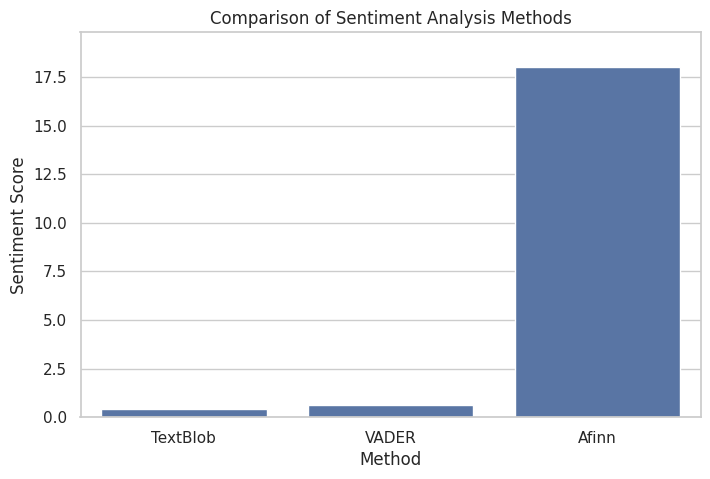

In [ ]:
# 📦 Install if needed (only for Google Colab)
!pip install matplotlib seaborn

# 📚 Import required libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 🧪 Example sentiment scores (replace with your real values)
sentiment_data = {
    'Method': ['TextBlob', 'VADER', 'Afinn'],
    'Score': [0.45, 0.62, 18]  # Replace these with your actual results
}

# 📊 Create a DataFrame
df = pd.DataFrame(sentiment_data)

# 🎨 Plot the bar chart
# 📦 Install if needed (only for Google Colab)
!pip install matplotlib seaborn

# 📚 Import required libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 🧪 Example sentiment scores (replace with your real values)
sentiment_data = {
    'Method': ['TextBlob', 'VADER', 'Afinn'],
    'Score': [0.45, 0.62, 18]  # Replace these with your actual results
}

# 📊 Create a DataFrame
df = pd.DataFrame(sentiment_data)

# 🎨 Plot the bar chart
sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.barplot(x='Method', y='Score', data=df)
plt.title('Comparison of Sentiment Analysis Methods')
plt.ylabel('Sentiment Score')
plt.xlabel('Method')
plt.ylim(0, df['Score'].max() * 1.1)  # Adjust y-axis limit
plt.show()

opisz ten wykres słupkowy


In [ ]:
# 📦 Install if needed (only in Google Colab or first-time use)
!pip install afinn nltk matplotlib seaborn

# 📚 Import libraries
from afinn import Afinn
import nltk
from nltk.tokenize import sent_tokenize
import matplotlib.pyplot as plt
import seaborn as sns

# Download required NLTK data
nltk.download('punkt')

# 📜 Example text (replace with your own)
text = """# 📦 Install if needed (only in Google Colab or first-time use)
!pip install afinn nltk matplotlib seaborn

# 📚 Import libraries
from afinn import Afinn
import nltk
from nltk.tokenize import sent_tokenize
import matplotlib.pyplot as plt
import seaborn as sns

# Download required NLTK data
nltk.download('punkt')

# 📦 Install if needed (only in Google Colab or first-time use)
!pip install afinn nltk matplotlib seaborn

# 📚 Import libraries
from afinn import Afinn
import nltk
from nltk.tokenize import sent_tokenize
import matplotlib.pyplot as plt
import seaborn as sns

# Download required NLTK data
nltk.download('punkt')

# 📦 Install if needed (only in Google Colab or first-time use)
!pip install afinn nltk matplotlib seaborn

# 📚 Import libraries
from afinn import Afinn
import nltk
from nltk.tokenize import sent_tokenize
import matplotlib.pyplot as plt
import seaborn as sns

# Download required NLTK data
nltk.download('punkt')

# 📜 Example text (replace with your own)
text = """
We, the Polish nation, know that freedom is not given forever. We have fought for it with courage and dignity.
We thank America for its support. Solidarity was a movement of hope, born from truth.
We believe in peace and cooperation.
"""

# 🔠 Tokenize text into sentences
sentences = sent_tokenize(text)

# 🧮 Analyze each sentence with Afinn
afinn = Afinn()
scores = [afinn.score(sentence) for sentence in sentences]

# 🧾 Prepare data for visualization
import pandas as pd
df = pd.DataFrame({
    'Sentence': sentences,
    'Afinn Score': scores
})

# 📊 Plot bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x=list(range(1, len(sentences)+1)), y='Afinn Score', palette='viridis')
plt.title("Afinn Sentiment Score per Sentence")
plt.xlabel("Sentence Number")
plt.ylabel("Afinn Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Optional: print detailed results
for i, (s, score) in enumerate(zip(sentences, scores), 1):
    print(f"Sentence {i} (score={score}): {s}")
"""

# 🔠 Tokenize text into sentences
sentences = sent_tokenize(text)

# 🧮 Analyze each sentence with Afinn
afinn = Afinn()
scores = [afinn.score(sentence) for sentence in sentences]

# 🧾 Prepare data for visualization
import pandas as pd
df = pd.DataFrame({
    'Sentence': sentences,
    'Afinn Score': scores
})

# 📊 Plot bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x=list(range(1, len(sentences)+1)), y='Afinn Score', palette='viridis')
plt.title("Afinn Sentiment Score per Sentence")
plt.xlabel("Sentence Number")
plt.ylabel("Afinn Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Optional: print detailed results
for i, (s, score) in enumerate(zip(sentences, scores), 1):
    print(f"Sentence {i} (score={score}): {s}")
"""

# 🔠 Tokenize text into sentences
sentences = sent_tokenize(text)

# 🧮 Analyze each sentence with Afinn
afinn = Afinn()
scores = [afinn.score(sentence) for sentence in sentences]

# 🧾 Prepare data for visualization
import pandas as pd
df = pd.DataFrame({
    'Sentence': sentences,
    'Afinn Score': scores
})

# 📊 Plot bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x=list(range(1, len(sentences)+1)), y='Afinn Score', palette='viridis')
plt.title("Afinn Sentiment Score per Sentence")
plt.xlabel("Sentence Number")
plt.ylabel("Afinn Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Optional: print detailed results
for i, (s, score) in enumerate(zip(sentences, scores), 1):
    print(f"Sentence {i} (score={score}): {s}")
# 📦 Install if needed (only in Google Colab or first-time use)
!pip install afinn nltk matplotlib seaborn

# 📚 Import libraries
from afinn import Afinn
import nltk
from nltk.tokenize import sent_tokenize
import matplotlib.pyplot as plt
import seaborn as sns

# Download required NLTK data
nltk.download('punkt')

# 📜 Example text (replace with your own)
text = """
We, the Polish nation, know that freedom is not given forever. We have fought for it with courage and dignity.
We thank America for its support. Solidarity was a movement of hope, born from truth.
We believe in peace and cooperation.
"""

# 🔠 Tokenize text into sentences
sentences = sent_tokenize(text)

# 🧮 Analyze each sentence with Afinn
afinn = Afinn()
scores = [afinn.score(sentence) for sentence in sentences]

# 🧾 Prepare data for visualization
import pandas as pd
df = pd.DataFrame({
    'Sentence': sentences,
    'Afinn Score': scores
})

# 📊 Plot bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x=list(range(1, len(sentences)+1)), y='Afinn Score', palette='viridis')
plt.title("Afinn Sentiment Score per Sentence")
plt.xlabel("Sentence Number")
plt.ylabel("Afinn Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Optional: print detailed results
for i, (s, score) in enumerate(zip(sentences, scores), 1):
    print(f"Sentence {i} (score={score}): {s}")
sentences = sent_tokenize(text)

# 🧮 Analyze each sentence with Afinn
afinn = Afinn()
scores = [afinn.score(sentence) for sentence in sentences]

# 🧾 Prepare data for visualization
import pandas as pd
df = pd.DataFrame({
    'Sentence': sentences,
    'Afinn Score': scores
})

# 📊 Plot bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x=list(range(1, len(sentences)+1)), y='Afinn Score', palette='viridis')
plt.title("Afinn Sentiment Score per Sentence")
plt.xlabel("Sentence Number")
plt.ylabel("Afinn Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Optional: print detailed results
for i, (s, score) in enumerate(zip(sentences, scores), 1):
    print(f"Sentence {i} (score={score}): {s}")


SyntaxError: unterminated triple-quoted string literal (detected at line 218) (<ipython-input-22-463b9d25fac9>, line 164)

In [ ]:
# 📦 Install if needed (only in Google Colab or first-time use)
!pip install afinn nltk matplotlib seaborn

# 📚 Import libraries
from afinn import Afinn
import nltk
from nltk.tokenize import sent_tokenize
import matplotlib.pyplot as plt
import seaborn as sns

# Download required NLTK data
nltk.download('punkt')

# 📜 Example text (replace with your own)
text = """
www.respublica.pl
We, the people
Lech Wałęsa adresses joint session of the United States Congress
November 15, 1989
”For only the third time in history, a foreigner who is not a head of state addresses a joint meeting of the United States Congress. Lech Wałęsa visited Washington, D.C. just a few days after the fall of the Berlin Wall. He is a symbol of the bloodless and effective fight against communism. In his address, he notes that Poland’s ambitions for freedom – indeed, the whole region’s ambitions – have not yet been fulfilled. The transformation process can only be successful with the active involvement of the West.”

Mr. Speaker,
Mr. President,
members of the Cabinet,
distinguished members of the House and Senate.
“We the People”. With these words I wish to begin my address. I do not need to remind anyone here where these words come from. And I do not need to explain that I – an electrician from Gdansk – am also entitled to invoke them.
I stand before you as the third foreign non-head of state invited to address the joint Houses of Congress of the United States. This Congress, which, for many people in the world, oppressed and stripped of their rights, is a beacon of freedom and a bulwark of human rights. And here, I stand before you, to speak to America in the name of my nation. To speak to citizens of the country and the continent whose threshold is guarded by the famous Statue of Liberty. It is for me an honor so great, a moment so solemn, that I cannot find anything to compare it with.
People in Poland link the name of the United States with freedom and democracy, with generosity and high mindedness, with human friendship and friendly humanity. I realize that not everywhere is America so perceived. I speak of her image in Poland. This image has been strengthened by numerous favorable historical experiences, and it is very well known that Poles repay warm heartedness in kind.
The world remembers the wonderful principle of American democracy: “Government of the people, by the people, for the people.” I do remember these words. I, a shipyard worker from Gdańsk, have devoted my entire life, along with other members of the Solidarity movement, to the service of this idea: “Government of the people, by the people, for the people”. Against privilege and monopoly. Against violations of the law. Against the trampling of human dignity. Against contempt and injustice.
Such, in fact, are the principles and values reminiscent of Abraham Lincoln and the founding fathers of the American Republic, as well as the principles and ideas of the American Declaration of Independence and the American Constitution. These principles are pursued by the great Polish Solidarity movement; a movement that is effective.
I know that Americans are idealistic, but at the same time, practical people, endowed with common sense and capable of logical action. They combine these features with belief in the ultimate victory of right over wrong. But they prefer effective work to making speeches, and I understand them very well. I am not a fan of speeches. I prefer facts and work. I treasure effectiveness.
Ladies and gentleman, the fundamental and most important thing that I would like to tell you about is that the social movement bearing the beautiful name “Solidarity”, born of the Polish nation, is an effective movement. After many long years of struggle, it bore fruit and the results are there for all to see today. It set the direction and developed a way of action that has affected the lives of millions of people speaking different languages. It has swayed monopolies,
And the struggle was conducted without resorting to violence of any kind, a point that cannot be stressed too much. We were being locked up in prisons, deprived of our jobs, beaten, and sometimes killed. And we did not so much as strike a single person. We did not destroy anything. We did not smash a single window pane. But we were stubborn. Very stubborn. Ready to suffer, to make sacrifices. We knew what we wanted, and our power prevailed in the end.
The Solidarity movement received much support and scored victories, because at all times and in all matters, it opted for the better, more human, and more dignified solutions, standing against brutality and hate. It was a consistent and persistent movement, never giving up. And that is why after all these hard years, marked by so many tragic moments, Solidarity is today succeeding and showing the way to millions of people in Poland and other countries.
Ladies and gentleman, it was ten years ago, in August 1980, that the famous strike began in the Gdansk shipyards that led to the emergence of the first independent trade union in communist countries, and soon became a vast social movement, supported by the Polish nation. I was ten years younger then, unknown to anybody but my friends in the shipyard, and somewhat slimmer. And I must frankly say that it was important. I was an unemployed man at that time, fired from my job for earlier attempts to organize workers in the fight for their rights. I jumped over the shipyard wall and rejoined my former colleagues, who promptly appointed me leader of the strike. This is how it all began.
When I recall the road we travelled, I often think of that jump over the fence. Now others jump fences and tear down walls. They do it because freedom is a human right. But there is also another reflection that comes to mind when I think of the road behind us. In those days, at the beginning, many warnings, admonitions, and even condemnations reached us from many parts of the world.
“What are those Poles up to?” we heard. “They are mad!” “They are jeopardizing world peace and European stabilit!” “They ought to stay quiet and not get on anybody’s nerves”. From those voices we gathered that other nations have the right to live in comfort and prosperity, they have the right to democracy and freedom, and it is only Poles who should give up these rights so as not to disturb the peace of others.
In the days before the Second World War there were many people who asked: “Why should we die for Gdańsk, isn’t it better to stay home?” But war soon paid them a visit. And they had to start dying, for Paris, for London, for Hawaii. This time, too, there were many who complained: “There is that Gdansk again, disturbing our peace!”
But the recent developments in Gdańsk carried a different message. This is not the beginning, but the true end of that war. That was the beginning of a new, better, democratic, and safe era in the history of our world. It is no longer a question of “dying for Gdańsk”, but of “living for it”.
Looking at what is happening around us today, we may affirm that the path of struggle followed by Poland in quest of human rights, a struggle without violence and characterized by typical Polish stubbornness and firmness in the quest for pluralism and democracy, shows many people today, and even nations, how to avoid the greatest dangers of conflict.
If there is something threatening European stability today it is certainly not Poland. Poland is driving towards its own profound transformation; transformation achieved through peaceful means, through evolution, negotiated with all the parties concerned, which makes it possible to avoid the worst. And perhaps is held up as a model for many other regions. For, as we know, changes elsewhere are not so peaceful. Peacefully and prudently, with their eyes open to danger but not giving up what is right and necessary, the Poles gradually paved a way for historic transformations.
We are joined along this way, to various extents, by others: Hungarians and Russians, Ukrainians and the people from the Baltic states, Armenians and Georgians, and in recent days East Germans. We wish them luck and rejoice each success they achieve. We are certain that others will also take road we have followed, as there is no other choice!
So now I ask, is there is any sensible man understanding the world around him who could justifiably say today that it would be better for the Poles to keep quiet, because what they are doing is jeopardizing world peace? Could we even dare say that Poles are doing more to preserve and consolidate peace than many of their frightened advisors? Could we not say that stability and peace is under greater threat from countries which have not yet brought themselves to carry out far-reaching and comprehensive reforms, which do their utmost to preserve the old and disgraced ways of government, contrary to the wishes of their societies?
Things are different in Poland. And I must say that our task is viewed with understanding by our Eastern neighbors and their leader Mikhail Gorbachev. This understanding lays the foundation for new relations between Poland and the Soviet Union, relations which are much better than before. These improved mutual relations will also contribute to stabilization and peace in Europe, removing useless tensions.
The Poles have a long and difficult history, and no one wants more than we do peaceful coexistence and friendship with all nations and countries, and particularly with the Soviet Union. We believe that it is only now that the right and favorable conditions for such coexistence and friendship are emerging. Poland is making an important contribution to a better future for Europe, to European reconciliation. And also to the vast and important Polish-German reconciliation. To overcoming all the divisions and the strengthening of human rights on our continent. But it does not come easily for Poland.
In the Second World War, Poland was the first country to fall victim to aggression. Her losses in terms of human life and national property were the heaviest. Her fight was the longest; she was always a dedicated member of the victorious alliance and her soldiers fought in all the world theatres. In 1945 Poland was, theoretically speaking, one of the victors. Theory, however, had little in common with practice.
In practice, as her allies looked on in passive consent, an alien system of government was imposed in Poland, without a president in the Polish tradition, unaccepted by the nation, together with an alien economy, an alien law, and an alien philosophy of social relations. The legal Polish government, recognized by the nation, and leading the struggle of all Poles throughout the war was condemned, and those who remained faithful to it were subjected to the most ruthless persecution. Many were murdered. Thousands vanished somewhere into Russia’s East and North. Civilian repression without soldiers of the underground army that fought the Nazis. And it is only now that we are discovering their bones in unmarked graves scattered among the forests.
This was followed by persecutions of all those who dared to think independently. All the solemn pledges about free elections in Poland that were made in Yalta were broken. It was the second great national catastrophe following the catastrophe of 1939. When other nations were joyously celebrating victory, Poland was again sinking into mourning.
The awareness of this tragedy was doubly bitter, as the Poles realized that they had been abandoned by their allies. The memory of this is still strong in the minds of many. Nevertheless, the Poles took to rebuilding their devastated country, and in the first years following the war they were highly successful. But soon a new economic system was introduced, in which individual entrepreneurship ceased to exist, and the entire economy ended up in the hands of the state, run by people who were not elected by the nation.
Stalin forbade Poland to use aid provided by the Marshall Plan; aid that was used by everyone in Western Europe, including countries which lost the war. It is worth recalling now that great American plan which helped Western Europe to protect its freedom and peaceful order. And now is the moment when Eastern Europe awaits an investment of this kind, an investment in freedom, democracy, and peace. An investment adequate to the greatness of the American nation.
The Poles have travelled a long way. It would be worthwhile for all those commenting on Poland, often criticizing Poland, to bear in mind that, whatever Poland has achieved, she achieved through her own effort, through her own stubbornness, her own relentlessness. Everything was achieved thanks to the unflinching faith of our nation in human dignity, and in what is described as the values of Western culture and civilization. Our nation well knows the price of all this.
Ladies and gentleman, for the past fifty years, the Polish nation has been engaged in a difficult and exhausting battle. First to preserve its very biological existence. Later to save its national identity. In both instances, Polish determination was there. Today, Poland is rejoining the family of democratic and pluralistic countries, returning to the tradition of religious and European values. For the first time in half a century, Poland has a non-communist and independent government supported by the nation.
But in our past there looms a serious obstacle. A great danger. Our long subjection to a political system incompatible with national traditions, to an economic system incompatible with rationality and common sense, coupled with a stifling of independent thought and disregard for national interest has led the Polish economy to ruin, to the verge of utter catastrophe. The first government in fifty years elected by the people and serving the people has inherited from the previous rulers of the country the burden of an economy organized in a manner which prevents it from satisfying even the basic needs of its people.
The economy we inherited after almost five decades of communist rule is in need of overhaul. This will require patience and great sacrifice. This will require time and means. The present condition of the Polish economy is not due to change, as it is not specifically a Polish predicament. All the countries of the Eastern Bloc are bankrupt today. The communist economy has failed in every part of the world. One result of this is the exile of citizens of those countries, by land and by sea, by boat and by plane, swimming and walking across borders. This is a mass scale phenomenon, well known in Europe, Asia, and Central America.
But Poland has taken its new road and will never be turned back. The sense of our work and struggle in Poland lies in our creating situations and prospects that would hold Poles back from seeking a place for themselves abroad; that would encourage them to seek meaning in their work and hope for a better future in their own country, their own home. One sometimes hears that people in Poland do not care to work well. But even those who say this know that Poles work well and effectively, if only they see the sense and usefulness of their work. The working people know their arithmetic too. They are working much harder and in worse conditions than their opposite numbers abroad, and on top of that, they are paid much lower wages. The economic system around them is absurd. To make matters worse, every several or dozen years, the country suffered a new crisis, a new crunch, and time and time again it has turned out that past efforts went to waste. Show me the people who would have worked well stuck for decades under such a system. Wouldn’t they too have succumbed to pessimism?
The system has to be changed and the Poles have taken it upon themselves to change it. I know that America has her own problems and difficulties, some of them very serious. We are not asking for charity, we are not expecting philanthropy. But we would like to see our country treated as a partner and a friend. We would like cooperation under decent and favorable conditions. We would like Americans to come to us with proposals of cooperation, bringing benefits to both sides. We believe that assistance, extended to democracy and freedom in Poland and all of Eastern Europe, is the best investment in the future and in peace, better than tanks, warships, and warplanes; an investment leading to greater security.
Poland has already done much to patch up the divisions existing in Europe, to create better and more optimistic prospects. Poland’s efforts are viewed with sympathetic interest by the West; and for this thanks are in order. We believe that the West’s contribution to the process will now grow. We have heard many beautiful words of encouragement. These are appreciated, but being a worker and a man of concrete work I must tell you that the supply of words on the world market is plentiful, but the demand is falling. Let deeds follow words now.
The decision by the Congress of the United States about granting economic aid to my country opens a new road. For this wonderful decision, I thank you warmly. And I promise you that “this” aid will not be wasted and will never be forgotten.
Ladies and gentleman, from this podium I am expressing words of gratitude to the American people. It is they who supported us in the difficult days of Martial Law and persecution. It is they who sent us aid. They protested against violence. Today, when I am able to freely address the whole world from this elevated spot, I would like to thank them with special words. It is thanks to them that the world “Solidarity” soared across borders and has reached every corner of the world, and thanks to them the people of Solidarity were never alone.
In this chain of people linked to Solidarity there were many, many Americans. I wish to mention here with warm gratitude our friends from the United States Congress, the AFL-CIO trade unions, from the institutions and foundations supporting freedom and democracy, and all those who lent us support in our most difficult moments. They live in all states, in large and small communities of your vast country.
I thank all those who through the airwaves or printed word “spread the truth”. I also wish to say thank you and to greet all Polish-Americans who maintained warm contact with their old fatherland. Their support was always priceless for us.
I wholeheartedly thank the President of the United States and his administration for its involvement in my country’s affairs. I will never forget the then Vice-President, George Bush, speaking over the tomb of the reverent Jerzy Popiełuszko, the martyr of Poland. And I will never forget President George Bush speaking in Gdansk, in front of the monument of the falling shipyard workers. It is from there that the President of the United States was sending a message of freedom to Poland, to Europe, to the world.
Pope John Paul II once said: “Freedom is not just something to have and to use, it is something to be fought for; one must use freedom to build one’s personal life as well as the life of the nation.” I think this weighted thought can equally well be applied to Poland and America. I wish all of you to know and to keep in mind that the ideals which underline this glorious American Republic, and which are still alive here, are also alive and well in faraway Poland. And although for many long years efforts were made to cut Poland off from these ideals, she held her ground and is now reaching for the freedom to which she is justly entitled.
Together with Poland, other nations of Eastern Europe are following this path. The wall that separated people from freedom has collapsed.



"""

# 🔠 Tokenize text into sentences
sentences = sent_tokenize(text)

# 🧮 Analyze each sentence with Afinn
afinn = Afinn()
scores = [afinn.score(sentence) for sentence in sentences]

# 🧾 Prepare data for visualization
import pandas as pd
df = pd.DataFrame({
    'Sentence': sentences,
    'Afinn Score': scores
})

# 📊 Plot bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x=list(range(1, len(sentences)+1)), y='Afinn Score', palette='viridis')
plt.title("Afinn Sentiment Score per Sentence")
plt.xlabel("Sentence Number")
plt.ylabel("Afinn Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Optional: print detailed results
for i, (s, score) in enumerate(zip(sentences, scores), 1):
    print(f"Sentence {i} (score={score}): {s}")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


In [ ]:
# 📦 Install if needed (only in Google Colab or first-time use)
!pip install afinn nltk matplotlib seaborn
# 📦 Install if needed (only in Google Colab or first-time use)
!pip install afinn nltk matplotlib seaborn

# 📚 Import libraries
from afinn import Afinn
import nltk
from nltk.tokenize import sent_tokenize
import matplotlib.pyplot as plt
import seaborn as sns

# Download required NLTK data, including 'punkt_tab'
try:
    nltk.download('punkt', quiet=True)
    print("NLTK 'punkt' downloaded.")
except Exception as e:
    print(f"Error downloading NLTK 'punkt': {e}")

try:
    # Explicitly download punkt_tab for the English language
    # punkt_tab is part of the punkt package, so the previous download should cover it
    # However, keeping this for clarity if needed for specific language models
    nltk.download('punkt', quiet=True) # Re-downloading punkt which includes punkt_tab
    print("NLTK 'punkt_tab' (included in punkt) downloaded.")
except Exception as e:
     print(f"Error downloading NLTK 'punkt_tab': {e}")

# 📜 Example text (replace with your own)
# The text variable is already defined from previous cells, so we don't redefine it here.
# However, the traceback shows that the text variable *was* redefined within this cell,
# which would cause the original text to be lost.
# We will remove the redefinition of 'text' to use the text read from the Word document.

# REMOVE the following block if you want to use the text from King.docx:
# text = """
# www.respublica.pl
# We, the people
# Lech Wałęsa adresses joint session of the United States Congress
# November 15, 1989
# ... (rest of the example text)
# """
# If you *intended* to analyze this specific example text, keep the block.
# Based on the user's overall notebook flow, it seems they want to analyze King.docx.
# Therefore, we assume the user wants to use the 'text' variable populated from the docx file.

# If the 'text' variable from the docx was lost due to rerunning cells,
# you might need to re-run the cell that reads the docx file first.

# 🔠 Tokenize text into sentences
# Use the 'language' parameter explicitly set to 'english' for clarity and consistency
# with the downloaded 'punkt_tab' resource.
try:
    sentences = sent_tokenize(text, language='english')
    print(f"\nTokenized text into {len(sentences)} sentences.")
except LookupError:
    print("\nCould not find 'punkt' for English even after download attempt.")
    print("Please try running 'nltk.download('punkt')' manually in a new cell.")
    sentences = [] # Set sentences to empty list to prevent further errors
except NameError:
    print("\n'text' variable not found. Please make sure you have loaded the text data.")
    sentences = [] # Set sentences to empty list

# 🧮 Analyze each sentence with Afinn
# Check if sentences were successfully tokenized before proceeding
if sentences:
    afinn = Afinn()
    scores = [afinn.score(sentence) for sentence in sentences]

    # 🧾 Prepare data for visualization
    import pandas as pd
    df = pd.DataFrame({
        'Sentence': sentences,
        'Afinn Score': scores
    })

    # 📊 Plot bar chart
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df, x=list(range(1, len(sentences)+1)), y='Afinn Score', palette='viridis')
    plt.title("Afinn Sentiment Score per Sentence")
    plt.xlabel("Sentence Number")
    plt.ylabel("Afinn Score")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Optional: print detailed results
    for i, (s, score) in enumerate(zip(sentences, scores), 1):
        print(f"Sentence {i} (score={score}): {s}")
else:
    print("Skipping Afinn analysis and plotting due to tokenization failure or missing text.")
import matplotlib.pyplot as plt
import seaborn as sns

# Download required NLTK data, including 'punkt_tab'
try:
    nltk.download('punkt', quiet=True)
    print("NLTK 'punkt' downloaded.")
except Exception as e:
    print(f"Error downloading NLTK 'punkt': {e}")

try:
    # Explicitly download punkt_tab for the English language
    nltk.download('punkt_tab', quiet=True)
    print("NLTK 'punkt_tab' downloaded.")
except Exception as e:
     print(f"Error downloading NLTK 'punkt_tab': {e}")

# 📜 Example text (replace with your own)
# The text variable is already defined from previous cells, so we don't redefine it here.
# However, the traceback shows that the text variable *was* redefined within this cell,
# which would cause the original text to be lost.
# We will remove the redefinition of 'text' to use the text read from the Word document.

# REMOVE the following block if you want to use the text from King.docx:
# text = """
# www.respublica.pl
# We, the people
# Lech Wałęsa adresses joint session of the United States Congress
# November 15, 1989
# ... (rest of the example text)
# """
# If you *intended* to analyze this specific example text, keep the block.
# Based on the user's overall notebook flow, it seems they want to analyze King.docx.
# Therefore, we assume the user wants to use the 'text' variable populated from the docx file.

# If the 'text' variable from the docx was lost due to rerunning cells,
# you might need to re-run the cell that reads the docx file first.

# 🔠 Tokenize text into sentences
# Use the 'language' parameter explicitly set to 'english' for clarity and consistency
# with the downloaded 'punkt_tab' resource.
try:
    sentences = sent_tokenize(text, language='english')
    print(f"\nTokenized text into {len(sentences)} sentences.")
except LookupError:
    print("\nCould not find 'punkt_tab' for English even after download attempt.")
    print("Please try running 'nltk.download('punkt_tab')' manually in a new cell.")
    sentences = [] # Set sentences to empty list to prevent further errors

# 🧮 Analyze each sentence with Afinn
# Check if sentences were successfully tokenized before proceeding
if sentences:
    afinn = Afinn()
    scores = [afinn.score(sentence) for sentence in sentences]

    # 🧾 Prepare data for visualization
    import pandas as pd
    df = pd.DataFrame({
        'Sentence': sentences,
        'Afinn Score': scores
    })

    # 📊 Plot bar chart
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df, x=list(range(1, len(sentences)+1)), y='Afinn Score', palette='viridis')
    plt.title("Afinn Sentiment Score per Sentence")
    plt.xlabel("Sentence Number")
    plt.ylabel("Afinn Score")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Optional: print detailed results
    for i, (s, score) in enumerate(zip(sentences, scores), 1):
        print(f"Sentence {i} (score={score}): {s}")
else:
    print("Skipping Afinn analysis and plotting due to tokenization failure.")


SyntaxError: invalid non-printable character U+00A0 (<ipython-input-24-9ffc56a5c8b3>, line 5)

In [ ]:
# 📦 Install required packages
!pip install afinn python-docx matplotlib seaborn

# 📚 Import libraries
from afinn import Afinn
from docx import Document
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 📄 Load text from Word document (.docx)
def load_paragraphs_from_docx(file_path):
    doc = Document(file_path)
    return [para.text.strip() for para in doc.paragraphs if para.text.strip()]

# 📊 Analyze sentiment per paragraph
def analyze_afinn_paragraphs(paragraphs):
    afinn = Afinn()
    return [afinn.score(p) for p in paragraphs]

# 📝 Replace these filenames with your actual document names
file1 = "Przemówienie Wałęsy w Kongresie.docx"
file2 = "Przemówienie JPII w Warszawie 1979.docx"

# 📥 Upload files manually if using Google Colab
from google.colab import files
uploaded = files.upload()

# 📜 Load paragraphs
paras1 = load_paragraphs_from_docx(file1)
paras2 = load_paragraphs_from_docx(file2)

# 🧮 Analyze sentiment scores
scores1 = analyze_afinn_paragraphs(paras1)
scores2 = analyze_afinn_paragraphs(paras2)

# 🧾 Create DataFrame for both
df1 = pd.DataFrame({
    "Paragraph": list(range(1, len(scores1)+1)),
    "Afinn Score": scores1,
    "Document": "Wałęsa"
})
df2 = pd.DataFrame({
    "Paragraph": list(range(1, len(scores2)+1)),
    "Afinn Score": scores2,
    "Document": "JPII"
})

# 📈 Combine both datasets
df_all = pd.concat([df1, df2])

# 📊 Plot comparison
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_all, x="Paragraph", y="Afinn Score", hue="Document", marker="o")
plt.title("Afinn Sentiment per Paragraph: Wałęsa vs. John Paul II")
plt.xlabel("Paragraph Number")
plt.ylabel("Afinn Sentiment Score")
plt.legend(title="Document")
plt.grid(True)
plt.tight_layout()
plt.show()


Saving Przemówienie JPII w Warszawie 1979.docx to Przemówienie JPII w Warszawie 1979 (1).docx
Saving Przemówienie Wałęsy w Kongresie.docx to Przemówienie Wałęsy w Kongresie (1).docx


PackageNotFoundError: Package not found at 'Przemówienie Wałęsy w Kongresie.docx'

In [ ]:

# Install required libraries
!pip install vaderSentiment pandas python-docx nltk deep-translator

# Import libraries
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import pandas as pd
from pathlib import Path
import nltk
from google.colab import files
from deep_translator import GoogleTranslator
import docx
import io
import textwrap

# Download NLTK sentence tokenizer data
try:
    nltk.download('punkt', quiet=True)
except Exception as e:
    print(f"Error downloading NLTK data: {e}")

def read_docx(file_content, filename):
    """Read text from a .docx file content."""
    try:
        doc = docx.Document(io.BytesIO(file_content))
        text = "\n".join([para.text for para in doc.paragraphs if para.text.strip()])
        return text
    except Exception as e:
        print(f"Error reading .docx file '{filename}': {e}")
        return ""

def read_txt(file_content, filename):
    """Read text from a .txt file content."""
    try:
        text = file_content.decode('utf-8')
        return text
    except UnicodeDecodeError:
        print(f"Error: File '{filename}' is not UTF-8 encoded. Try saving with UTF-8.")
        return ""
    except Exception as e:
        print(f"Error reading .txt file '{filename}': {e}")
        return ""

def translate_text(text, source_lang='pl', target_lang='en'):
    """Translate text from source language to target language."""
    try:
        translator = GoogleTranslator(source=source_lang, target=target_lang)
        return translator.translate(text)
    except Exception as e:
        print(f"Error translating text: {e}")
        return text  # Return original text if translation fails

def split_into_sentences(text):
    """Split text into sentences using NLTK."""
    try:
        sentences = nltk.sent_tokenize(text)
        return [s.strip() for s in sentences if s.strip()]
    except Exception as e:
        print(f"Error splitting text into sentences: {e}")
        return [text]  # Fallback to whole text

def analyze_sentiment(texts):
    """Analyze sentiment of a list of texts using VADER."""
    try:
        analyzer = SentimentIntensityAnalyzer()
    except Exception as e:
        print(f"Error initializing VADER: {e}")
        return []

    results = []
    for text in texts:
        try:
            scores = analyzer.polarity_scores(text)
            label = 'Positive' if scores['compound'] >= 0.05 else 'Negative' if scores['compound'] <= -0.05 else 'Neutral'
            results.append({
                'Text': text,
                'Positive': scores['pos'],
                'Neutral': scores['neu'],
                'Negative': scores['neg'],
                'Compound': scores['compound'],
                'Sentiment': label
            })
        except Exception as e:
            print(f"Error analyzing text '{text[:50]}...': {e}")
            results.append({
                'Text': text,
                'Positive': 0.0,
                'Neutral': 0.0,
                'Negative': 0.0,
                'Compound': 0.0,
                'Sentiment': 'Error'
            })

    return results

def save_results_to_csv(results, output_file='sentiment_analysis_results.csv'):
    """Save sentiment analysis results to a CSV file."""
    if not results:
        print("No results to save.")
        return

    try:
        df = pd.DataFrame(results)
        df.to_csv(output_file, index=False, encoding='utf-8')
        print(f"Results saved to '{output_file}'.")
        files.download(output_file)  # Download the file in Colab
    except Exception as e:
        print(f"Error saving to CSV: {e}")

def main():
    # Input method selection
    print("Choose input method:")
    print("1. Upload a file (.txt or .docx)")
    print("2. Paste text directly")
    choice = input("Enter 1 or 2: ")

    text = ""
    is_polish = input("Is the text in Polish? (y/n): ").lower() == 'y'

    if choice == '1':
        # File upload
        print("Upload your .txt or .docx file:")
        uploaded = files.upload()
        if not uploaded:
            print("No file uploaded. Exiting.")
            return

        # Process the uploaded file
        for filename, content in uploaded.items():
            if filename.endswith('.docx'):
                text = read_docx(content, filename)
            elif filename.endswith('.txt'):
                text = read_txt(content, filename)
            else:
                print(f"Unsupported file format: '{filename}'. Use .txt or .docx.")
                return
            break  # Process only the first file

    elif choice == '2':
        # Direct text input
        print("Paste your text below (press Enter twice to finish):")
        lines = []
        while True:
            line = input()
            if line == "":
                break
            lines.append(line)
        text = "\n".join(lines)

    else:
        print("Invalid choice. Exiting.")
        return

    if not text:
        print("No text provided. Exiting.")
        return

    # Translate if Polish
    if is_polish:
        print("Translating Polish text to English...")
        text = translate_text(text, source_lang='pl', target_lang='en')
        if not text:
            print("Translation failed. Exiting.")
            return

    # Split into sentences
    sentences = split_into_sentences(text)
    print(f"Analyzing {len(sentences)} sentences...")

    # Analyze sentiment
    results = analyze_sentiment(sentences)

    # Print summary
    print("\nSentiment Analysis Summary:")
    if results:
        sentiment_counts = pd.DataFrame(results).groupby('Sentiment').size()
        for sentiment, count in sentiment_counts.items():
            print(f"{sentiment}: {count} sentences")

    # Print sample results (first 5 sentences, truncated for readability)
    print("\nSample Results (first 5 sentences):")
    for result in results[:5]:
        wrapped_text = textwrap.shorten(result['Text'], width=100, placeholder="...")
        print(f"\nText: {wrapped_text}")
        print(f"Positive: {result['Positive']:.3f}")
        print(f"Neutral: {result['Neutral']:.3f}")
        print(f"Negative: {result['Negative']:.3f}")
        print(f"Compound: {result['Compound']:.3f} ({result['Sentiment']})")

    # Save and download results
    save_results_to_csv(results)

if __name__ == "__main__":
    main()




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.3/244.3 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.1 MB/s eta 0:00:00
Choose input method:
1. Upload a file (.txt or .docx)
2. Paste text directly
Enter 1 or 2: 2
Is the text in Polish? (y/n): n
Paste your text below (press Enter twice to finish):
Ala have a cat and she is very sad
R. MARTIN LUTHER KING, JR. – AUGUST 28, 1963 I am happy to join with you today in what will go down in history as the greatest demonstration for freedom in the history of our nation. Five score years ago, a great American, in whose symbolic shadow we stand today, signed the Emancipation Proclamation. This momentous decree came as a great beacon of hope to millions of slaves, who had been seared in the flames of whithering injustice. It came as a joyous daybreak to end the long night of their captivity. But one hundred years later, the colored

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:



# Install required libraries
!pip install vaderSentiment pandas python-docx nltk deep-translator

# Import libraries
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import pandas as pd
from pathlib import Path
import nltk
from google.colab import files
from deep_translator import GoogleTranslator
import docx
import io
import textwrap

# Download NLTK sentence tokenizer data
try:
    nltk.download('punkt', quiet=True)
except Exception as e:
    print(f"Error downloading NLTK data: {e}")

def read_docx(file_content, filename):
    """Read text from a .docx file content."""
    try:
        doc = docx.Document(io.BytesIO(file_content))
        text = "\n".join([para.text for para in doc.paragraphs if para.text.strip()])
        return text
    except Exception as e:
        print(f"Error reading .docx file '{filename}': {e}")
        return ""

def read_txt(file_content, filename):
    """Read text from a .txt file content."""
    try:
        text = file_content.decode('utf-8')
        return text
    except UnicodeDecodeError:
        print(f"Error: File '{filename}' is not UTF-8 encoded. Try saving with UTF-8.")
        return ""
    except Exception as e:
        print(f"Error reading .txt file '{filename}': {e}")
        return ""

def translate_text(text, source_lang='pl', target_lang='en'):
    """Translate text from source language to target language."""
    try:
        translator = GoogleTranslator(source=source_lang, target=target_lang)
        return translator.translate(text)
    except Exception as e:
        print(f"Error translating text: {e}")
        return text  # Return original text if translation fails

def split_into_sentences(text):
    """Split text into sentences using NLTK."""
    try:
        sentences = nltk.sent_tokenize(text)
        return [s.strip() for s in sentences if s.strip()]
    except Exception as e:
        print(f"Error splitting text into sentences: {e}")
        return [text]  # Fallback to whole text

def analyze_sentiment(texts):
    """Analyze sentiment of a list of texts using VADER."""
    try:
        analyzer = SentimentIntensityAnalyzer()
    except Exception as e:
        print(f"Error initializing VADER: {e}")
        return []

    results = []
    for text in texts:
        try:
            scores = analyzer.polarity_scores(text)
            label = 'Positive' if scores['compound'] >= 0.05 else 'Negative' if scores['compound'] <= -0.05 else 'Neutral'
            results.append({
                'Text': text,
                'Positive': scores['pos'],
                'Neutral': scores['neu'],
                'Negative': scores['neg'],
                'Compound': scores['compound'],
                'Sentiment': label
            })
        except Exception as e:
            print(f"Error analyzing text '{text[:50]}...': {e}")
            results.append({
                'Text': text,
                'Positive': 0.0,
                'Neutral': 0.0,
                'Negative': 0.0,
                'Compound': 0.0,
                'Sentiment': 'Error'
            })

    return results

def save_results_to_csv(results, output_file='sentiment_analysis_results.csv'):
    """Save sentiment analysis results to a CSV file."""
    if not results:
        print("No results to save.")
        return

    try:
        df = pd.DataFrame(results)
        df.to_csv(output_file, index=False, encoding='utf-8')
        print(f"Results saved to '{output_file}'.")
        files.download(output_file)  # Download the file in Colab
    except Exception as e:
        print(f"Error saving to CSV: {e}")

def main():
    # Input method selection
    print("Choose input method:")
    print("1. Upload a file (.txt or .docx)")
    print("2. Paste text directly")
    choice = input("Enter 1 or 2: ")

    text = ""
    is_polish = input("Is the text in Polish? (y/n): ").lower() == 'y'

    if choice == '1':
        # File upload
        print("Upload your .txt or .docx file:")
        uploaded = files.upload()
        if not uploaded:
            print("No file uploaded. Exiting.")
            return

        # Process the uploaded file
        for filename, content in uploaded.items():
            if filename.endswith('.docx'):
                text = read_docx(content, filename)
            elif filename.endswith('.txt'):
                text = read_txt(content, filename)
            else:
                print(f"Unsupported file format: '{filename}'. Use .txt or .docx.")
                return
            break  # Process only the first file

    elif choice == '2':
        # Direct text input
        print("Paste your text below (press Enter twice to finish):")
        lines = []
        while True:
            line = input()
            if line == "":
                break
            lines.append(line)
        text = "\n".join(lines)

    else:
        print("Invalid choice. Exiting.")
        return

    if not text:
        print("No text provided. Exiting.")
        return

    # Translate if Polish
    if is_polish:
        print("Translating Polish text to English...")
        text = translate_text(text, source_lang='pl', target_lang='en')
        if not text:
            print("Translation failed. Exiting.")
            return

    # Split into sentences
    sentences = split_into_sentences(text)
    print(f"Analyzing {len(sentences)} sentences...")

    # Analyze sentiment
    results = analyze_sentiment(sentences)

    # Print summary
    print("\nSentiment Analysis Summary:")
    if results:
        sentiment_counts = pd.DataFrame(results).groupby('Sentiment').size()
        for sentiment, count in sentiment_counts.items():
            print(f"{sentiment}: {count} sentences")

    # Print sample results (first 5 sentences, truncated for readability)
    print("\nSample Results (first 5 sentences):")
    for result in results[:5]:
        wrapped_text = textwrap.shorten(result['Text'], width=100, placeholder="...")
        print(f"\nText: {wrapped_text}")
        print(f"Positive: {result['Positive']:.3f}")
        print(f"Neutral: {result['Neutral']:.3f}")
        print(f"Negative: {result['Negative']:.3f}")
        print(f"Compound: {result['Compound']:.3f} ({result['Sentiment']})")

    # Save and download results
    save_results_to_csv(results)

if __name__ == "__main__":
    main()


Choose input method:
1. Upload a file (.txt or .docx)
2. Paste text directly
Enter 1 or 2: 2
Is the text in Polish? (y/n): n
Paste your text below (press Enter twice to finish):
 DR. MARTIN LUTHER KING, JR. – AUGUST 28, 1963 I am happy to join with you today in what will go down in history as the greatest demonstration for freedom in the history of our nation. Five score years ago, a great American, in whose symbolic shadow we stand today, signed the Emancipation Proclamation. This momentous decree came as a great beacon of hope to millions of slaves, who had been seared in the flames of whithering injustice. It came as a joyous daybreak to end the long night of their captivity. But one hundred years later, the colored America is still not free. One hundred years later, the life of the colored American is still sadly crippled by the manacle of segregation and the chains of discrimination. One hundred years later, the colored American lives on a lonely island of poverty in the midst of 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

# Install required libraries
!pip install vaderSentiment pandas python-docx nltk deep-translator

# Import libraries
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import pandas as pd
from pathlib import Path
import nltk
nltk.download('punkt_tab')
from google.colab import files
from deep_translator import GoogleTranslator
import docx
import io
import textwrap

# Download NLTK sentence tokenizer data
try:
    nltk.download('punkt', quiet=True)
except Exception as e:
    print(f"Error downloading NLTK data: {e}")

def read_docx(file_content, filename):
    """Read text from a .docx file content."""
    try:
        doc = docx.Document(io.BytesIO(file_content))
        text = "\n".join([para.text for para in doc.paragraphs if para.text.strip()])
        return text
    except Exception as e:
        print(f"Error reading .docx file '{filename}': {e}")
        return ""

def read_txt(file_content, filename):
    """Read text from a .txt file content."""
    try:
        text = file_content.decode('utf-8')
        return text
    except UnicodeDecodeError:
        print(f"Error: File '{filename}' is not UTF-8 encoded. Try saving with UTF-8.")
        return ""
    except Exception as e:
        print(f"Error reading .txt file '{filename}': {e}")
        return ""

def translate_text(text, source_lang='pl', target_lang='en'):
    """Translate text from source language to target language."""
    try:
        translator = GoogleTranslator(source=source_lang, target=target_lang)
        return translator.translate(text)
    except Exception as e:
        print(f"Error translating text: {e}")
        return text  # Return original text if translation fails

def split_into_sentences(text):
    """Split text into sentences using NLTK."""
    try:
        sentences = nltk.sent_tokenize(text)
        return [s.strip() for s in sentences if s.strip()]
    except Exception as e:
        print(f"Error splitting text into sentences: {e}")
        return [text]  # Fallback to whole text

def analyze_sentiment(texts):
    """Analyze sentiment of a list of texts using VADER."""
    try:
        analyzer = SentimentIntensityAnalyzer()
    except Exception as e:
        print(f"Error initializing VADER: {e}")
        return []

    results = []
    for text in texts:
        try:
            scores = analyzer.polarity_scores(text)
            label = 'Positive' if scores['compound'] >= 0.05 else 'Negative' if scores['compound'] <= -0.05 else 'Neutral'
            results.append({
                'Text': text,
                'Positive': scores['pos'],
                'Neutral': scores['neu'],
                'Negative': scores['neg'],
                'Compound': scores['compound'],
                'Sentiment': label
            })
        except Exception as e:
            print(f"Error analyzing text '{text[:50]}...': {e}")
            results.append({
                'Text': text,
                'Positive': 0.0,
                'Neutral': 0.0,
                'Negative': 0.0,
                'Compound': 0.0,
                'Sentiment': 'Error'
            })

    return results

def save_results_to_csv(results, output_file='sentiment_analysis_results.csv'):
    """Save sentiment analysis results to a CSV file."""
    if not results:
        print("No results to save.")
        return

    try:
        df = pd.DataFrame(results)
        df.to_csv(output_file, index=False, encoding='utf-8')
        print(f"Results saved to '{output_file}'.")
        files.download(output_file)  # Download the file in Colab
    except Exception as e:
        print(f"Error saving to CSV: {e}")

def main():
    # Input method selection
    print("Choose input method:")
    print("1. Upload a file (.txt or .docx)")
    print("2. Paste text directly")
    choice = input("Enter 1 or 2: ")

    text = ""
    is_polish = input("Is the text in Polish? (y/n): ").lower() == 'y'

    if choice == '1':
        # File upload
        print("Upload your .txt or .docx file:")
        uploaded = files.upload()
        if not uploaded:
            print("No file uploaded. Exiting.")
            return

        # Process the uploaded file
        for filename, content in uploaded.items():
            if filename.endswith('.docx'):
                text = read_docx(content, filename)
            elif filename.endswith('.txt'):
                text = read_txt(content, filename)
            else:
                print(f"Unsupported file format: '{filename}'. Use .txt or .docx.")
                return
            break  # Process only the first file

    elif choice == '2':
        # Direct text input
        print("Paste your text below (press Enter twice to finish):")
        lines = []
        while True:
            line = input()
            if line == "":
                break
            lines.append(line)
        text = "\n".join(lines)

    else:
        print("Invalid choice. Exiting.")
        return

    if not text:
        print("No text provided. Exiting.")
        return

    # Translate if Polish
    if is_polish:
        print("Translating Polish text to English...")
        text = translate_text(text, source_lang='pl', target_lang='en')
        if not text:
            print("Translation failed. Exiting.")
            return

    # Split into sentences
    sentences = split_into_sentences(text)
    print(f"Analyzing {len(sentences)} sentences...")

    # Analyze sentiment
    results = analyze_sentiment(sentences)

    # Print summary
    print("\nSentiment Analysis Summary:")
    if results:
        sentiment_counts = pd.DataFrame(results).groupby('Sentiment').size()
        for sentiment, count in sentiment_counts.items():
            print(f"{sentiment}: {count} sentences")

    # Print sample results (first 5 sentences, truncated for readability)
    print("\nSample Results (first 5 sentences):")
    for result in results[:5]:
        wrapped_text = textwrap.shorten(result['Text'], width=100, placeholder="...")
        print(f"\nText: {wrapped_text}")
        print(f"Positive: {result['Positive']:.3f}")
        print(f"Neutral: {result['Neutral']:.3f}")
        print(f"Negative: {result['Negative']:.3f}")
        print(f"Compound: {result['Compound']:.3f} ({result['Sentiment']})")

    # Save and download results
    save_results_to_csv(results)

if __name__ == "__main__":
    main()





[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Choose input method:
1. Upload a file (.txt or .docx)
2. Paste text directly
Enter 1 or 2: 2
Is the text in Polish? (y/n): n
Paste your text below (press Enter twice to finish):
www.respublica.pl We, the people Lech Wałęsa adresses joint session of the United States Congress November 15, 1989 ”For only the third time in history, a foreigner who is not a head of state addresses a joint meeting of the United States Congress. Lech Wałęsa visited Washington, D.C. just a few days after the fall of the Berlin Wall. He is a symbol of the bloodless and effective fight against communism. In his address, he notes that Poland’s ambitions for freedom – indeed, the whole region’s ambitions – have not yet been fulfilled. The transformation process can only be successful with the active involvement of the West.”   Mr. Speaker, Mr. President, members of the Cabinet, distinguished members of the House and Senate. “We the People”. With these words I wish to begin my address. I do not need to remind anyo

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Upload your sentiment analysis CSV file (e.g., sentiment_analysis_results.csv):


Saving sentiment_analysis_results (4).csv to sentiment_analysis_results (4).csv
Loaded 'sentiment_analysis_results (4).csv' with 181 rows.

Generating visualizations...
Saved pie chart to 'sentiment_pie_chart.png'.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

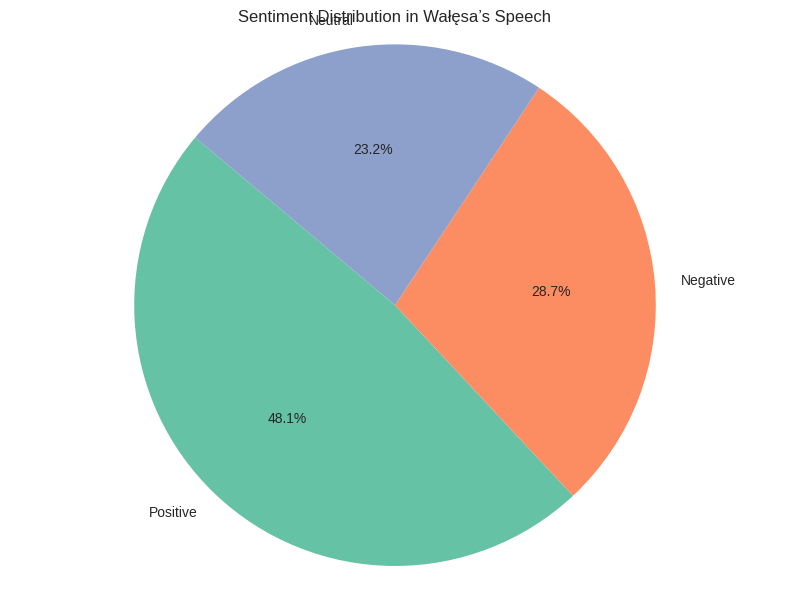

Saved bar chart to 'sentiment_bar_chart.png'.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

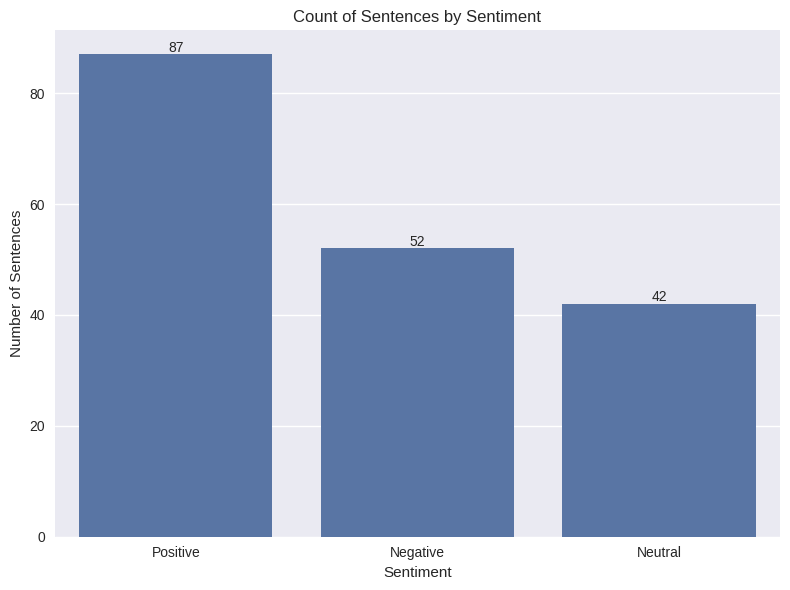

Saved histogram to 'compound_histogram.png'.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

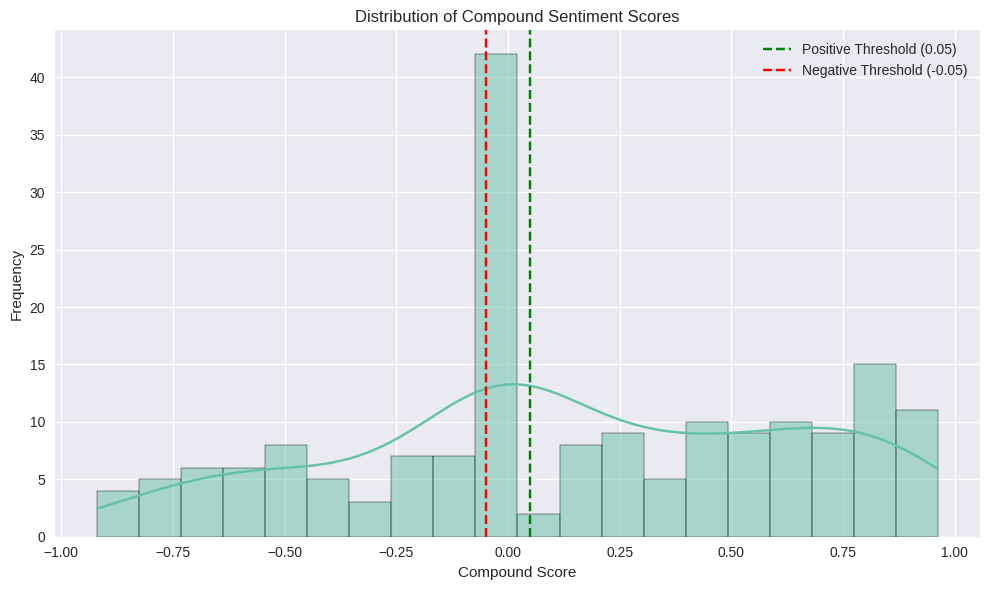


Summary Statistics:
Total sentences: 181
Positive: 87 sentences (48.1%)
Negative: 52 sentences (28.7%)
Neutral: 42 sentences (23.2%)


In [ ]:

# Install required libraries
!pip install pandas matplotlib seaborn

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io
import os

# Set plot style with fallback
try:
    plt.style.use('seaborn-v0_8')  # Use Seaborn-like style
except OSError:
    print("Warning: 'seaborn-v0_8' style not found. Using 'ggplot' instead.")
    plt.style.use('ggplot')
sns.set_palette("deep")  # Use Seaborn's color palette

def load_csv():
    """Load CSV file from user upload."""
    print("Upload your sentiment analysis CSV file (e.g., sentiment_analysis_results.csv):")
    uploaded = files.upload()
    if not uploaded:
        print("No file uploaded. Exiting.")
        return None

    # Read the first uploaded file
    for filename, content in uploaded.items():
        try:
            df = pd.read_csv(io.BytesIO(content))
            print(f"Loaded '{filename}' with {len(df)} rows.")
            return df
        except Exception as e:
            print(f"Error reading '{filename}': {e}")
            return None

def validate_data(df):
    """Validate the DataFrame for required columns."""
    required_columns = ['Text', 'Positive', 'Neutral', 'Negative', 'Compound', 'Sentiment']
    if df is None or not all(col in df.columns for col in required_columns):
        print("Error: CSV must contain columns: Text, Positive, Neutral, Negative, Compound, Sentiment")
        return None
    # Ensure numeric columns are float
    for col in ['Positive', 'Neutral', 'Negative', 'Compound']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

def plot_pie_chart(df, output_file='sentiment_pie_chart.png'):
    """Create a pie chart of sentiment distribution."""
    sentiment_counts = df['Sentiment'].value_counts()
    colors = {'Positive': '#66c2a5', 'Neutral': '#8da0cb', 'Negative': '#fc8d62'}
    plt.figure(figsize=(8, 6))
    plt.pie(sentiment_counts, labels=sentiment_counts.index,
            autopct='%1.1f%%', colors=[colors.get(x, '#999999') for x in sentiment_counts.index],
            startangle=140)
    plt.title('Sentiment Distribution in Wałęsa’s Speech')
    plt.axis('equal')
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Saved pie chart to '{output_file}'.")
    files.download(output_file)
    plt.show()

def plot_bar_chart(df, output_file='sentiment_bar_chart.png'):
    """Create a bar chart of sentiment counts."""
    sentiment_counts = df['Sentiment'].value_counts()
    plt.figure(figsize=(8, 6))
    sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values)
    plt.title('Count of Sentences by Sentiment')
    plt.xlabel('Sentiment')
    plt.ylabel('Number of Sentences')
    for i, v in enumerate(sentiment_counts.values):
        plt.text(i, v + 0.5, str(v), ha='center')
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Saved bar chart to '{output_file}'.")
    files.download(output_file)
    plt.show()

def plot_compound_histogram(df, output_file='compound_histogram.png'):
    """Create a histogram of compound scores."""
    plt.figure(figsize=(10, 6))
    sns.histplot(df['Compound'], bins=20, kde=True, color='#66c2a5')
    plt.title('Distribution of Compound Sentiment Scores')
    plt.xlabel('Compound Score')
    plt.ylabel('Frequency')
    plt.axvline(x=0.05, color='green', linestyle='--', label='Positive Threshold (0.05)')
    plt.axvline(x=-0.05, color='red', linestyle='--', label='Negative Threshold (-0.05)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Saved histogram to '{output_file}'.")
    files.download(output_file)
    plt.show()

def main():
    # Load and validate data
    df = load_csv()
    df = validate_data(df)
    if df is None:
        return

    # Generate visualizations
    print("\nGenerating visualizations...")
    plot_pie_chart(df)
    plot_bar_chart(df)
    plot_compound_histogram(df)

    # Print summary statistics
    print("\nSummary Statistics:")
    print(f"Total sentences: {len(df)}")
    sentiment_counts = df['Sentiment'].value_counts()
    for sentiment, count in sentiment_counts.items():
        print(f"{sentiment}: {count} sentences ({count/len(df)*100:.1f}%)")

if __name__ == "__main__":
    main()


In [ ]:

# Install required libraries
!pip install vaderSentiment pandas python-docx nltk deep-translator

# Import libraries
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import pandas as pd
from pathlib import Path
import nltk
nltk.download('punkt_tab')
from google.colab import files
from deep_translator import GoogleTranslator
import docx
import io
import textwrap

# Download NLTK sentence tokenizer data
try:
    nltk.download('punkt', quiet=True)
except Exception as e:
    print(f"Error downloading NLTK data: {e}")

def read_docx(file_content, filename):
    """Read text from a .docx file content."""
    try:
        doc = docx.Document(io.BytesIO(file_content))
        text = "\n".join([para.text for para in doc.paragraphs if para.text.strip()])
        return text
    except Exception as e:
        print(f"Error reading .docx file '{filename}': {e}")
        return ""

def read_txt(file_content, filename):
    """Read text from a .txt file content."""
    try:
        text = file_content.decode('utf-8')
        return text
    except UnicodeDecodeError:
        print(f"Error: File '{filename}' is not UTF-8 encoded. Try saving with UTF-8.")
        return ""
    except Exception as e:
        print(f"Error reading .txt file '{filename}': {e}")
        return ""

def translate_text(text, source_lang='pl', target_lang='en'):
    """Translate text from source language to target language."""
    try:
        translator = GoogleTranslator(source=source_lang, target=target_lang)
        return translator.translate(text)
    except Exception as e:
        print(f"Error translating text: {e}")
        return text  # Return original text if translation fails

def split_into_sentences(text):
    """Split text into sentences using NLTK."""
    try:
        sentences = nltk.sent_tokenize(text)
        return [s.strip() for s in sentences if s.strip()]
    except Exception as e:
        print(f"Error splitting text into sentences: {e}")
        return [text]  # Fallback to whole text

def analyze_sentiment(texts):
    """Analyze sentiment of a list of texts using VADER."""
    try:
        analyzer = SentimentIntensityAnalyzer()
    except Exception as e:
        print(f"Error initializing VADER: {e}")
        return []

    results = []
    for text in texts:
        try:
            scores = analyzer.polarity_scores(text)
            label = 'Positive' if scores['compound'] >= 0.05 else 'Negative' if scores['compound'] <= -0.05 else 'Neutral'
            results.append({
                'Text': text,
                'Positive': scores['pos'],
                'Neutral': scores['neu'],
                'Negative': scores['neg'],
                'Compound': scores['compound'],
                'Sentiment': label
            })
        except Exception as e:
            print(f"Error analyzing text '{text[:50]}...': {e}")
            results.append({
                'Text': text,
                'Positive': 0.0,
                'Neutral': 0.0,
                'Negative': 0.0,
                'Compound': 0.0,
                'Sentiment': 'Error'
            })

    return results

def save_results_to_csv(results, output_file='sentiment_analysis_results.csv'):
    """Save sentiment analysis results to a CSV file."""
    if not results:
        print("No results to save.")
        return

    try:
        df = pd.DataFrame(results)
        df.to_csv(output_file, index=False, encoding='utf-8')
        print(f"Results saved to '{output_file}'.")
        files.download(output_file)  # Download the file in Colab
    except Exception as e:
        print(f"Error saving to CSV: {e}")

def main():
    # Input method selection
    print("Choose input method:")
    print("1. Upload a file (.txt or .docx)")
    print("2. Paste text directly")
    choice = input("Enter 1 or 2: ")

    text = ""
    is_polish = input("Is the text in Polish? (y/n): ").lower() == 'y'

    if choice == '1':
        # File upload
        print("Upload your .txt or .docx file:")
        uploaded = files.upload()
        if not uploaded:
            print("No file uploaded. Exiting.")
            return

        # Process the uploaded file
        for filename, content in uploaded.items():
            if filename.endswith('.docx'):
                text = read_docx(content, filename)
            elif filename.endswith('.txt'):
                text = read_txt(content, filename)
            else:
                print(f"Unsupported file format: '{filename}'. Use .txt or .docx.")
                return
            break  # Process only the first file

    elif choice == '2':
        # Direct text input
        print("Paste your text below (press Enter twice to finish):")
        lines = []
        while True:
            line = input()
            if line == "":
                break
            lines.append(line)
        text = "\n".join(lines)

    else:
        print("Invalid choice. Exiting.")
        return

    if not text:
        print("No text provided. Exiting.")
        return

    # Translate if Polish
    if is_polish:
        print("Translating Polish text to English...")
        text = translate_text(text, source_lang='pl', target_lang='en')
        if not text:
            print("Translation failed. Exiting.")
            return

    # Split into sentences
    sentences = split_into_sentences(text)
    print(f"Analyzing {len(sentences)} sentences...")

    # Analyze sentiment
    results = analyze_sentiment(sentences)

    # Print summary
    print("\nSentiment Analysis Summary:")
    if results:
        sentiment_counts = pd.DataFrame(results).groupby('Sentiment').size()
        for sentiment, count in sentiment_counts.items():
            print(f"{sentiment}: {count} sentences")

    # Print sample results (first 5 sentences, truncated for readability)
    print("\nSample Results (first 5 sentences):")
    for result in results[:5]:
        wrapped_text = textwrap.shorten(result['Text'], width=100, placeholder="...")
        print(f"\nText: {wrapped_text}")
        print(f"Positive: {result['Positive']:.3f}")
        print(f"Neutral: {result['Neutral']:.3f}")
        print(f"Negative: {result['Negative']:.3f}")
        print(f"Compound: {result['Compound']:.3f} ({result['Sentiment']})")

    # Save and download results
    save_results_to_csv(results)

if __name__ == "__main__":
    main()





[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Choose input method:
1. Upload a file (.txt or .docx)
2. Paste text directly
Enter 1 or 2: 1
Is the text in Polish? (y/n): y
Upload your .txt or .docx file:


Saving Przemówienie JPII w Warszawie 1979.txt to Przemówienie JPII w Warszawie 1979 (2).txt
Translating Polish text to English...
 --> Text length need to be between 0 and 5000 characters
Analyzing 120 sentences...

Sentiment Analysis Summary:
Negative: 8 sentences
Neutral: 108 sentences
Positive: 4 sentences

Sample Results (first 5 sentences):

Text: ﻿https://jp2online.pl/obiekt/i-pielgrzymka-do-polski;-przemowienie-jana-pawla-ii-do-wladz-...
Positive: 0.000
Neutral: 1.000
Negative: 0.000
Compound: 0.000 (Neutral)

Text: Umiłowani Rodacy, Drodzy Bracia i Siostry, Uczestnicy eucharystycznej Ofiary, która sprawuje się...
Positive: 0.000
Neutral: 1.000
Negative: 0.000
Compound: 0.000 (Neutral)

Text: Razem z wami pragnę wyśpiewać pieśń dziękczynienia dla Opatrzności, która pozwala mi dziś jako...
Positive: 0.000
Neutral: 1.000
Negative: 0.000
Compound: 0.000 (Neutral)

Text: Pragnął – wiemy, że bardzo gorąco pragnął – stanąć na ziemi polskiej, przede wszystkim na Jasnej...
Positive: 0

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import random
import string
import re
from collections import Counter
from textstat import textstat

# Lista przykładowych słów do generowania tekstu
WORDS = [
    "lorem", "ipsum", "dolor", "sit", "amet", "consectetur", "adipiscing",
    "elit", "sed", "do", "eiusmod", "tempor", "incididunt", "ut", "labore",
    "et", "dolore", "magna", "aliqua", "ut", "enim", "ad", "minim", "veniam"
]

def generate_random_text(num_sentences=10, min_words=5, max_words=15):
    """Generuje losowy tekst składający się z podanej liczby zdań."""
    text = ""
    for _ in range(num_sentences):
        sentence_length = random.randint(min_words, max_words)
        sentence = " ".join(random.choice(WORDS) for _ in range(sentence_length))
        # Pierwsza litera wielka, na końcu kropka
        sentence = sentence.capitalize() + "."
        text += sentence + " "
    return text.strip()

def analyze_text(text):
    """Przeprowadza analizę statystyczną tekstu."""
    # Przygotowanie tekstu
    words = re.findall(r'\b\w+\b', text.lower())
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if s.strip()]

    # a) Całkowita liczba słów
    total_words = len(words)

    # b) Liczba unikalnych słów
    unique_words = len(set(words))

    # c) Gęstość słownictwa ( stosunek unikalnych słów do całkowitej liczby słów)
    lexical_density = (unique_words / total_words) * 100 if total_words > 0 else 0

    # d) Wskaźnik czytelności (używamy Flesch Reading Ease)
    readability = textstat.flesch_reading_ease(text)

    # e) Średnia liczba słów w zdaniu
    avg_words_per_sentence = total_words / len(sentences) if sentences else 0

    # f) Najczęściej występujące słowa
    word_counts = Counter(words)
    most_common_words = word_counts.most_common(5)

    # Wyniki
    results = {
        'total_words': total_words,
        'unique_words': unique_words,
        'lexical_density': round(lexical_density, 2),
        'readability': round(readability, 2),
        'avg_words_per_sentence': round(avg_words_per_sentence, 2),
        'most_common_words': most_common_words
    }
    return results

def print_analysis(results):
    """Wypisuje wyniki analizy w czytelny sposób."""
    print("Analiza statystyczna tekstu:")
    print(f"1. Całkowita liczba słów: {results['total_words']}")
    print(f"2. Liczba unikalnych słów: {results['unique_words']}")
    print(f"3. Gęstość słownictwa: {results['lexical_density']}%")
    print(f"4. Wskaźnik czytelności (Flesch Reading Ease): {results['readability']}")
    print(f"5. Średnia liczba słów w zdaniu: {results['avg_words_per_sentence']}")
    print("6. Najczęściej występujące słowa:")
    for word, count in results['most_common_words']:
        print(f"   - {word}: {count} razy")

# Główna funkcja
def main():
    # Generowanie losowego tekstu
    random_text = generate_random_text()
    print("Wygenerowany tekst:")
    print(random_text)
    print("\n")

    # Analiza tekstu
    results = analyze_text(random_text)

    # Wypisanie wyników
    print_analysis(results)

if __name__ == "__main__":
    main()

Wygenerowany tekst:
Eiusmod elit et ipsum lorem ut labore labore minim tempor et. Consectetur magna sit sit incididunt do. Minim ut sed elit labore ut ut amet ad sit dolore. Ipsum incididunt amet sit et. Minim incididunt magna aliqua aliqua amet dolor ipsum veniam enim sit ut enim adipiscing. Sed adipiscing veniam eiusmod ut lorem incididunt minim eiusmod minim dolor ad ut consectetur. Ad lorem sed et minim ipsum minim lorem minim minim enim incididunt amet. Amet minim ad magna ad magna ad do dolore. Minim ad sit consectetur enim dolore. Adipiscing sit ut elit dolor dolor dolore amet et.


Analiza statystyczna tekstu:
1. Całkowita liczba słów: 98
2. Liczba unikalnych słów: 23
3. Gęstość słownictwa: 23.47%
4. Wskaźnik czytelności (Flesch Reading Ease): 55.31
5. Średnia liczba słów w zdaniu: 9.8
6. Najczęściej występujące słowa:
   - minim: 11 razy
   - ut: 8 razy
   - sit: 7 razy
   - ad: 7 razy
   - amet: 6 razy


In [ ]:
import re
from collections import Counter
from textstat import textstat

def analyze_text(text):
    """Przeprowadza analizę statystyczną tekstu."""
    # Przygotowanie tekstu
    words = re.findall(r'\b\w+\b', text.lower())
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if s.strip()]

    # a) Całkowita liczba słów
    total_words = len(words)

    # b) Liczba unikalnych słów
    unique_words = len(set(words))

    # c) Gęstość słownictwa (stosunek unikalnych słów do całkowitej liczby słów)
    lexical_density = (unique_words / total_words) * 100 if total_words > 0 else 0

    # d) Wskaźnik czytelności (używamy Flesch Reading Ease)
    readability = textstat.flesch_reading_ease(text)

    # e) Średnia liczba słów w zdaniu
    avg_words_per_sentence = total_words / len(sentences) if sentences else 0

    # f) Najczęściej występujące słowa
    word_counts = Counter(words)
    most_common_words = word_counts.most_common(5)

    # Wyniki
    results = {
        'total_words': total_words,
        'unique_words': unique_words,
        'lexical_density': round(lexical_density, 2),
        'readability': round(readability, 2),
        'avg_words_per_sentence': round(avg_words_per_sentence, 2),
        'most_common_words': most_common_words
    }
    return results

def print_analysis(results):
    """Wypisuje wyniki analizy w czytelny sposób."""
    print("Analiza statystyczna tekstu:")
    print(f"1. Całkowita liczba słów: {results['total_words']}")
    print(f"2. Liczba unikalnych słów: {results['unique_words']}")
    print(f"3. Gęstość słownictwa: {results['lexical_density']}%")
    print(f"4. Wskaźnik czytelności (Flesch Reading Ease): {results['readability']}")
    print(f"5. Średnia liczba słów w zdaniu: {results['avg_words_per_sentence']}")
    print("6. Najczęściej występujące słowa:")
    for word, count in results['most_common_words']:
        print(f"   - {word}: {count} razy")

# Tekst do analizy
text = "For only the third time in history, a foreigner who is not a head of state addresses a joint meeting of the United States Congress. Lech Walesa visited Washington, D.C. just a few days after the fall of the Berlin Wall. He is a symbol of the bloodless and effective fight against communism. In his address, he notes that Poland's ambitions for freedom - indeed, the whole region's ambitions - have not yet been fulfilled. The transformation process can only be successful with the active involvement of the West."

# Główna funkcja
def main():
    print("Analizowany tekst:")
    print(text)
    print("\n")

    # Analiza tekstu
    results = analyze_text(text)

    # Wypisanie wyników
    print_analysis(results)

if __name__ == "__main__":
    main()

Analizowany tekst:
For only the third time in history, a foreigner who is not a head of state addresses a joint meeting of the United States Congress. Lech Walesa visited Washington, D.C. just a few days after the fall of the Berlin Wall. He is a symbol of the bloodless and effective fight against communism. In his address, he notes that Poland's ambitions for freedom - indeed, the whole region's ambitions - have not yet been fulfilled. The transformation process can only be successful with the active involvement of the West.


Analiza statystyczna tekstu:
1. Całkowita liczba słów: 90
2. Liczba unikalnych słów: 66
3. Gęstość słownictwa: 73.33%
4. Wskaźnik czytelności (Flesch Reading Ease): 60.84
5. Średnia liczba słów w zdaniu: 12.86
6. Najczęściej występujące słowa:
   - the: 9 razy
   - a: 5 razy
   - of: 5 razy
   - for: 2 razy
   - only: 2 razy


In [ ]:
import re
from collections import Counter

def analyze_text(text):
    """Przeprowadza analizę statystyczną tekstu."""
    # Przygotowanie tekstu
    words = re.findall(r'\b\w+\b', text.lower())
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if s.strip()]

    # a) Całkowita liczba słów
    total_words = len(words)

    # b) Liczba unikalnych słów
    unique_words = len(set(words))

    # c) Gęstość słownictwa (stosunek unikalnych słów do całkowitej liczby słów)
    lexical_density = (unique_words / total_words) * 100 if total_words > 0 else 0

    # e) Średnia liczba słów w zdaniu
    avg_words_per_sentence = total_words / len(sentences) if sentences else 0

    # f) Najczęściej występujące słowa
    word_counts = Counter(words)
    most_common_words = word_counts.most_common(5)

    # Wyniki
    results = {
        'total_words': total_words,
        'unique_words': unique_words,
        'lexical_density': round(lexical_density, 2),
        'avg_words_per_sentence': round(avg_words_per_sentence, 2),
        'most_common_words': most_common_words
    }
    return results

def print_analysis(results):
    """Wypisuje wyniki analizy w czytelny sposób."""
    print("Analiza statystyczna tekstu:")
    print(f"1. Całkowita liczba słów: {results['total_words']}")
    print(f"2. Liczba unikalnych słów: {results['unique_words']}")
    print(f"3. Gęstość słownictwa: {results['lexical_density']}%")
    print(f"4. Średnia liczba słów w zdaniu: {results['avg_words_per_sentence']}")
    print("5. Najczęściej występujące słowa:")
    for word, count in results['most_common_words']:
        print(f"   - {word}: {count} razy")

# Tekst do analizy
text = """fective fight against communism. In his address, he notes that Poland's ambitions for freedom - indeed, the whole region's ambitions - have not yet been fulfilled. The transformation process can only be successful with the active involvement of the West."""

# Główna funkcja
def main():
    print("Analizowany tekst:")
    print(text)
    print("\n")

    # Analiza tekstu
    results = analyze_text(text)

    # Wypisanie wyników
    print_analysis(results)

if __name__ == "__main__":
    main()

In [ ]:
import re
from collections import Counter

def analyze_text(text):
    """Przeprowadza analizę statystyczną tekstu."""
    # Przygotowanie tekstu
    words = re.findall(r'\b\w+\b', text.lower())
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if s.strip()]

    # a) Całkowita liczba słów
    total_words = len(words)

    # b) Liczba unikalnych słów
    unique_words = len(set(words))

    # c) Gęstość słownictwa (stosunek unikalnych słów do całkowitej liczby słów)
    lexical_density = (unique_words / total_words) * 100 if total_words > 0 else 0

    # e) Średnia liczba słów w zdaniu
    avg_words_per_sentence = total_words / len(sentences) if sentences else 0

    # f) Najczęściej występujące słowa
    word_counts = Counter(words)
    most_common_words = word_counts.most_common(5)

    # Wyniki
    results = {
        'total_words': total_words,
        'unique_words': unique_words,
        'lexical_density': round(lexical_density, 2),
        'avg_words_per_sentence': round(avg_words_per_sentence, 2),
        'most_common_words': most_common_words
    }
    return results

def print_analysis(results):
    """Wypisuje wyniki analizy w czytelny sposób."""
    print("Analiza statystyczna tekstu:")
    print(f"1. Całkowita liczba słów: {results['total_words']}")
    print(f"2. Liczba unikalnych słów: {results['unique_words']}")
    print(f"3. Gęstość słownictwa: {results['lexical_density']}%")
    print(f"4. Średnia liczba słów w zdaniu: {results['avg_words_per_sentence']}")
    print("5. Najczęściej występujące słowa:")
    for word, count in results['most_common_words']:
        print(f"   - {word}: {count} razy")

# Tekst do analizy
text = """
ww.respublica.pl
We, the people
Lech Wałęsa adresses joint session of the United States Congress
November 15, 1989
”For only the third time in history, a foreigner who is not a head of state addresses a joint meeting of the United States Congress. Lech Wałęsa visited Washington, D.C. just a few days after the fall of the Berlin Wall. He is a symbol of the bloodless and effective fight against communism. In his address, he notes that Poland’s ambitions for freedom – indeed, the whole region’s ambitions – have not yet been fulfilled. The transformation process can only be successful with the active involvement of the West.”

Mr. Speaker,
Mr. President,
members of the Cabinet,
distinguished members of the House and Senate.
“We the People”. With these words I wish to begin my address. I do not need to remind anyone here where these words come from. And I do not need to explain that I – an electrician from Gdansk – am also entitled to invoke them.
I stand before you as the third foreign non-head of state invited to address the joint Houses of Congress of the United States. This Congress, which, for many people in the world, oppressed and stripped of their rights, is a beacon of freedom and a bulwark of human rights. And here, I stand before you, to speak to America in the name of my nation. To speak to citizens of the country and the continent whose threshold is guarded by the famous Statue of Liberty. It is for me an honor so great, a moment so solemn, that I cannot find anything to compare it with.
People in Poland link the name of the United States with freedom and democracy, with generosity and high mindedness, with human friendship and friendly humanity. I realize that not everywhere is America so perceived. I speak of her image in Poland. This image has been strengthened by numerous favorable historical experiences, and it is very well known that Poles repay warm heartedness in kind.
The world remembers the wonderful principle of American democracy: “Government of the people, by the people, for the people.” I do remember these words. I, a shipyard worker from Gdańsk, have devoted my entire life, along with other members of the Solidarity movement, to the service of this idea: “Government of the people, by the people, for the people”. Against privilege and monopoly. Against violations of the law. Against the trampling of human dignity. Against contempt and injustice.
Such, in fact, are the principles and values reminiscent of Abraham Lincoln and the founding fathers of the American Republic, as well as the principles and ideas of the American Declaration of Independence and the American Constitution. These principles are pursued by the great Polish Solidarity movement; a movement that is effective.
I know that Americans are idealistic, but at the same time, practical people, endowed with common sense and capable of logical action. They combine these features with belief in the ultimate victory of right over wrong. But they prefer effective work to making speeches, and I understand them very well. I am not a fan of speeches. I prefer facts and work. I treasure effectiveness.
Ladies and gentleman, the fundamental and most important thing that I would like to tell you about is that the social movement bearing the beautiful name “Solidarity”, born of the Polish nation, is an effective movement. After many long years of struggle, it bore fruit and the results are there for all to see today. It set the direction and developed a way of action that has affected the lives of millions of people speaking different languages. It has swayed monopolies,
And the struggle was conducted without resorting to violence of any kind, a point that cannot be stressed too much. We were being locked up in prisons, deprived of our jobs, beaten, and sometimes killed. And we did not so much as strike a single person. We did not destroy anything. We did not smash a single window pane. But we were stubborn. Very stubborn. Ready to suffer, to make sacrifices. We knew what we wanted, and our power prevailed in the end.
The Solidarity movement received much support and scored victories, because at all times and in all matters, it opted for the better, more human, and more dignified solutions, standing against brutality and hate. It was a consistent and persistent movement, never giving up. And that is why after all these hard years, marked by so many tragic moments, Solidarity is today succeeding and showing the way to millions of people in Poland and other countries.
Ladies and gentleman, it was ten years ago, in August 1980, that the famous strike began in the Gdansk shipyards that led to the emergence of the first independent trade union in communist countries, and soon became a vast social movement, supported by the Polish nation. I was ten years younger then, unknown to anybody but my friends in the shipyard, and somewhat slimmer. And I must frankly say that it was important. I was an unemployed man at that time, fired from my job for earlier attempts to organize workers in the fight for their rights. I jumped over the shipyard wall and rejoined my former colleagues, who promptly appointed me leader of the strike. This is how it all began.
When I recall the road we travelled, I often think of that jump over the fence. Now others jump fences and tear down walls. They do it because freedom is a human right. But there is also another reflection that comes to mind when I think of the road behind us. In those days, at the beginning, many warnings, admonitions, and even condemnations reached us from many parts of the world.
“What are those Poles up to?” we heard. “They are mad!” “They are jeopardizing world peace and European stabilit!” “They ought to stay quiet and not get on anybody’s nerves”. From those voices we gathered that other nations have the right to live in comfort and prosperity, they have the right to democracy and freedom, and it is only Poles who should give up these rights so as not to disturb the peace of others.
In the days before the Second World War there were many people who asked: “Why should we die for Gdańsk, isn’t it better to stay home?” But war soon paid them a visit. And they had to start dying, for Paris, for London, for Hawaii. This time, too, there were many who complained: “There is that Gdansk again, disturbing our peace!”
But the recent developments in Gdańsk carried a different message. This is not the beginning, but the true end of that war. That was the beginning of a new, better, democratic, and safe era in the history of our world. It is no longer a question of “dying for Gdańsk”, but of “living for it”.
Looking at what is happening around us today, we may affirm that the path of struggle followed by Poland in quest of human rights, a struggle without violence and characterized by typical Polish stubbornness and firmness in the quest for pluralism and democracy, shows many people today, and even nations, how to avoid the greatest dangers of conflict.
If there is something threatening European stability today it is certainly not Poland. Poland is driving towards its own profound transformation; transformation achieved through peaceful means, through evolution, negotiated with all the parties concerned, which makes it possible to avoid the worst. And perhaps is held up as a model for many other regions. For, as we know, changes elsewhere are not so peaceful. Peacefully and prudently, with their eyes open to danger but not giving up what is right and necessary, the Poles gradually paved a way for historic transformations.
We are joined along this way, to various extents, by others: Hungarians and Russians, Ukrainians and the people from the Baltic states, Armenians and Georgians, and in recent days East Germans. We wish them luck and rejoice each success they achieve. We are certain that others will also take road we have followed, as there is no other choice!
So now I ask, is there is any sensible man understanding the world around him who could justifiably say today that it would be better for the Poles to keep quiet, because what they are doing is jeopardizing world peace? Could we even dare say that Poles are doing more to preserve and consolidate peace than many of their frightened advisors? Could we not say that stability and peace is under greater threat from countries which have not yet brought themselves to carry out far-reaching and comprehensive reforms, which do their utmost to preserve the old and disgraced ways of government, contrary to the wishes of their societies?
Things are different in Poland. And I must say that our task is viewed with understanding by our Eastern neighbors and their leader Mikhail Gorbachev. This understanding lays the foundation for new relations between Poland and the Soviet Union, relations which are much better than before. These improved mutual relations will also contribute to stabilization and peace in Europe, removing useless tensions.
The Poles have a long and difficult history, and no one wants more than we do peaceful coexistence and friendship with all nations and countries, and particularly with the Soviet Union. We believe that it is only now that the right and favorable conditions for such coexistence and friendship are emerging. Poland is making an important contribution to a better future for Europe, to European reconciliation. And also to the vast and important Polish-German reconciliation. To overcoming all the divisions and the strengthening of human rights on our continent. But it does not come easily for Poland.
In the Second World War, Poland was the first country to fall victim to aggression. Her losses in terms of human life and national property were the heaviest. Her fight was the longest; she was always a dedicated member of the victorious alliance and her soldiers fought in all the world theatres. In 1945 Poland was, theoretically speaking, one of the victors. Theory, however, had little in common with practice.
In practice, as her allies looked on in passive consent, an alien system of government was imposed in Poland, without a president in the Polish tradition, unaccepted by the nation, together with an alien economy, an alien law, and an alien philosophy of social relations. The legal Polish government, recognized by the nation, and leading the struggle of all Poles throughout the war was condemned, and those who remained faithful to it were subjected to the most ruthless persecution. Many were murdered. Thousands vanished somewhere into Russia’s East and North. Civilian repression without soldiers of the underground army that fought the Nazis. And it is only now that we are discovering their bones in unmarked graves scattered among the forests.
This was followed by persecutions of all those who dared to think independently. All the solemn pledges about free elections in Poland that were made in Yalta were broken. It was the second great national catastrophe following the catastrophe of 1939. When other nations were joyously celebrating victory, Poland was again sinking into mourning.
The awareness of this tragedy was doubly bitter, as the Poles realized that they had been abandoned by their allies. The memory of this is still strong in the minds of many. Nevertheless, the Poles took to rebuilding their devastated country, and in the first years following the war they were highly successful. But soon a new economic system was introduced, in which individual entrepreneurship ceased to exist, and the entire economy ended up in the hands of the state, run by people who were not elected by the nation.
Stalin forbade Poland to use aid provided by the Marshall Plan; aid that was used by everyone in Western Europe, including countries which lost the war. It is worth recalling now that great American plan which helped Western Europe to protect its freedom and peaceful order. And now is the moment when Eastern Europe awaits an investment of this kind, an investment in freedom, democracy, and peace. An investment adequate to the greatness of the American nation.
The Poles have travelled a long way. It would be worthwhile for all those commenting on Poland, often criticizing Poland, to bear in mind that, whatever Poland has achieved, she achieved through her own effort, through her own stubbornness, her own relentlessness. Everything was achieved thanks to the unflinching faith of our nation in human dignity, and in what is described as the values of Western culture and civilization. Our nation well knows the price of all this.
Ladies and gentleman, for the past fifty years, the Polish nation has been engaged in a difficult and exhausting battle. First to preserve its very biological existence. Later to save its national identity. In both instances, Polish determination was there. Today, Poland is rejoining the family of democratic and pluralistic countries, returning to the tradition of religious and European values. For the first time in half a century, Poland has a non-communist and independent government supported by the nation.
But in our past there looms a serious obstacle. A great danger. Our long subjection to a political system incompatible with national traditions, to an economic system incompatible with rationality and common sense, coupled with a stifling of independent thought and disregard for national interest has led the Polish economy to ruin, to the verge of utter catastrophe. The first government in fifty years elected by the people and serving the people has inherited from the previous rulers of the country the burden of an economy organized in a manner which prevents it from satisfying even the basic needs of its people.
The economy we inherited after almost five decades of communist rule is in need of overhaul. This will require patience and great sacrifice. This will require time and means. The present condition of the Polish economy is not due to change, as it is not specifically a Polish predicament. All the countries of the Eastern Bloc are bankrupt today. The communist economy has failed in every part of the world. One result of this is the exile of citizens of those countries, by land and by sea, by boat and by plane, swimming and walking across borders. This is a mass scale phenomenon, well known in Europe, Asia, and Central America.
But Poland has taken its new road and will never be turned back. The sense of our work and struggle in Poland lies in our creating situations and prospects that would hold Poles back from seeking a place for themselves abroad; that would encourage them to seek meaning in their work and hope for a better future in their own country, their own home. One sometimes hears that people in Poland do not care to work well. But even those who say this know that Poles work well and effectively, if only they see the sense and usefulness of their work. The working people know their arithmetic too. They are working much harder and in worse conditions than their opposite numbers abroad, and on top of that, they are paid much lower wages. The economic system around them is absurd. To make matters worse, every several or dozen years, the country suffered a new crisis, a new crunch, and time and time again it has turned out that past efforts went to waste. Show me the people who would have worked well stuck for decades under such a system. Wouldn’t they too have succumbed to pessimism?
The system has to be changed and the Poles have taken it upon themselves to change it. I know that America has her own problems and difficulties, some of them very serious. We are not asking for charity, we are not expecting philanthropy. But we would like to see our country treated as a partner and a friend. We would like cooperation under decent and favorable conditions. We would like Americans to come to us with proposals of cooperation, bringing benefits to both sides. We believe that assistance, extended to democracy and freedom in Poland and all of Eastern Europe, is the best investment in the future and in peace, better than tanks, warships, and warplanes; an investment leading to greater security.
Poland has already done much to patch up the divisions existing in Europe, to create better and more optimistic prospects. Poland’s efforts are viewed with sympathetic interest by the West; and for this thanks are in order. We believe that the West’s contribution to the process will now grow. We have heard many beautiful words of encouragement. These are appreciated, but being a worker and a man of concrete work I must tell you that the supply of words on the world market is plentiful, but the demand is falling. Let deeds follow words now.
The decision by the Congress of the United States about granting economic aid to my country opens a new road. For this wonderful decision, I thank you warmly. And I promise you that “this” aid will not be wasted and will never be forgotten.
Ladies and gentleman, from this podium I am expressing words of gratitude to the American people. It is they who supported us in the difficult days of Martial Law and persecution. It is they who sent us aid. They protested against violence. Today, when I am able to freely address the whole world from this elevated spot, I would like to thank them with special words. It is thanks to them that the world “Solidarity” soared across borders and has reached every corner of the world, and thanks to them the people of Solidarity were never alone.
In this chain of people linked to Solidarity there were many, many Americans. I wish to mention here with warm gratitude our friends from the United States Congress, the AFL-CIO trade unions, from the institutions and foundations supporting freedom and democracy, and all those who lent us support in our most difficult moments. They live in all states, in large and small communities of your vast country.
I thank all those who through the airwaves or printed word “spread the truth”. I also wish to say thank you and to greet all Polish-Americans who maintained warm contact with their old fatherland. Their support was always priceless for us.
I wholeheartedly thank the President of the United States and his administration for its involvement in my country’s affairs. I will never forget the then Vice-President, George Bush, speaking over the tomb of the reverent Jerzy Popiełuszko, the martyr of Poland. And I will never forget President George Bush speaking in Gdansk, in front of the monument of the falling shipyard workers. It is from there that the President of the United States was sending a message of freedom to Poland, to Europe, to the world.
Pope John Paul II once said: “Freedom is not just something to have and to use, it is something to be fought for; one must use freedom to build one’s personal life as well as the life of the nation.” I think this weighted thought can equally well be applied to Poland and America. I wish all of you to know and to keep in mind that the ideals which underline this glorious American Republic, and which are still alive here, are also alive and well in faraway Poland. And although for many long years efforts were made to cut Poland off from these ideals, she held her ground and is now reaching for the freedom to which she is justly entitled.
Together with Poland, other nations of Eastern Europe are following this path. The wall that separated people from freedom has collapsed.




 """

# Główna funkcja
def main():
    print("Analizowany tekst:")
    print(text)
    print("\n")

    # Analiza tekstu
    results = analyze_text(text)

    # Wypisanie wyników
    print_analysis(results)

if __name__ == "__main__":
    main()

Analizowany tekst:
 
ww.respublica.pl
We, the people
Lech Wałęsa adresses joint session of the United States Congress
November 15, 1989
”For only the third time in history, a foreigner who is not a head of state addresses a joint meeting of the United States Congress. Lech Wałęsa visited Washington, D.C. just a few days after the fall of the Berlin Wall. He is a symbol of the bloodless and effective fight against communism. In his address, he notes that Poland’s ambitions for freedom – indeed, the whole region’s ambitions – have not yet been fulfilled. The transformation process can only be successful with the active involvement of the West.”
 
Mr. Speaker,
Mr. President,
members of the Cabinet,
distinguished members of the House and Senate.
“We the People”. With these words I wish to begin my address. I do not need to remind anyone here where these words come from. And I do not need to explain that I – an electrician from Gdansk – am also entitled to invoke them.
I stand before you as

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
import spacy
from collections import Counter

# Pobieranie stopwords z NLTK
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Ładowanie modelu spacy do lematyzacji
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

def preprocess_text(text):
    """Przygotowuje tekst: tokenizacja, lematyzacja, usuwanie stopwords."""
    # Podział na zdania
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if s.strip()]

    # Przetwarzanie tekstu
    processed_sentences = []
    all_tokens = []
    for sentence in sentences:
        doc = nlp(sentence.lower())
        tokens = [token.lemma_ for token in doc if token.is_alpha and not token.is_punct]
        tokens = [token for token in tokens if token not in stop_words]
        processed_sentences.append(tokens)
        all_tokens.extend(tokens)

    return sentences, processed_sentences, all_tokens

def extract_topics(all_tokens, num_keywords=5):
    """Wybiera kluczowe słowa na podstawie częstotliwości."""
    word_counts = Counter(all_tokens)
    # Wybierz najczęstsze słowa jako kluczowe dla tematów
    keywords = [word for word, _ in word_counts.most_common(num_keywords)]
    return keywords

def assign_sentences_to_topics(sentences, processed_sentences, keywords):
    """Przypisuje zdania do tematów na podstawie kluczowych słów."""
    sentence_topics = []
    for i, (sentence, tokens) in enumerate(zip(sentences, processed_sentences)):
        # Sprawdzanie, które kluczowe słowa występują w zdaniu
        found_keywords = [kw for kw in keywords if kw in tokens]
        sentence_topics.append((sentence, found_keywords))
    return sentence_topics

# Tekst do analizy
text = """ https://jp2online.pl/obiekt/i-pielgrzymka-do-polski;-przemowienie-jana-pawla-ii-do-wladz-panstwowych-wygloszone-w-belwederze-podczas;-warszawa-2-czerwca-1979-r-;T2JqZWN0OjIwOQ==

Niech będzie pochwalony Jezus Chrystus!
Umiłowani Rodacy,
Drodzy Bracia i Siostry,
Uczestnicy eucharystycznej Ofiary, która sprawuje się dziś w Warszawie na placu Zwycięstwa,
1. Razem z wami pragnę wyśpiewać pieśń dziękczynienia dla Opatrzności, która pozwala mi dziś jako pielgrzymowi stanąć na tym miejscu.
Pragnął – wiemy, że bardzo gorąco pragnął – stanąć na ziemi polskiej, przede wszystkim na Jasnej Górze, zmarły niedawno papież Paweł VI. Pierwszy po wielu stuleciach papież-pielgrzym. Do końca życia nosił to pragnienie w swoim sercu i z nim zszedł do grobu. I oto czujemy, że pragnienie to było tak potężne i tak głęboko uzasadnione, że przerosło ramy jednego pontyfikatu i – w sposób po ludzku trudny do przewidzenia – realizuje się dzisiaj. Dziękujemy więc Bożej Opatrzności za to, że dała Pawłowi VI tak potężne pragnienie. Dziękujemy za cały ten styl papieża-pielgrzyma, jaki zapoczątkował wraz z Soborem Watykańskim II. Gdy bowiem Kościół cały uświadomił sobie na nowo, iż jest Ludem Bożym – Ludem, który uczestniczy w posłannictwie Chrystusa, Ludem, który z tym posłannictwem idzie przez dzieje, który „pielgrzymuje”, papież nie mógł dłużej pozostać „więźniem Watykanu”. Musiał stać się na nowo Piotrem pielgrzymującym, tak jak ten pierwszy, który z Jerozolimy przywędrował poprzez Antiochię do Rzymu, aby tam dać świadectwo Chrystusowi i przypieczętować je swoją krwią.
Dzisiaj dane mi jest wypełnić to pragnienie zmarłego papieża Pawła VI wśród was, umiłowani synowie i córki mojej Ojczyzny. Kiedy bowiem – z niezbadanych wyroków Bożej Opatrzności po śmierci Pawła VI i po kilkutygodniowym zaledwie pontyfikacie mojego bezpośredniego poprzednika Jana Pawła I – zostałem głosami kardynałów wezwany ze stolicy św. Stanisława w Krakowie na stolicę św. Piotra w Rzymie, zrozumiałem natychmiast, że moim szczególnym zadaniem jest spełnienie tego pragnienia, którego Paweł VI nie mógł dopełnić na milenium chrztu Polski.
Jako więc wasz rodak, syn polskiej ziemi, a zarazem jako papież-pielgrzym witam was wszystkich! Witam najdostojniejszego Prymasa Polski. Witam wszystkich obecnych tutaj arcybiskupów, biskupów, pasterzy Kościoła w naszej Ojczyźnie. Pozwólcie, że pośród naszych gości powitam w sposób szczególny kardynała-arcybiskupa Santo Domingo. To tam wypadało mi skierować pierwsze kroki papieskiego pielgrzymowania w miesiącu styczniu. Tam po raz pierwszy ucałowałem ziemię, na której stanęła kiedyś stopa Krzysztofa Kolumba, po której przeszły stopy tylu głosicieli Ewangelii, a wśród nich także i naszych rodaków i polskich żołnierzy. Dzisiaj, wspólnie z wami, tego świadka mojej pierwszej papieskiej podróży witam w Warszawie.
Czyż moja pielgrzymka do Ojczyzny w roku, w którym Kościół w Polsce obchodzi dziewięćsetną rocznicę śmierci św. Stanisława, nie jest zarazem jakimś szczególnym znakiem naszego polskiego pielgrzymowania poprzez dzieje Kościoła – nie tylko po szlakach naszej Ojczyzny, ale zarazem Europy i świata? Odsuwam tutaj na bok moją własną osobę – niemniej muszę wraz z wami wszystkimi stawiać sobie pytanie o motyw, dla którego właśnie w roku 1978 (po tylu stuleciach ustalonej w tej dziedzinie tradycji) został na rzymską stolicę św. Piotra wezwany syn polskiego narodu, polskiej ziemi. Od Piotra, jak i od wszystkich apostołów Chrystus żądał, aby byli Jego „świadkami w Jerozolimie i w całej Judei, i w Samarii, i aż po krańce ziemi” (Dz 1,8).
Czyż przeto nawiązując do tych Chrystusowych słów, nie wolno nam wnosić zarazem, że Polska stała się w naszych czasach ziemią szczególnie odpowiedzialnego świadectwa? Że właśnie stąd – z Warszawy, a także z Gniezna, z Jasnej Góry, z Krakowa, z całego tego historycznego szlaku, który tyle razy nawiedzałem w swoim życiu i który w tych dniach znów będę miał szczęście nawiedzić, że właśnie stąd ze szczególną pokorą, ale i ze szczególnym przekonaniem trzeba głosić Chrystusa? Że właśnie tu, na tej ziemi, na tym szlaku, trzeba stanąć, aby odczytać świadectwo Jego Krzyża i Jego Zmartwychwstania? Ale, umiłowani rodacy – jeśli przyjąć to wszystko, co w tej chwili ośmieliłem się wypowiedzieć – jakżeż ogromne z tego rodzą się zadania i zobowiązania! Czy do nich naprawdę dorastamy?
2. Dane mi jest dzisiaj, na pierwszym etapie mojej papieskiej pielgrzymki do Polski, sprawować Najświętszą Ofiarę w Warszawie, na placu Zwycięstwa. Liturgia sobotniego wieczoru, w przeddzień Zesłania Ducha Świętego przenosi nas do wieczernika w Jerozolimie, w którym nazajutrz apostołowie – zgromadzeni wokół Maryi, Matki Chrystusa – mają otrzymać Ducha Świętego. Otrzymają Ducha, którego Chrystus im wyjednał przez krzyż, aby w mocy tego Ducha mogli wypełnić Jego polecenie. „Idźcie więc i nauczajcie wszystkie narody, udzielając im chrztu w imię Ojca i Syna, i Ducha Świętego. Uczcie je zachowywać wszystko, co wam przykazałem” (Mt 28,19-20). W takich słowach Chrystus Pan przed swym odejściem ze świata przekazał apostołom swe ostatnie polecenie, swój „mandat misyjny”. I dodał: „A oto Ja jestem z wami przez wszystkie dni aż do skończenia świata” (Mt 28,20).
Dobrze się stało, że moja pielgrzymka do Polski, związana z dziewięćsetną rocznicą męczeńskiej śmierci św. Stanisława, wypadła w okresie Zesłania Ducha Świętego oraz uroczystości Trójcy Przenajświętszej. W taki bowiem sposób mogę, dopełniając jakby pośmiertnie pragnienia Pawła VI, przeżyć raz jeszcze tysiąclecie chrztu na ziemi polskiej i wpisać tegoroczny Stanisławowy jubileusz w to tysiąclecie, z którego wzięły początek całe dzieje narodu i Kościoła. Właśnie uroczystość Zesłania Ducha Świętego oraz Trójcy Przenajświętszej szczególnie nas przybliża do tego początku. W apostołach, którzy otrzymują Ducha Świętego w dzień Zielonych Świąt, są już niejako duchowo obecni wszyscy ich następcy, wszyscy biskupi, również ci, którym od tysiąca lat wypadło głosić Ewangelię na ziemi polskiej. Również ten Stanisław ze Szczepanowa, który swoje posłannictwo na stolicy krakowskiej okupił krwią przed dziewięcioma wiekami.
I są w tych apostołach i wokół nich – w dniu Zesłania Ducha Świętego – zgromadzeni nie tylko przedstawiciele tych ludów i języków, które wymienia księga Dziejów Apostolskich. Są wokół nich już wówczas zgromadzone różne ludy i narody, które przyjdą do Kościoła poprzez światło Ewangelii i moc Ducha Świętego w różnych epokach, w różnych stuleciach. Dzień Zielonych Świąt jest dniem narodzin wiary i Kościoła również na naszej polskiej ziemi. Jest to początek przepowiadania wielkich spraw Bożych również w naszym polskim języku. Jest to początek chrześcijaństwa również w życiu naszego narodu: w jego dziejach, w jego kulturze, w jego doświadczeniach.
3. Kościół przyniósł Polsce Chrystusa – to znaczy klucz do rozumienia tej wielkiej i podstawowej rzeczywistości, jaką jest człowiek. Człowieka bowiem nie można do końca zrozumieć bez Chrystusa. A raczej: człowiek nie może siebie sam do końca zrozumieć bez Chrystusa. Nie może zrozumieć ani kim jest, ani jaka jest jego właściwa godność, ani jakie jest jego powołanie i ostateczne przeznaczenie. Nie może tego wszystkiego zrozumieć bez Chrystusa.
I dlatego Chrystusa nie można wyłączać z dziejów człowieka w jakimkolwiek miejscu ziemi. Nie można też bez Chrystusa zrozumieć dziejów Polski – przede wszystkim jako dziejów ludzi, którzy przeszli i przechodzą przez tę ziemię. Dzieje ludzi! Dzieje narodu są przede wszystkim dziejami ludzi. A dzieje każdego człowieka toczą się w Jezusie Chrystusie. W Nim stają się dziejami zbawienia.
Dzieje narodu zasługują na właściwą ocenę wedle tego, co wniósł on w rozwój człowieka i człowieczeństwa, w jego świadomość, serce, sumienie. To jest najgłębszy nurt kultury. To jej najmocniejszy zrąb. To jej rdzeń i siła. Otóż tego, co naród polski wniósł w rozwój człowieka i człowieczeństwa, co w ten rozwój również dzisiaj wnosi, nie sposób zrozumieć i ocenić bez Chrystusa. „Ten stary dąb tak urósł, a wiatr go żaden nie obalił, bo korzeń jego jest Chrystus” (Piotr Skarga, Kazania sejmowe). Trzeba iść po śladach tego, czym – a raczej kim – na przestrzeni pokoleń był Chrystus dla synów i córek tej ziemi. I to nie tylko dla tych, którzy jawnie weń wierzyli, którzy Go wyznawali wiarą Kościoła. Ale także i dla tych, pozornie stojących opodal, poza Kościołem. Dla tych wątpiących, dla tych sprzeciwiających się.
3. Jeśli jest rzeczą słuszną, aby dzieje narodu rozumieć poprzez każdego człowieka w tym narodzie – to równocześnie nie sposób zrozumieć człowieka inaczej jak w tej wspólnocie, którą jest jego naród. Wiadomo, że nie jest to wspólnota jedyna. Jest to jednakże wspólnota szczególna, najbliżej chyba związana z rodziną, najważniejsza dla dziejów duchowych człowieka. Otóż nie sposób zrozumieć dziejów narodu polskiego – tej wielkiej tysiącletniej wspólnoty, która tak głęboko stanowi o mnie, o każdym z nas – bez Chrystusa. Jeślibyśmy odrzucili ten klucz dla zrozumienia naszego narodu, narazilibyśmy się na zasadnicze nieporozumienie. Nie rozumielibyśmy samych siebie. Nie sposób zrozumieć tego narodu, który miał przeszłość tak wspaniałą, ale zarazem tak straszliwie trudną – bez Chrystusa. Nie sposób zrozumieć tego miasta, Warszawy, stolicy Polski, która w roku 1944 zdecydowała się na nierówną walkę z najeźdźcą, na walkę, w której została opuszczona przez sprzymierzone potęgi, na walkę, w której legła pod własnymi gruzami, jeśli się nie pamięta, że pod tymi samymi gruzami legł również Chrystus-Zbawiciel ze swoim krzyżem sprzed kościoła na Krakowskim Przedmieściu. Nie sposób zrozumieć dziejów Polski od Stanisława na Skałce do Maksymiliana Kolbe w Oświęcimiu, jeśli się nie przyłoży do nich tego jeszcze jednego i tego podstawowego kryterium, któremu na imię Jezus Chrystus.
Tysiąclecie chrztu Polski, którego szczególnie dojrzałym owocem jest św. Stanisław – tysiąclecie Chrystusa w naszym wczoraj i dzisiaj – jest głównym motywem mojej pielgrzymki, mojej dziękczynnej modlitwy wspólnie z wami wszystkimi, drodzy rodacy, których Jezus Chrystus nie przestaje uczyć wielkiej sprawy człowieka. Z wami, dla których Chrystus nie przestaje być wciąż otwartą księgą nauki o człowieku, o jego godności i jego prawach. A zarazem nauki o godności i prawach narodu.
Księże Prymasie! Pragnę tę Najświętszą Ofiarę wspólnie z braćmi biskupami i kapłanami złożyć we wszystkich intencjach, które Wasza Eminencja wymienił na początku.
W dniu dzisiejszym na tym placu Zwycięstwa w stolicy Polski proszę wielką modlitwą Eucharystii wspólnie z wami, aby Chrystus nie przestał być dla nas otwartą księgą życia na przyszłość. Na nasze polskie jutro.
4. Stoimy tutaj w pobliżu Grobu Nieznanego Żołnierza. W dziejach Polski – dawnych i współczesnych – grób ten znajduje szczególne pokrycie. Szczególne uzasadnienie. Na ilu to miejscach ziemi ojczystej padał ten żołnierz. Na ilu to miejscach Europy i świata przemawiał swoją śmiercią, że nie może być Europy sprawiedliwej bez Polski niepodległej na jej mapie? Na ilu to polach walk świadczył oprawach człowieka wpisanych głęboko w nienaruszalne prawa narodu, ginąc „za wolność naszą i waszą”? „Gdzie są ich groby, Polsko! Gdzie ich nie ma! Ty wiesz najlepiej – i Bóg wie na niebie!” (Artur Oppman, Pacierz za zmarłych).
Dzieje Ojczyzny napisane przez Grób jednego Nieznanego Żołnierza.
Przyklęknąłem przy tym grobie, wspólnie z Księdzem Prymasem, aby oddać cześć każdemu ziarnu, które – padając w ziemię i obumierając w niej – przynosi owoc. Czy to będzie ziarno krwi żołnierskiej przelanej na polu bitwy, czy ofiara męczeńska w obozach i więzieniach. Czy to będzie ziarno ciężkiej, codziennej pracy w pocie czoła na roli, przy warsztacie, w kopalni, w hutach i fabrykach. Czy to będzie ziarno miłości rodzicielskiej, która nie cofa się przed daniem życia nowemu człowiekowi i podejmuje cały trud wychowawczy. Czy to będzie ziarno pracy twórczej w uczelniach, instytutach, bibliotekach, na warsztatach narodowej kultury. Czy to będzie ziarno modlitwy i posługi przy chorych, cierpiących, opuszczonych. Czy to będzie ziarno samego cierpienia na łożach szpitalnych, w klinikach, sanatoriach, po domach: „wszystko, co Polskę stanowi”. Skąd przychodzą te słowa? Księże Prymasie, tak głosi Akt milenijny, złożony przez ciebie i Episkopat Polski na Jasnej Górze: „wszystko, co Polskę stanowi”.
To wszystko w rękach Bogarodzicy – pod krzyżem na Kalwarii i w wieczerniku Zielonych Świąt.
To wszystko: dzieje Ojczyzny, tworzone przez każdego jej syna i każdą córkę od tysiąca lat – i w tym pokoleniu, i w przyszłych – choćby to był człowiek bezimienny i nieznany, tak jak ten żołnierz, przy którego grobie stoimy… To wszystko: i dzieje ludów, które żyły wraz z nami i wśród nas, jak choćby ci, których setki tysięcy zginęły w murach warszawskiego getta.
To wszystko w tej Eucharystii ogarniam myślą i sercem i włączam w tę jedną jedyną Najświętszą Ofiarę Chrystusa na placu Zwycięstwa.
I wołam, ja, syn polskiej ziemi, a zarazem ja: Jan Paweł II papież, wołam z całej głębi tego tysiąclecia, wołam w przeddzień święta Zesłania, wołam wraz z wami wszystkimi:
Niech zstąpi Duch Twój!
Niech zstąpi Duch Twój!
I odnowi oblicze ziemi.
Tej Ziemi! Amen.
Jan Paweł II



 """

# Główna funkcja
def main():
    print("Analizowany tekst:")
    print(text)
    print("\n")

    # Przygotowanie tekstu
    sentences, processed_sentences, all_tokens = preprocess_text(text)

    # Wybór kluczowych słów jako proxy dla tematów
    num_keywords = 5
    keywords = extract_topics(all_tokens, num_keywords)
    print("Kluczowe słowa (reprezentujące tematy):")
    for i, keyword in enumerate(keywords, 1):
        print(f"Kluczowe słowo {i}: {keyword}")

    # Przypisanie zdań do tematów
    print("\nPrzypisanie zdań do tematów (na podstawie kluczowych słów):")
    sentence_topics = assign_sentences_to_topics(sentences, processed_sentences, keywords)
    for i, (sentence, found_keywords) in enumerate(sentence_topics, 1):
        print(f"Zdanie {i}: {sentence}")
        print(f"Kluczowe słowa w zdaniu: {found_keywords if found_keywords else 'Brak'}")
        print()

if __name__ == "__main__":
    main()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Analizowany tekst:
 https://jp2online.pl/obiekt/i-pielgrzymka-do-polski;-przemowienie-jana-pawla-ii-do-wladz-panstwowych-wygloszone-w-belwederze-podczas;-warszawa-2-czerwca-1979-r-;T2JqZWN0OjIwOQ==

Niech będzie pochwalony Jezus Chrystus!
Umiłowani Rodacy,
Drodzy Bracia i Siostry,
Uczestnicy eucharystycznej Ofiary, która sprawuje się dziś w Warszawie na placu Zwycięstwa,
1. Razem z wami pragnę wyśpiewać pieśń dziękczynienia dla Opatrzności, która pozwala mi dziś jako pielgrzymowi stanąć na tym miejscu.
Pragnął – wiemy, że bardzo gorąco pragnął – stanąć na ziemi polskiej, przede wszystkim na Jasnej Górze, zmarły niedawno papież Paweł VI. Pierwszy po wielu stuleciach papież-pielgrzym. Do końca życia nosił to pragnienie w swoim sercu i z nim zszedł do grobu. I oto czujemy, że pragnienie to było tak potężne i tak głęboko uzasadnione, że przerosło ramy jednego pontyfikatu i – w sposób po ludzku trudny do przewidzenia – realizuje się dzisiaj. Dziękujemy więc Bożej Opatrzności za to, że dała 

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
import spacy
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

# Pobieranie stopwords z NLTK
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Ładowanie modelu spacy do lematyzacji
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

def preprocess_text(text):
    """Przygotowuje tekst: tokenizacja, lematyzacja, usuwanie stopwords."""
    # Podział na zdania
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if s.strip()]

    # Przetwarzanie tekstu
    processed_sentences = []
    for sentence in sentences:
        doc = nlp(sentence.lower())
        tokens = [token.lemma_ for token in doc if token.is_alpha and not token.is_punct]
        tokens = [token for token in tokens if token not in stop_words]
        # Łączenie tokenów w tekst dla CountVectorizer
        processed_sentence = ' '.join(tokens)
        processed_sentences.append(processed_sentence)

    return sentences, processed_sentences

def perform_topic_modeling(processed_sentences, num_topics=2):
    """Przeprowadza modelowanie tematyczne za pomocą LDA z scikit-learn."""
    # Wektoryzacja tekstu
    vectorizer = CountVectorizer()
    X = vectorizer.fit_transform(processed_sentences)

    # Trenowanie modelu LDA
    lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=42, learning_method='online')
    lda_model.fit(X)

    return lda_model, vectorizer, X

def display_topics(lda_model, vectorizer, num_words=5):
    """Wyświetla tematy z kluczowymi słowami."""
    feature_names = vectorizer.get_feature_names_out()
    topics = []
    for topic_idx, topic in enumerate(lda_model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-num_words - 1:-1]]
        topics.append(top_words)
    return topics

def display_sentence_topics(lda_model, X, sentences):
    """Wyświetla rozkład tematów dla każdego zdania."""
    topic_distributions = lda_model.transform(X)
    sentence_topics = []
    for i, sentence in enumerate(sentences):
        topic_probs = topic_distributions[i]
        dominant_topic = np.argmax(topic_probs)
        sentence_topics.append((sentence, dominant_topic, topic_probs))
    return sentence_topics

# Tekst do analizy
text = """ https://jp2online.pl/obiekt/i-pielgrzymka-do-polski;-przemowienie-jana-pawla-ii-do-wladz-panstwowych-wygloszone-w-belwederze-podczas;-warszawa-2-czerwca-1979-r-;T2JqZWN0OjIwOQ==

Niech będzie pochwalony Jezus Chrystus!
Umiłowani Rodacy,
Drodzy Bracia i Siostry,
Uczestnicy eucharystycznej Ofiary, która sprawuje się dziś w Warszawie na placu Zwycięstwa,
1. Razem z wami pragnę wyśpiewać pieśń dziękczynienia dla Opatrzności, która pozwala mi dziś jako pielgrzymowi stanąć na tym miejscu.
Pragnął – wiemy, że bardzo gorąco pragnął – stanąć na ziemi polskiej, przede wszystkim na Jasnej Górze, zmarły niedawno papież Paweł VI. Pierwszy po wielu stuleciach papież-pielgrzym. Do końca życia nosił to pragnienie w swoim sercu i z nim zszedł do grobu. I oto czujemy, że pragnienie to było tak potężne i tak głęboko uzasadnione, że przerosło ramy jednego pontyfikatu i – w sposób po ludzku trudny do przewidzenia – realizuje się dzisiaj. Dziękujemy więc Bożej Opatrzności za to, że dała Pawłowi VI tak potężne pragnienie. Dziękujemy za cały ten styl papieża-pielgrzyma, jaki zapoczątkował wraz z Soborem Watykańskim II. Gdy bowiem Kościół cały uświadomił sobie na nowo, iż jest Ludem Bożym – Ludem, który uczestniczy w posłannictwie Chrystusa, Ludem, który z tym posłannictwem idzie przez dzieje, który „pielgrzymuje”, papież nie mógł dłużej pozostać „więźniem Watykanu”. Musiał stać się na nowo Piotrem pielgrzymującym, tak jak ten pierwszy, który z Jerozolimy przywędrował poprzez Antiochię do Rzymu, aby tam dać świadectwo Chrystusowi i przypieczętować je swoją krwią.
Dzisiaj dane mi jest wypełnić to pragnienie zmarłego papieża Pawła VI wśród was, umiłowani synowie i córki mojej Ojczyzny. Kiedy bowiem – z niezbadanych wyroków Bożej Opatrzności po śmierci Pawła VI i po kilkutygodniowym zaledwie pontyfikacie mojego bezpośredniego poprzednika Jana Pawła I – zostałem głosami kardynałów wezwany ze stolicy św. Stanisława w Krakowie na stolicę św. Piotra w Rzymie, zrozumiałem natychmiast, że moim szczególnym zadaniem jest spełnienie tego pragnienia, którego Paweł VI nie mógł dopełnić na milenium chrztu Polski.
Jako więc wasz rodak, syn polskiej ziemi, a zarazem jako papież-pielgrzym witam was wszystkich! Witam najdostojniejszego Prymasa Polski. Witam wszystkich obecnych tutaj arcybiskupów, biskupów, pasterzy Kościoła w naszej Ojczyźnie. Pozwólcie, że pośród naszych gości powitam w sposób szczególny kardynała-arcybiskupa Santo Domingo. To tam wypadało mi skierować pierwsze kroki papieskiego pielgrzymowania w miesiącu styczniu. Tam po raz pierwszy ucałowałem ziemię, na której stanęła kiedyś stopa Krzysztofa Kolumba, po której przeszły stopy tylu głosicieli Ewangelii, a wśród nich także i naszych rodaków i polskich żołnierzy. Dzisiaj, wspólnie z wami, tego świadka mojej pierwszej papieskiej podróży witam w Warszawie.
Czyż moja pielgrzymka do Ojczyzny w roku, w którym Kościół w Polsce obchodzi dziewięćsetną rocznicę śmierci św. Stanisława, nie jest zarazem jakimś szczególnym znakiem naszego polskiego pielgrzymowania poprzez dzieje Kościoła – nie tylko po szlakach naszej Ojczyzny, ale zarazem Europy i świata? Odsuwam tutaj na bok moją własną osobę – niemniej muszę wraz z wami wszystkimi stawiać sobie pytanie o motyw, dla którego właśnie w roku 1978 (po tylu stuleciach ustalonej w tej dziedzinie tradycji) został na rzymską stolicę św. Piotra wezwany syn polskiego narodu, polskiej ziemi. Od Piotra, jak i od wszystkich apostołów Chrystus żądał, aby byli Jego „świadkami w Jerozolimie i w całej Judei, i w Samarii, i aż po krańce ziemi” (Dz 1,8).
Czyż przeto nawiązując do tych Chrystusowych słów, nie wolno nam wnosić zarazem, że Polska stała się w naszych czasach ziemią szczególnie odpowiedzialnego świadectwa? Że właśnie stąd – z Warszawy, a także z Gniezna, z Jasnej Góry, z Krakowa, z całego tego historycznego szlaku, który tyle razy nawiedzałem w swoim życiu i który w tych dniach znów będę miał szczęście nawiedzić, że właśnie stąd ze szczególną pokorą, ale i ze szczególnym przekonaniem trzeba głosić Chrystusa? Że właśnie tu, na tej ziemi, na tym szlaku, trzeba stanąć, aby odczytać świadectwo Jego Krzyża i Jego Zmartwychwstania? Ale, umiłowani rodacy – jeśli przyjąć to wszystko, co w tej chwili ośmieliłem się wypowiedzieć – jakżeż ogromne z tego rodzą się zadania i zobowiązania! Czy do nich naprawdę dorastamy?
2. Dane mi jest dzisiaj, na pierwszym etapie mojej papieskiej pielgrzymki do Polski, sprawować Najświętszą Ofiarę w Warszawie, na placu Zwycięstwa. Liturgia sobotniego wieczoru, w przeddzień Zesłania Ducha Świętego przenosi nas do wieczernika w Jerozolimie, w którym nazajutrz apostołowie – zgromadzeni wokół Maryi, Matki Chrystusa – mają otrzymać Ducha Świętego. Otrzymają Ducha, którego Chrystus im wyjednał przez krzyż, aby w mocy tego Ducha mogli wypełnić Jego polecenie. „Idźcie więc i nauczajcie wszystkie narody, udzielając im chrztu w imię Ojca i Syna, i Ducha Świętego. Uczcie je zachowywać wszystko, co wam przykazałem” (Mt 28,19-20). W takich słowach Chrystus Pan przed swym odejściem ze świata przekazał apostołom swe ostatnie polecenie, swój „mandat misyjny”. I dodał: „A oto Ja jestem z wami przez wszystkie dni aż do skończenia świata” (Mt 28,20).
Dobrze się stało, że moja pielgrzymka do Polski, związana z dziewięćsetną rocznicą męczeńskiej śmierci św. Stanisława, wypadła w okresie Zesłania Ducha Świętego oraz uroczystości Trójcy Przenajświętszej. W taki bowiem sposób mogę, dopełniając jakby pośmiertnie pragnienia Pawła VI, przeżyć raz jeszcze tysiąclecie chrztu na ziemi polskiej i wpisać tegoroczny Stanisławowy jubileusz w to tysiąclecie, z którego wzięły początek całe dzieje narodu i Kościoła. Właśnie uroczystość Zesłania Ducha Świętego oraz Trójcy Przenajświętszej szczególnie nas przybliża do tego początku. W apostołach, którzy otrzymują Ducha Świętego w dzień Zielonych Świąt, są już niejako duchowo obecni wszyscy ich następcy, wszyscy biskupi, również ci, którym od tysiąca lat wypadło głosić Ewangelię na ziemi polskiej. Również ten Stanisław ze Szczepanowa, który swoje posłannictwo na stolicy krakowskiej okupił krwią przed dziewięcioma wiekami.
I są w tych apostołach i wokół nich – w dniu Zesłania Ducha Świętego – zgromadzeni nie tylko przedstawiciele tych ludów i języków, które wymienia księga Dziejów Apostolskich. Są wokół nich już wówczas zgromadzone różne ludy i narody, które przyjdą do Kościoła poprzez światło Ewangelii i moc Ducha Świętego w różnych epokach, w różnych stuleciach. Dzień Zielonych Świąt jest dniem narodzin wiary i Kościoła również na naszej polskiej ziemi. Jest to początek przepowiadania wielkich spraw Bożych również w naszym polskim języku. Jest to początek chrześcijaństwa również w życiu naszego narodu: w jego dziejach, w jego kulturze, w jego doświadczeniach.
3. Kościół przyniósł Polsce Chrystusa – to znaczy klucz do rozumienia tej wielkiej i podstawowej rzeczywistości, jaką jest człowiek. Człowieka bowiem nie można do końca zrozumieć bez Chrystusa. A raczej: człowiek nie może siebie sam do końca zrozumieć bez Chrystusa. Nie może zrozumieć ani kim jest, ani jaka jest jego właściwa godność, ani jakie jest jego powołanie i ostateczne przeznaczenie. Nie może tego wszystkiego zrozumieć bez Chrystusa.
I dlatego Chrystusa nie można wyłączać z dziejów człowieka w jakimkolwiek miejscu ziemi. Nie można też bez Chrystusa zrozumieć dziejów Polski – przede wszystkim jako dziejów ludzi, którzy przeszli i przechodzą przez tę ziemię. Dzieje ludzi! Dzieje narodu są przede wszystkim dziejami ludzi. A dzieje każdego człowieka toczą się w Jezusie Chrystusie. W Nim stają się dziejami zbawienia.
Dzieje narodu zasługują na właściwą ocenę wedle tego, co wniósł on w rozwój człowieka i człowieczeństwa, w jego świadomość, serce, sumienie. To jest najgłębszy nurt kultury. To jej najmocniejszy zrąb. To jej rdzeń i siła. Otóż tego, co naród polski wniósł w rozwój człowieka i człowieczeństwa, co w ten rozwój również dzisiaj wnosi, nie sposób zrozumieć i ocenić bez Chrystusa. „Ten stary dąb tak urósł, a wiatr go żaden nie obalił, bo korzeń jego jest Chrystus” (Piotr Skarga, Kazania sejmowe). Trzeba iść po śladach tego, czym – a raczej kim – na przestrzeni pokoleń był Chrystus dla synów i córek tej ziemi. I to nie tylko dla tych, którzy jawnie weń wierzyli, którzy Go wyznawali wiarą Kościoła. Ale także i dla tych, pozornie stojących opodal, poza Kościołem. Dla tych wątpiących, dla tych sprzeciwiających się.
3. Jeśli jest rzeczą słuszną, aby dzieje narodu rozumieć poprzez każdego człowieka w tym narodzie – to równocześnie nie sposób zrozumieć człowieka inaczej jak w tej wspólnocie, którą jest jego naród. Wiadomo, że nie jest to wspólnota jedyna. Jest to jednakże wspólnota szczególna, najbliżej chyba związana z rodziną, najważniejsza dla dziejów duchowych człowieka. Otóż nie sposób zrozumieć dziejów narodu polskiego – tej wielkiej tysiącletniej wspólnoty, która tak głęboko stanowi o mnie, o każdym z nas – bez Chrystusa. Jeślibyśmy odrzucili ten klucz dla zrozumienia naszego narodu, narazilibyśmy się na zasadnicze nieporozumienie. Nie rozumielibyśmy samych siebie. Nie sposób zrozumieć tego narodu, który miał przeszłość tak wspaniałą, ale zarazem tak straszliwie trudną – bez Chrystusa. Nie sposób zrozumieć tego miasta, Warszawy, stolicy Polski, która w roku 1944 zdecydowała się na nierówną walkę z najeźdźcą, na walkę, w której została opuszczona przez sprzymierzone potęgi, na walkę, w której legła pod własnymi gruzami, jeśli się nie pamięta, że pod tymi samymi gruzami legł również Chrystus-Zbawiciel ze swoim krzyżem sprzed kościoła na Krakowskim Przedmieściu. Nie sposób zrozumieć dziejów Polski od Stanisława na Skałce do Maksymiliana Kolbe w Oświęcimiu, jeśli się nie przyłoży do nich tego jeszcze jednego i tego podstawowego kryterium, któremu na imię Jezus Chrystus.
Tysiąclecie chrztu Polski, którego szczególnie dojrzałym owocem jest św. Stanisław – tysiąclecie Chrystusa w naszym wczoraj i dzisiaj – jest głównym motywem mojej pielgrzymki, mojej dziękczynnej modlitwy wspólnie z wami wszystkimi, drodzy rodacy, których Jezus Chrystus nie przestaje uczyć wielkiej sprawy człowieka. Z wami, dla których Chrystus nie przestaje być wciąż otwartą księgą nauki o człowieku, o jego godności i jego prawach. A zarazem nauki o godności i prawach narodu.
Księże Prymasie! Pragnę tę Najświętszą Ofiarę wspólnie z braćmi biskupami i kapłanami złożyć we wszystkich intencjach, które Wasza Eminencja wymienił na początku.
W dniu dzisiejszym na tym placu Zwycięstwa w stolicy Polski proszę wielką modlitwą Eucharystii wspólnie z wami, aby Chrystus nie przestał być dla nas otwartą księgą życia na przyszłość. Na nasze polskie jutro.
4. Stoimy tutaj w pobliżu Grobu Nieznanego Żołnierza. W dziejach Polski – dawnych i współczesnych – grób ten znajduje szczególne pokrycie. Szczególne uzasadnienie. Na ilu to miejscach ziemi ojczystej padał ten żołnierz. Na ilu to miejscach Europy i świata przemawiał swoją śmiercią, że nie może być Europy sprawiedliwej bez Polski niepodległej na jej mapie? Na ilu to polach walk świadczył oprawach człowieka wpisanych głęboko w nienaruszalne prawa narodu, ginąc „za wolność naszą i waszą”? „Gdzie są ich groby, Polsko! Gdzie ich nie ma! Ty wiesz najlepiej – i Bóg wie na niebie!” (Artur Oppman, Pacierz za zmarłych).
Dzieje Ojczyzny napisane przez Grób jednego Nieznanego Żołnierza.
Przyklęknąłem przy tym grobie, wspólnie z Księdzem Prymasem, aby oddać cześć każdemu ziarnu, które – padając w ziemię i obumierając w niej – przynosi owoc. Czy to będzie ziarno krwi żołnierskiej przelanej na polu bitwy, czy ofiara męczeńska w obozach i więzieniach. Czy to będzie ziarno ciężkiej, codziennej pracy w pocie czoła na roli, przy warsztacie, w kopalni, w hutach i fabrykach. Czy to będzie ziarno miłości rodzicielskiej, która nie cofa się przed daniem życia nowemu człowiekowi i podejmuje cały trud wychowawczy. Czy to będzie ziarno pracy twórczej w uczelniach, instytutach, bibliotekach, na warsztatach narodowej kultury. Czy to będzie ziarno modlitwy i posługi przy chorych, cierpiących, opuszczonych. Czy to będzie ziarno samego cierpienia na łożach szpitalnych, w klinikach, sanatoriach, po domach: „wszystko, co Polskę stanowi”. Skąd przychodzą te słowa? Księże Prymasie, tak głosi Akt milenijny, złożony przez ciebie i Episkopat Polski na Jasnej Górze: „wszystko, co Polskę stanowi”.
To wszystko w rękach Bogarodzicy – pod krzyżem na Kalwarii i w wieczerniku Zielonych Świąt.
To wszystko: dzieje Ojczyzny, tworzone przez każdego jej syna i każdą córkę od tysiąca lat – i w tym pokoleniu, i w przyszłych – choćby to był człowiek bezimienny i nieznany, tak jak ten żołnierz, przy którego grobie stoimy… To wszystko: i dzieje ludów, które żyły wraz z nami i wśród nas, jak choćby ci, których setki tysięcy zginęły w murach warszawskiego getta.
To wszystko w tej Eucharystii ogarniam myślą i sercem i włączam w tę jedną jedyną Najświętszą Ofiarę Chrystusa na placu Zwycięstwa.
I wołam, ja, syn polskiej ziemi, a zarazem ja: Jan Paweł II papież, wołam z całej głębi tego tysiąclecia, wołam w przeddzień święta Zesłania, wołam wraz z wami wszystkimi:
Niech zstąpi Duch Twój!
Niech zstąpi Duch Twój!
I odnowi oblicze ziemi.
Tej Ziemi! Amen.
Jan Paweł II



 """

# Główna funkcja
def main():
    print("Analizowany tekst:")
    print(text)
    print("\n")

    # Przygotowanie tekstu
    sentences, processed_sentences = preprocess_text(text)

    # Wykonanie modelowania tematycznego
    num_topics = 2  # Liczba tematów (można dostosować)
    lda_model, vectorizer, X = perform_topic_modeling(processed_sentences, num_topics)

    # Wyświetlenie tematów
    print("Zidentyfikowane tematy:")
    topics = display_topics(lda_model, vectorizer)
    for i, topic in enumerate(topics, 1):
        print(f"Temat {i}: {', '.join(topic)}")

    # Wyświetlenie tematów dla każdego zdania
    print("\nRozkład tematów dla zdań:")
    sentence_topics = display_sentence_topics(lda_model, X, sentences)
    for i, (sentence, dominant_topic, topic_probs) in enumerate(sentence_topics, 1):
        print(f"Zdanie {i}: {sentence}")
        print(f"Dominujący temat: {dominant_topic + 1}")
        print(f"Rozkład tematów: {[(j + 1, round(prob, 2)) for j, prob in enumerate(topic_probs)]}")
        print()

if __name__ == "__main__":
    main()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Analizowany tekst:
 
www.respublica.pl
We, the people
Lech Wałęsa adresses joint session of the United States Congress
November 15, 1989
”For only the third time in history, a foreigner who is not a head of state addresses a joint meeting of the United States Congress. Lech Wałęsa visited Washington, D.C. just a few days after the fall of the Berlin Wall. He is a symbol of the bloodless and effective fight against communism. In his address, he notes that Poland’s ambitions for freedom – indeed, the whole region’s ambitions – have not yet been fulfilled. The transformation process can only be successful with the active involvement of the West.”
 
Mr. Speaker,
Mr. President,
members of the Cabinet,
distinguished members of the House and Senate.
“We the People”. With these words I wish to begin my address. I do not need to remind anyone here where these words come from. And I do not need to explain that I – an electrician from Gdansk – am also entitled to invoke them.
I stand before you a

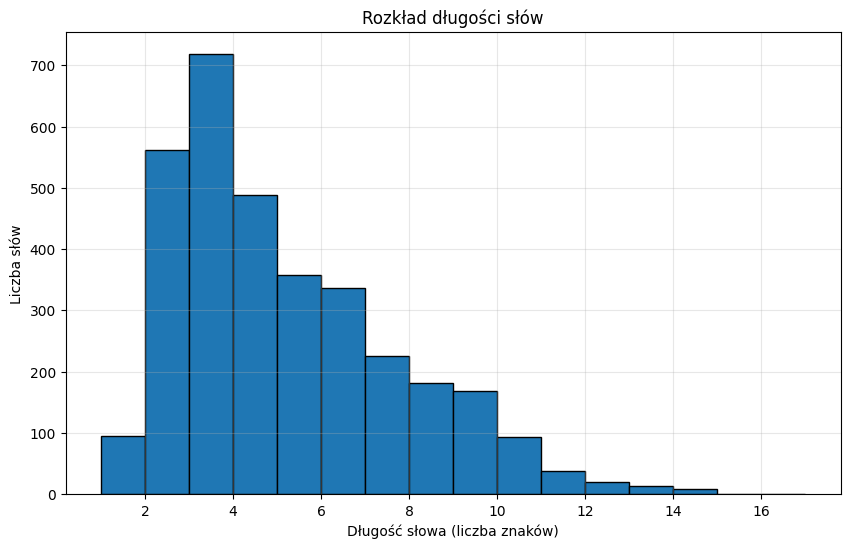

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
import spacy
from collections import Counter
import matplotlib.pyplot as plt

# Pobieranie zasobów NLTK
nltk.download('stopwords')
nltk.download('punkt')
stop_words = set(stopwords.words('english'))

# Ładowanie modelu spacy
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

def preprocess_text(text):
    """Przygotowuje tekst: tokenizacja, podział na zdania, lematyzacja."""
    # Podział na zdania
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if s.strip()]

    # Tokenizacja słów i obliczanie długości
    words = []
    word_lengths = []
    for sentence in sentences:
        doc = nlp(sentence.lower())
        sentence_words = [token.text for token in doc if token.is_alpha and not token.is_punct]
        words.extend(sentence_words)
        word_lengths.extend([len(word) for word in sentence_words])

    # Zliczanie znaków interpunkcyjnych
    punctuation = re.findall(r'[.,!?;:-]', text)

    return sentences, words, word_lengths, punctuation

def stylometric_analysis(sentences, words, word_lengths, punctuation):
    """Przeprowadza analizę stylometryczną."""
    # 1. Średnia długość słowa
    avg_word_length = sum(word_lengths) / len(word_lengths) if word_lengths else 0

    # 2. Średnia długość zdania (w słowach)
    sentence_lengths = [len(re.findall(r'\b\w+\b', sentence.lower())) for sentence in sentences]
    avg_sentence_length = sum(sentence_lengths) / len(sentence_lengths) if sentence_lengths else 0

    # 3. Różnorodność słownictwa (Type-Token Ratio)
    unique_words = len(set(words))
    total_words = len(words)
    ttr = (unique_words / total_words) * 100 if total_words > 0 else 0

    # 4. Częstotliwość słów funkcyjnych (stopwords)
    function_words = [word for word in words if word in stop_words]
    function_word_freq = (len(function_words) / total_words) * 100 if total_words > 0 else 0
    function_word_counts = Counter(function_words).most_common(5)

    # 5. Częstotliwość znaków interpunkcyjnych
    punctuation_freq = (len(punctuation) / total_words) * 100 if total_words > 0 else 0
    punctuation_counts = Counter(punctuation)

    # Wyniki
    results = {
        'avg_word_length': round(avg_word_length, 2),
        'avg_sentence_length': round(avg_sentence_length, 2),
        'ttr': round(ttr, 2),
        'function_word_freq': round(function_word_freq, 2),
        'function_word_counts': function_word_counts,
        'punctuation_freq': round(punctuation_freq, 2),
        'punctuation_counts': punctuation_counts,
        'word_lengths': word_lengths
    }
    return results

def plot_word_length_distribution(word_lengths):
    """Tworzy histogram rozkładu długości słów."""
    plt.figure(figsize=(10, 6))
    plt.hist(word_lengths, bins=range(min(word_lengths, default=1), max(word_lengths, default=1) + 2),
             edgecolor='black', color='#1f77b4')
    plt.title('Rozkład długości słów')
    plt.xlabel('Długość słowa (liczba znaków)')
    plt.ylabel('Liczba słów')
    plt.grid(True, alpha=0.3)
    plt.show()

# Tekst do analizy
text = """
www.respublica.pl
We, the people
Lech Wałęsa adresses joint session of the United States Congress
November 15, 1989
”For only the third time in history, a foreigner who is not a head of state addresses a joint meeting of the United States Congress. Lech Wałęsa visited Washington, D.C. just a few days after the fall of the Berlin Wall. He is a symbol of the bloodless and effective fight against communism. In his address, he notes that Poland’s ambitions for freedom – indeed, the whole region’s ambitions – have not yet been fulfilled. The transformation process can only be successful with the active involvement of the West.”

Mr. Speaker,
Mr. President,
members of the Cabinet,
distinguished members of the House and Senate.
“We the People”. With these words I wish to begin my address. I do not need to remind anyone here where these words come from. And I do not need to explain that I – an electrician from Gdansk – am also entitled to invoke them.
I stand before you as the third foreign non-head of state invited to address the joint Houses of Congress of the United States. This Congress, which, for many people in the world, oppressed and stripped of their rights, is a beacon of freedom and a bulwark of human rights. And here, I stand before you, to speak to America in the name of my nation. To speak to citizens of the country and the continent whose threshold is guarded by the famous Statue of Liberty. It is for me an honor so great, a moment so solemn, that I cannot find anything to compare it with.
People in Poland link the name of the United States with freedom and democracy, with generosity and high mindedness, with human friendship and friendly humanity. I realize that not everywhere is America so perceived. I speak of her image in Poland. This image has been strengthened by numerous favorable historical experiences, and it is very well known that Poles repay warm heartedness in kind.
The world remembers the wonderful principle of American democracy: “Government of the people, by the people, for the people.” I do remember these words. I, a shipyard worker from Gdańsk, have devoted my entire life, along with other members of the Solidarity movement, to the service of this idea: “Government of the people, by the people, for the people”. Against privilege and monopoly. Against violations of the law. Against the trampling of human dignity. Against contempt and injustice.
Such, in fact, are the principles and values reminiscent of Abraham Lincoln and the founding fathers of the American Republic, as well as the principles and ideas of the American Declaration of Independence and the American Constitution. These principles are pursued by the great Polish Solidarity movement; a movement that is effective.
I know that Americans are idealistic, but at the same time, practical people, endowed with common sense and capable of logical action. They combine these features with belief in the ultimate victory of right over wrong. But they prefer effective work to making speeches, and I understand them very well. I am not a fan of speeches. I prefer facts and work. I treasure effectiveness.
Ladies and gentleman, the fundamental and most important thing that I would like to tell you about is that the social movement bearing the beautiful name “Solidarity”, born of the Polish nation, is an effective movement. After many long years of struggle, it bore fruit and the results are there for all to see today. It set the direction and developed a way of action that has affected the lives of millions of people speaking different languages. It has swayed monopolies,
And the struggle was conducted without resorting to violence of any kind, a point that cannot be stressed too much. We were being locked up in prisons, deprived of our jobs, beaten, and sometimes killed. And we did not so much as strike a single person. We did not destroy anything. We did not smash a single window pane. But we were stubborn. Very stubborn. Ready to suffer, to make sacrifices. We knew what we wanted, and our power prevailed in the end.
The Solidarity movement received much support and scored victories, because at all times and in all matters, it opted for the better, more human, and more dignified solutions, standing against brutality and hate. It was a consistent and persistent movement, never giving up. And that is why after all these hard years, marked by so many tragic moments, Solidarity is today succeeding and showing the way to millions of people in Poland and other countries.
Ladies and gentleman, it was ten years ago, in August 1980, that the famous strike began in the Gdansk shipyards that led to the emergence of the first independent trade union in communist countries, and soon became a vast social movement, supported by the Polish nation. I was ten years younger then, unknown to anybody but my friends in the shipyard, and somewhat slimmer. And I must frankly say that it was important. I was an unemployed man at that time, fired from my job for earlier attempts to organize workers in the fight for their rights. I jumped over the shipyard wall and rejoined my former colleagues, who promptly appointed me leader of the strike. This is how it all began.
When I recall the road we travelled, I often think of that jump over the fence. Now others jump fences and tear down walls. They do it because freedom is a human right. But there is also another reflection that comes to mind when I think of the road behind us. In those days, at the beginning, many warnings, admonitions, and even condemnations reached us from many parts of the world.
“What are those Poles up to?” we heard. “They are mad!” “They are jeopardizing world peace and European stabilit!” “They ought to stay quiet and not get on anybody’s nerves”. From those voices we gathered that other nations have the right to live in comfort and prosperity, they have the right to democracy and freedom, and it is only Poles who should give up these rights so as not to disturb the peace of others.
In the days before the Second World War there were many people who asked: “Why should we die for Gdańsk, isn’t it better to stay home?” But war soon paid them a visit. And they had to start dying, for Paris, for London, for Hawaii. This time, too, there were many who complained: “There is that Gdansk again, disturbing our peace!”
But the recent developments in Gdańsk carried a different message. This is not the beginning, but the true end of that war. That was the beginning of a new, better, democratic, and safe era in the history of our world. It is no longer a question of “dying for Gdańsk”, but of “living for it”.
Looking at what is happening around us today, we may affirm that the path of struggle followed by Poland in quest of human rights, a struggle without violence and characterized by typical Polish stubbornness and firmness in the quest for pluralism and democracy, shows many people today, and even nations, how to avoid the greatest dangers of conflict.
If there is something threatening European stability today it is certainly not Poland. Poland is driving towards its own profound transformation; transformation achieved through peaceful means, through evolution, negotiated with all the parties concerned, which makes it possible to avoid the worst. And perhaps is held up as a model for many other regions. For, as we know, changes elsewhere are not so peaceful. Peacefully and prudently, with their eyes open to danger but not giving up what is right and necessary, the Poles gradually paved a way for historic transformations.
We are joined along this way, to various extents, by others: Hungarians and Russians, Ukrainians and the people from the Baltic states, Armenians and Georgians, and in recent days East Germans. We wish them luck and rejoice each success they achieve. We are certain that others will also take road we have followed, as there is no other choice!
So now I ask, is there is any sensible man understanding the world around him who could justifiably say today that it would be better for the Poles to keep quiet, because what they are doing is jeopardizing world peace? Could we even dare say that Poles are doing more to preserve and consolidate peace than many of their frightened advisors? Could we not say that stability and peace is under greater threat from countries which have not yet brought themselves to carry out far-reaching and comprehensive reforms, which do their utmost to preserve the old and disgraced ways of government, contrary to the wishes of their societies?
Things are different in Poland. And I must say that our task is viewed with understanding by our Eastern neighbors and their leader Mikhail Gorbachev. This understanding lays the foundation for new relations between Poland and the Soviet Union, relations which are much better than before. These improved mutual relations will also contribute to stabilization and peace in Europe, removing useless tensions.
The Poles have a long and difficult history, and no one wants more than we do peaceful coexistence and friendship with all nations and countries, and particularly with the Soviet Union. We believe that it is only now that the right and favorable conditions for such coexistence and friendship are emerging. Poland is making an important contribution to a better future for Europe, to European reconciliation. And also to the vast and important Polish-German reconciliation. To overcoming all the divisions and the strengthening of human rights on our continent. But it does not come easily for Poland.
In the Second World War, Poland was the first country to fall victim to aggression. Her losses in terms of human life and national property were the heaviest. Her fight was the longest; she was always a dedicated member of the victorious alliance and her soldiers fought in all the world theatres. In 1945 Poland was, theoretically speaking, one of the victors. Theory, however, had little in common with practice.
In practice, as her allies looked on in passive consent, an alien system of government was imposed in Poland, without a president in the Polish tradition, unaccepted by the nation, together with an alien economy, an alien law, and an alien philosophy of social relations. The legal Polish government, recognized by the nation, and leading the struggle of all Poles throughout the war was condemned, and those who remained faithful to it were subjected to the most ruthless persecution. Many were murdered. Thousands vanished somewhere into Russia’s East and North. Civilian repression without soldiers of the underground army that fought the Nazis. And it is only now that we are discovering their bones in unmarked graves scattered among the forests.
This was followed by persecutions of all those who dared to think independently. All the solemn pledges about free elections in Poland that were made in Yalta were broken. It was the second great national catastrophe following the catastrophe of 1939. When other nations were joyously celebrating victory, Poland was again sinking into mourning.
The awareness of this tragedy was doubly bitter, as the Poles realized that they had been abandoned by their allies. The memory of this is still strong in the minds of many. Nevertheless, the Poles took to rebuilding their devastated country, and in the first years following the war they were highly successful. But soon a new economic system was introduced, in which individual entrepreneurship ceased to exist, and the entire economy ended up in the hands of the state, run by people who were not elected by the nation.
Stalin forbade Poland to use aid provided by the Marshall Plan; aid that was used by everyone in Western Europe, including countries which lost the war. It is worth recalling now that great American plan which helped Western Europe to protect its freedom and peaceful order. And now is the moment when Eastern Europe awaits an investment of this kind, an investment in freedom, democracy, and peace. An investment adequate to the greatness of the American nation.
The Poles have travelled a long way. It would be worthwhile for all those commenting on Poland, often criticizing Poland, to bear in mind that, whatever Poland has achieved, she achieved through her own effort, through her own stubbornness, her own relentlessness. Everything was achieved thanks to the unflinching faith of our nation in human dignity, and in what is described as the values of Western culture and civilization. Our nation well knows the price of all this.
Ladies and gentleman, for the past fifty years, the Polish nation has been engaged in a difficult and exhausting battle. First to preserve its very biological existence. Later to save its national identity. In both instances, Polish determination was there. Today, Poland is rejoining the family of democratic and pluralistic countries, returning to the tradition of religious and European values. For the first time in half a century, Poland has a non-communist and independent government supported by the nation.
But in our past there looms a serious obstacle. A great danger. Our long subjection to a political system incompatible with national traditions, to an economic system incompatible with rationality and common sense, coupled with a stifling of independent thought and disregard for national interest has led the Polish economy to ruin, to the verge of utter catastrophe. The first government in fifty years elected by the people and serving the people has inherited from the previous rulers of the country the burden of an economy organized in a manner which prevents it from satisfying even the basic needs of its people.
The economy we inherited after almost five decades of communist rule is in need of overhaul. This will require patience and great sacrifice. This will require time and means. The present condition of the Polish economy is not due to change, as it is not specifically a Polish predicament. All the countries of the Eastern Bloc are bankrupt today. The communist economy has failed in every part of the world. One result of this is the exile of citizens of those countries, by land and by sea, by boat and by plane, swimming and walking across borders. This is a mass scale phenomenon, well known in Europe, Asia, and Central America.
But Poland has taken its new road and will never be turned back. The sense of our work and struggle in Poland lies in our creating situations and prospects that would hold Poles back from seeking a place for themselves abroad; that would encourage them to seek meaning in their work and hope for a better future in their own country, their own home. One sometimes hears that people in Poland do not care to work well. But even those who say this know that Poles work well and effectively, if only they see the sense and usefulness of their work. The working people know their arithmetic too. They are working much harder and in worse conditions than their opposite numbers abroad, and on top of that, they are paid much lower wages. The economic system around them is absurd. To make matters worse, every several or dozen years, the country suffered a new crisis, a new crunch, and time and time again it has turned out that past efforts went to waste. Show me the people who would have worked well stuck for decades under such a system. Wouldn’t they too have succumbed to pessimism?
The system has to be changed and the Poles have taken it upon themselves to change it. I know that America has her own problems and difficulties, some of them very serious. We are not asking for charity, we are not expecting philanthropy. But we would like to see our country treated as a partner and a friend. We would like cooperation under decent and favorable conditions. We would like Americans to come to us with proposals of cooperation, bringing benefits to both sides. We believe that assistance, extended to democracy and freedom in Poland and all of Eastern Europe, is the best investment in the future and in peace, better than tanks, warships, and warplanes; an investment leading to greater security.
Poland has already done much to patch up the divisions existing in Europe, to create better and more optimistic prospects. Poland’s efforts are viewed with sympathetic interest by the West; and for this thanks are in order. We believe that the West’s contribution to the process will now grow. We have heard many beautiful words of encouragement. These are appreciated, but being a worker and a man of concrete work I must tell you that the supply of words on the world market is plentiful, but the demand is falling. Let deeds follow words now.
The decision by the Congress of the United States about granting economic aid to my country opens a new road. For this wonderful decision, I thank you warmly. And I promise you that “this” aid will not be wasted and will never be forgotten.
Ladies and gentleman, from this podium I am expressing words of gratitude to the American people. It is they who supported us in the difficult days of Martial Law and persecution. It is they who sent us aid. They protested against violence. Today, when I am able to freely address the whole world from this elevated spot, I would like to thank them with special words. It is thanks to them that the world “Solidarity” soared across borders and has reached every corner of the world, and thanks to them the people of Solidarity were never alone.
In this chain of people linked to Solidarity there were many, many Americans. I wish to mention here with warm gratitude our friends from the United States Congress, the AFL-CIO trade unions, from the institutions and foundations supporting freedom and democracy, and all those who lent us support in our most difficult moments. They live in all states, in large and small communities of your vast country.
I thank all those who through the airwaves or printed word “spread the truth”. I also wish to say thank you and to greet all Polish-Americans who maintained warm contact with their old fatherland. Their support was always priceless for us.
I wholeheartedly thank the President of the United States and his administration for its involvement in my country’s affairs. I will never forget the then Vice-President, George Bush, speaking over the tomb of the reverent Jerzy Popiełuszko, the martyr of Poland. And I will never forget President George Bush speaking in Gdansk, in front of the monument of the falling shipyard workers. It is from there that the President of the United States was sending a message of freedom to Poland, to Europe, to the world.
Pope John Paul II once said: “Freedom is not just something to have and to use, it is something to be fought for; one must use freedom to build one’s personal life as well as the life of the nation.” I think this weighted thought can equally well be applied to Poland and America. I wish all of you to know and to keep in mind that the ideals which underline this glorious American Republic, and which are still alive here, are also alive and well in faraway Poland. And although for many long years efforts were made to cut Poland off from these ideals, she held her ground and is now reaching for the freedom to which she is justly entitled.
Together with Poland, other nations of Eastern Europe are following this path. The wall that separated people from freedom has collapsed.





  """

# Główna funkcja
def main():
    print("Analizowany tekst:")
    print(text)
    print("\n")

    # Przygotowanie tekstu
    sentences, words, word_lengths, punctuation = preprocess_text(text)

    # Analiza stylometryczna
    results = stylometric_analysis(sentences, words, word_lengths, punctuation)

    # Wyświetlenie wyników
    print("Wyniki analizy stylometrycznej:")
    print(f"1. Średnia długość słowa: {results['avg_word_length']} znaków")
    print(f"2. Średnia długość zdania: {results['avg_sentence_length']} słów")
    print(f"3. Różnorodność słownictwa (TTR): {results['ttr']}%")
    print(f"4. Częstotliwość słów funkcyjnych: {results['function_word_freq']}%")
    print("   Najczęściej występujące słowa funkcyjne:")
    for word, count in results['function_word_counts']:
        print(f"      - {word}: {count} razy")
    print(f"5. Częstotliwość znaków interpunkcyjnych: {results['punctuation_freq']}%")
    print("   Rozkład znaków interpunkcyjnych:")
    for punct, count in results['punctuation_counts'].items():
        print(f"      - {punct}: {count} razy")

    # Wizualizacja rozkładu długości słów
    print("\nGenerowanie histogramu długości słów...")
    plot_word_length_distribution(results['word_lengths'])

if __name__ == "__main__":
    main()

Analizowany tekst:
For only the third time in history, a foreigner who is not a head of state addresses a joint meeting of the United States Congress. Lech Walesa visited Washington, D.C. just a few days after the fall of the Berlin Wall. He is a symbol of the bloodless and effective fight against communism. In his address, he notes that Poland's ambitions for freedom - indeed, the whole region's ambitions - have not yet been fulfilled. The transformation process can only be successful with the active involvement of the West.


Podobieństwo semantyczne między zdaniami:
Zdanie 1: For only the third time in history, a foreigner who is not a head of state addresses a joint meeting of the United States Congress
Zdanie 2: Lech Walesa visited Washington, D
Zdanie 3: C
Zdanie 4: just a few days after the fall of the Berlin Wall
Zdanie 5: He is a symbol of the bloodless and effective fight against communism
Zdanie 6: In his address, he notes that Poland's ambitions for freedom - indeed, the wh

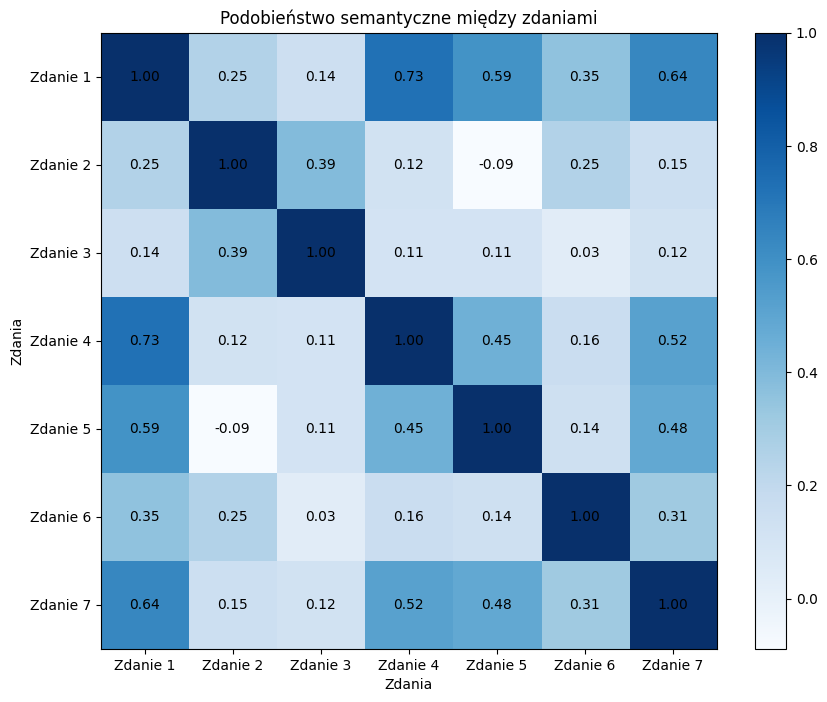

Generacja wykresu rozkładu typów jednostek...


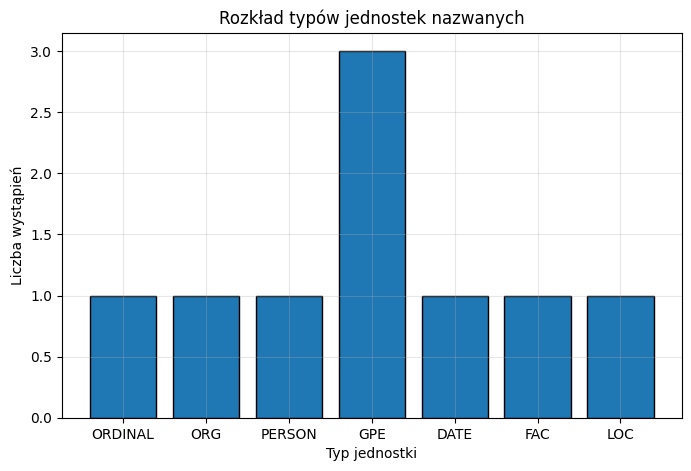

In [ ]:
import re
import spacy
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from collections import Counter

# Ładowanie modelu spacy
# Upewnij się, że model 'en_core_web_sm' jest zainstalowany:
# Wykonaj: !python -m spacy download en_core_web_sm
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    print("Błąd: Model 'en_core_web_sm' nie jest zainstalowany. Wykonaj: !python -m spacy download en_core_web_sm")
    raise

def preprocess_text(text):
    """Przygotowuje tekst: podział na zdania i tokenizacja."""
    # Podział na zdania
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if s.strip()]
    return sentences

def compute_sentence_similarity(sentences):
    """Oblicza podobieństwo semantyczne między zdaniami."""
    # Przetwarzanie zdań na wektory
    sentence_vectors = []
    for sentence in sentences:
        doc = nlp(sentence)
        # Obliczanie średniego wektora dla zdania (dla en_core_web_sm)
        vectors = [token.vector for token in doc if token.has_vector]
        if vectors:
            sentence_vector = np.mean(vectors, axis=0)
        else:
            sentence_vector = np.zeros(nlp.vocab.vectors.shape[1])
        sentence_vectors.append(sentence_vector)

    # Obliczanie podobieństwa kosinusowego
    similarity_matrix = cosine_similarity(sentence_vectors)

    return similarity_matrix

def ner_analysis(text):
    """Przeprowadza analizę jednostek nazwanych (NER)."""
    doc = nlp(text)
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    entity_counts = Counter(ent[1] for ent in entities)
    entity_details = Counter(entities)
    return entities, entity_counts, entity_details

def plot_similarity_heatmap(similarity_matrix, sentences):
    """Tworzy mapę cieplną dla podobieństwa semantycznego między zdaniami za pomocą matplotlib."""
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(similarity_matrix, cmap='Blues')

    # Dodanie etykiet
    ax.set_xticks(np.arange(len(sentences)))
    ax.set_yticks(np.arange(len(sentences)))
    ax.set_xticklabels([f"Zdanie {i+1}" for i in range(len(sentences))])
    ax.set_yticklabels([f"Zdanie {i+1}" for i in range(len(sentences))])

    # Dodanie wartości w komórkach
    for i in range(len(sentences)):
        for j in range(len(sentences)):
            text = ax.text(j, i, f"{similarity_matrix[i, j]:.2f}",
                           ha="center", va="center", color="black")

    # Dodanie tytułu i etykiet osi
    ax.set_title("Podobieństwo semantyczne między zdaniami")
    ax.set_xlabel("Zdania")
    ax.set_ylabel("Zdania")

    # Dodanie paska kolorów
    plt.colorbar(im)
    plt.show()

def plot_entity_distribution(entity_counts):
    """Tworzy wykres słupkowy dla typów jednostek nazwanych."""
    labels = list(entity_counts.keys())
    counts = list(entity_counts.values())
    plt.figure(figsize=(8, 5))
    plt.bar(labels, counts, color='#1f77b4', edgecolor='black')
    plt.title('Rozkład typów jednostek nazwanych')
    plt.xlabel('Typ jednostki')
    plt.ylabel('Liczba wystąpień')
    plt.grid(True, alpha=0.3)
    plt.show()

# Tekst do analizy
text = """For only the third time in history, a foreigner who is not a head of state addresses a joint meeting of the United States Congress. Lech Walesa visited Washington, D.C. just a few days after the fall of the Berlin Wall. He is a symbol of the bloodless and effective fight against communism. In his address, he notes that Poland's ambitions for freedom - indeed, the whole region's ambitions - have not yet been fulfilled. The transformation process can only be successful with the active involvement of the West."""

# Główna funkcja
def main():
    print("Analizowany tekst:")
    print(text)
    print("\n")

    # Przygotowanie tekstu
    sentences = preprocess_text(text)

    # Analiza podobieństwa semantycznego
    print("Podobieństwo semantyczne między zdaniami:")
    similarity_matrix = compute_sentence_similarity(sentences)
    for i, sentence in enumerate(sentences):
        print(f"Zdanie {i+1}: {sentence}")
    print("\nMacierz podobieństwa:")
    for i, row in enumerate(similarity_matrix):
        print(f"Zdanie {i+1}: {[round(val, 2) for val in row]}")

    # Analiza NER
    entities, entity_counts, entity_details = ner_analysis(text)
    print("\nZidentyfikowane jednostki nazwane:")
    for entity, label in entities:
        print(f" - {entity}: {label}")
    print("\nLiczba wystąpień typów jednostek:")
    for label, count in entity_counts.items():
        print(f" - {label}: {count}")
    print("\nSzczegółowy rozkład jednostek:")
    for (entity, label), count in entity_details.items():
        print(f" - {entity} ({label}): {count} razy")

    # Wizualizacje
    print("\nGenerowanie mapy cieplnej podobieństwa semantycznego...")
    plot_similarity_heatmap(similarity_matrix, sentences)
    print("Generacja wykresu rozkładu typów jednostek...")
    plot_entity_distribution(entity_counts)

if __name__ == "__main__":
    main()

Analizowany tekst:

https://jp2online.pl/obiekt/i-pielgrzymka-do-polski;-przemowienie-jana-pawla-ii-do-wladz-panstwowych-wygloszone-w-belwederze-podczas;-warszawa-2-czerwca-1979-r-;T2JqZWN0OjIwOQ==

Niech będzie pochwalony Jezus Chrystus!
Umiłowani Rodacy,
Drodzy Bracia i Siostry,
Uczestnicy eucharystycznej Ofiary, która sprawuje się dziś w Warszawie na placu Zwycięstwa,
1. Razem z wami pragnę wyśpiewać pieśń dziękczynienia dla Opatrzności, która pozwala mi dziś jako pielgrzymowi stanąć na tym miejscu.
Pragnął – wiemy, że bardzo gorąco pragnął – stanąć na ziemi polskiej, przede wszystkim na Jasnej Górze, zmarły niedawno papież Paweł VI. Pierwszy po wielu stuleciach papież-pielgrzym. Do końca życia nosił to pragnienie w swoim sercu i z nim zszedł do grobu. I oto czujemy, że pragnienie to było tak potężne i tak głęboko uzasadnione, że przerosło ramy jednego pontyfikatu i – w sposób po ludzku trudny do przewidzenia – realizuje się dzisiaj. Dziękujemy więc Bożej Opatrzności za to, że dała 

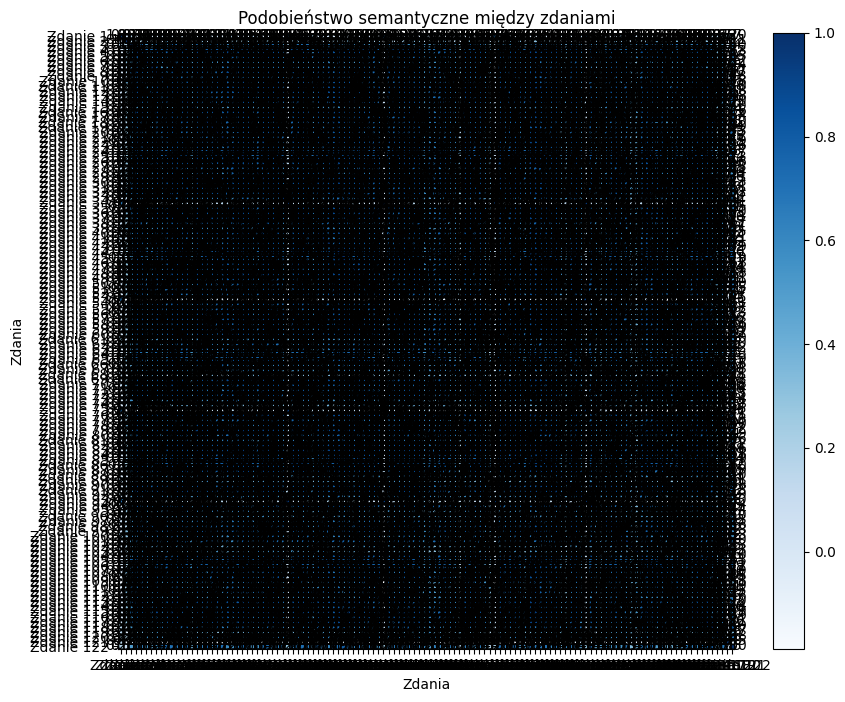

Generacja wykresu rozkładu typów jednostek...


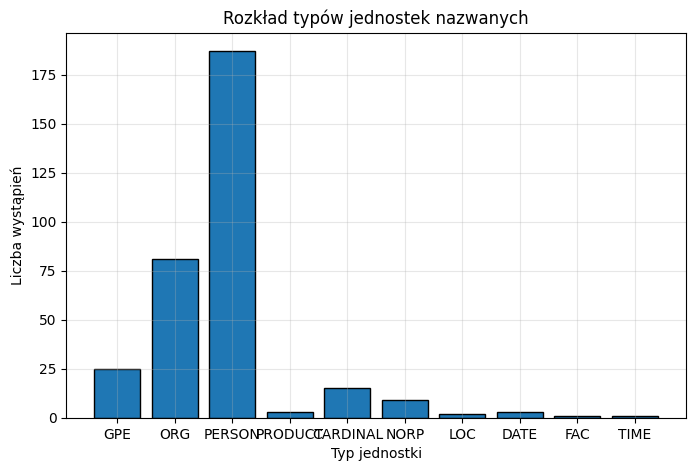

In [ ]:
import re
import spacy
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from collections import Counter

# Ładowanie modelu spacy
# Upewnij się, że model 'en_core_web_sm' jest zainstalowany:
# Wykonaj: !python -m spacy download en_core_web_sm
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    print("Błąd: Model 'en_core_web_sm' nie jest zainstalowany. Wykonaj: !python -m spacy download en_core_web_sm")
    raise

def preprocess_text(text):
    """Przygotowuje tekst: podział na zdania i tokenizacja."""
    # Podział na zdania
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if s.strip()]
    return sentences

def compute_sentence_similarity(sentences):
    """Oblicza podobieństwo semantyczne między zdaniami."""
    # Przetwarzanie zdań na wektory
    sentence_vectors = []
    for sentence in sentences:
        doc = nlp(sentence)
        # Obliczanie średniego wektora dla zdania (dla en_core_web_sm)
        vectors = [token.vector for token in doc if token.has_vector]
        if vectors:
            sentence_vector = np.mean(vectors, axis=0)
        else:
            sentence_vector = np.zeros(nlp.vocab.vectors.shape[1])
        sentence_vectors.append(sentence_vector)

    # Obliczanie podobieństwa kosinusowego
    similarity_matrix = cosine_similarity(sentence_vectors)

    return similarity_matrix

def ner_analysis(text):
    """Przeprowadza analizę jednostek nazwanych (NER)."""
    doc = nlp(text)
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    entity_counts = Counter(ent[1] for ent in entities)
    entity_details = Counter(entities)
    return entities, entity_counts, entity_details

def plot_similarity_heatmap(similarity_matrix, sentences):
    """Tworzy mapę cieplną dla podobieństwa semantycznego między zdaniami za pomocą matplotlib."""
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(similarity_matrix, cmap='Blues')

    # Dodanie etykiet
    ax.set_xticks(np.arange(len(sentences)))
    ax.set_yticks(np.arange(len(sentences)))
    ax.set_xticklabels([f"Zdanie {i+1}" for i in range(len(sentences))])
    ax.set_yticklabels([f"Zdanie {i+1}" for i in range(len(sentences))])

    # Dodanie wartości w komórkach
    for i in range(len(sentences)):
        for j in range(len(sentences)):
            text = ax.text(j, i, f"{similarity_matrix[i, j]:.2f}",
                           ha="center", va="center", color="black")

    # Dodanie tytułu i etykiet osi
    ax.set_title("Podobieństwo semantyczne między zdaniami")
    ax.set_xlabel("Zdania")
    ax.set_ylabel("Zdania")

    # Dodanie paska kolorów
    plt.colorbar(im)
    plt.show()

def plot_entity_distribution(entity_counts):
    """Tworzy wykres słupkowy dla typów jednostek nazwanych."""
    labels = list(entity_counts.keys())
    counts = list(entity_counts.values())
    plt.figure(figsize=(8, 5))
    plt.bar(labels, counts, color='#1f77b4', edgecolor='black')
    plt.title('Rozkład typów jednostek nazwanych')
    plt.xlabel('Typ jednostki')
    plt.ylabel('Liczba wystąpień')
    plt.grid(True, alpha=0.3)
    plt.show()

# Tekst do analizy
text = """
https://jp2online.pl/obiekt/i-pielgrzymka-do-polski;-przemowienie-jana-pawla-ii-do-wladz-panstwowych-wygloszone-w-belwederze-podczas;-warszawa-2-czerwca-1979-r-;T2JqZWN0OjIwOQ==

Niech będzie pochwalony Jezus Chrystus!
Umiłowani Rodacy,
Drodzy Bracia i Siostry,
Uczestnicy eucharystycznej Ofiary, która sprawuje się dziś w Warszawie na placu Zwycięstwa,
1. Razem z wami pragnę wyśpiewać pieśń dziękczynienia dla Opatrzności, która pozwala mi dziś jako pielgrzymowi stanąć na tym miejscu.
Pragnął – wiemy, że bardzo gorąco pragnął – stanąć na ziemi polskiej, przede wszystkim na Jasnej Górze, zmarły niedawno papież Paweł VI. Pierwszy po wielu stuleciach papież-pielgrzym. Do końca życia nosił to pragnienie w swoim sercu i z nim zszedł do grobu. I oto czujemy, że pragnienie to było tak potężne i tak głęboko uzasadnione, że przerosło ramy jednego pontyfikatu i – w sposób po ludzku trudny do przewidzenia – realizuje się dzisiaj. Dziękujemy więc Bożej Opatrzności za to, że dała Pawłowi VI tak potężne pragnienie. Dziękujemy za cały ten styl papieża-pielgrzyma, jaki zapoczątkował wraz z Soborem Watykańskim II. Gdy bowiem Kościół cały uświadomił sobie na nowo, iż jest Ludem Bożym – Ludem, który uczestniczy w posłannictwie Chrystusa, Ludem, który z tym posłannictwem idzie przez dzieje, który „pielgrzymuje”, papież nie mógł dłużej pozostać „więźniem Watykanu”. Musiał stać się na nowo Piotrem pielgrzymującym, tak jak ten pierwszy, który z Jerozolimy przywędrował poprzez Antiochię do Rzymu, aby tam dać świadectwo Chrystusowi i przypieczętować je swoją krwią.
Dzisiaj dane mi jest wypełnić to pragnienie zmarłego papieża Pawła VI wśród was, umiłowani synowie i córki mojej Ojczyzny. Kiedy bowiem – z niezbadanych wyroków Bożej Opatrzności po śmierci Pawła VI i po kilkutygodniowym zaledwie pontyfikacie mojego bezpośredniego poprzednika Jana Pawła I – zostałem głosami kardynałów wezwany ze stolicy św. Stanisława w Krakowie na stolicę św. Piotra w Rzymie, zrozumiałem natychmiast, że moim szczególnym zadaniem jest spełnienie tego pragnienia, którego Paweł VI nie mógł dopełnić na milenium chrztu Polski.
Jako więc wasz rodak, syn polskiej ziemi, a zarazem jako papież-pielgrzym witam was wszystkich! Witam najdostojniejszego Prymasa Polski. Witam wszystkich obecnych tutaj arcybiskupów, biskupów, pasterzy Kościoła w naszej Ojczyźnie. Pozwólcie, że pośród naszych gości powitam w sposób szczególny kardynała-arcybiskupa Santo Domingo. To tam wypadało mi skierować pierwsze kroki papieskiego pielgrzymowania w miesiącu styczniu. Tam po raz pierwszy ucałowałem ziemię, na której stanęła kiedyś stopa Krzysztofa Kolumba, po której przeszły stopy tylu głosicieli Ewangelii, a wśród nich także i naszych rodaków i polskich żołnierzy. Dzisiaj, wspólnie z wami, tego świadka mojej pierwszej papieskiej podróży witam w Warszawie.
Czyż moja pielgrzymka do Ojczyzny w roku, w którym Kościół w Polsce obchodzi dziewięćsetną rocznicę śmierci św. Stanisława, nie jest zarazem jakimś szczególnym znakiem naszego polskiego pielgrzymowania poprzez dzieje Kościoła – nie tylko po szlakach naszej Ojczyzny, ale zarazem Europy i świata? Odsuwam tutaj na bok moją własną osobę – niemniej muszę wraz z wami wszystkimi stawiać sobie pytanie o motyw, dla którego właśnie w roku 1978 (po tylu stuleciach ustalonej w tej dziedzinie tradycji) został na rzymską stolicę św. Piotra wezwany syn polskiego narodu, polskiej ziemi. Od Piotra, jak i od wszystkich apostołów Chrystus żądał, aby byli Jego „świadkami w Jerozolimie i w całej Judei, i w Samarii, i aż po krańce ziemi” (Dz 1,8).
Czyż przeto nawiązując do tych Chrystusowych słów, nie wolno nam wnosić zarazem, że Polska stała się w naszych czasach ziemią szczególnie odpowiedzialnego świadectwa? Że właśnie stąd – z Warszawy, a także z Gniezna, z Jasnej Góry, z Krakowa, z całego tego historycznego szlaku, który tyle razy nawiedzałem w swoim życiu i który w tych dniach znów będę miał szczęście nawiedzić, że właśnie stąd ze szczególną pokorą, ale i ze szczególnym przekonaniem trzeba głosić Chrystusa? Że właśnie tu, na tej ziemi, na tym szlaku, trzeba stanąć, aby odczytać świadectwo Jego Krzyża i Jego Zmartwychwstania? Ale, umiłowani rodacy – jeśli przyjąć to wszystko, co w tej chwili ośmieliłem się wypowiedzieć – jakżeż ogromne z tego rodzą się zadania i zobowiązania! Czy do nich naprawdę dorastamy?
2. Dane mi jest dzisiaj, na pierwszym etapie mojej papieskiej pielgrzymki do Polski, sprawować Najświętszą Ofiarę w Warszawie, na placu Zwycięstwa. Liturgia sobotniego wieczoru, w przeddzień Zesłania Ducha Świętego przenosi nas do wieczernika w Jerozolimie, w którym nazajutrz apostołowie – zgromadzeni wokół Maryi, Matki Chrystusa – mają otrzymać Ducha Świętego. Otrzymają Ducha, którego Chrystus im wyjednał przez krzyż, aby w mocy tego Ducha mogli wypełnić Jego polecenie. „Idźcie więc i nauczajcie wszystkie narody, udzielając im chrztu w imię Ojca i Syna, i Ducha Świętego. Uczcie je zachowywać wszystko, co wam przykazałem” (Mt 28,19-20). W takich słowach Chrystus Pan przed swym odejściem ze świata przekazał apostołom swe ostatnie polecenie, swój „mandat misyjny”. I dodał: „A oto Ja jestem z wami przez wszystkie dni aż do skończenia świata” (Mt 28,20).
Dobrze się stało, że moja pielgrzymka do Polski, związana z dziewięćsetną rocznicą męczeńskiej śmierci św. Stanisława, wypadła w okresie Zesłania Ducha Świętego oraz uroczystości Trójcy Przenajświętszej. W taki bowiem sposób mogę, dopełniając jakby pośmiertnie pragnienia Pawła VI, przeżyć raz jeszcze tysiąclecie chrztu na ziemi polskiej i wpisać tegoroczny Stanisławowy jubileusz w to tysiąclecie, z którego wzięły początek całe dzieje narodu i Kościoła. Właśnie uroczystość Zesłania Ducha Świętego oraz Trójcy Przenajświętszej szczególnie nas przybliża do tego początku. W apostołach, którzy otrzymują Ducha Świętego w dzień Zielonych Świąt, są już niejako duchowo obecni wszyscy ich następcy, wszyscy biskupi, również ci, którym od tysiąca lat wypadło głosić Ewangelię na ziemi polskiej. Również ten Stanisław ze Szczepanowa, który swoje posłannictwo na stolicy krakowskiej okupił krwią przed dziewięcioma wiekami.
I są w tych apostołach i wokół nich – w dniu Zesłania Ducha Świętego – zgromadzeni nie tylko przedstawiciele tych ludów i języków, które wymienia księga Dziejów Apostolskich. Są wokół nich już wówczas zgromadzone różne ludy i narody, które przyjdą do Kościoła poprzez światło Ewangelii i moc Ducha Świętego w różnych epokach, w różnych stuleciach. Dzień Zielonych Świąt jest dniem narodzin wiary i Kościoła również na naszej polskiej ziemi. Jest to początek przepowiadania wielkich spraw Bożych również w naszym polskim języku. Jest to początek chrześcijaństwa również w życiu naszego narodu: w jego dziejach, w jego kulturze, w jego doświadczeniach.
3. Kościół przyniósł Polsce Chrystusa – to znaczy klucz do rozumienia tej wielkiej i podstawowej rzeczywistości, jaką jest człowiek. Człowieka bowiem nie można do końca zrozumieć bez Chrystusa. A raczej: człowiek nie może siebie sam do końca zrozumieć bez Chrystusa. Nie może zrozumieć ani kim jest, ani jaka jest jego właściwa godność, ani jakie jest jego powołanie i ostateczne przeznaczenie. Nie może tego wszystkiego zrozumieć bez Chrystusa.
I dlatego Chrystusa nie można wyłączać z dziejów człowieka w jakimkolwiek miejscu ziemi. Nie można też bez Chrystusa zrozumieć dziejów Polski – przede wszystkim jako dziejów ludzi, którzy przeszli i przechodzą przez tę ziemię. Dzieje ludzi! Dzieje narodu są przede wszystkim dziejami ludzi. A dzieje każdego człowieka toczą się w Jezusie Chrystusie. W Nim stają się dziejami zbawienia.
Dzieje narodu zasługują na właściwą ocenę wedle tego, co wniósł on w rozwój człowieka i człowieczeństwa, w jego świadomość, serce, sumienie. To jest najgłębszy nurt kultury. To jej najmocniejszy zrąb. To jej rdzeń i siła. Otóż tego, co naród polski wniósł w rozwój człowieka i człowieczeństwa, co w ten rozwój również dzisiaj wnosi, nie sposób zrozumieć i ocenić bez Chrystusa. „Ten stary dąb tak urósł, a wiatr go żaden nie obalił, bo korzeń jego jest Chrystus” (Piotr Skarga, Kazania sejmowe). Trzeba iść po śladach tego, czym – a raczej kim – na przestrzeni pokoleń był Chrystus dla synów i córek tej ziemi. I to nie tylko dla tych, którzy jawnie weń wierzyli, którzy Go wyznawali wiarą Kościoła. Ale także i dla tych, pozornie stojących opodal, poza Kościołem. Dla tych wątpiących, dla tych sprzeciwiających się.
3. Jeśli jest rzeczą słuszną, aby dzieje narodu rozumieć poprzez każdego człowieka w tym narodzie – to równocześnie nie sposób zrozumieć człowieka inaczej jak w tej wspólnocie, którą jest jego naród. Wiadomo, że nie jest to wspólnota jedyna. Jest to jednakże wspólnota szczególna, najbliżej chyba związana z rodziną, najważniejsza dla dziejów duchowych człowieka. Otóż nie sposób zrozumieć dziejów narodu polskiego – tej wielkiej tysiącletniej wspólnoty, która tak głęboko stanowi o mnie, o każdym z nas – bez Chrystusa. Jeślibyśmy odrzucili ten klucz dla zrozumienia naszego narodu, narazilibyśmy się na zasadnicze nieporozumienie. Nie rozumielibyśmy samych siebie. Nie sposób zrozumieć tego narodu, który miał przeszłość tak wspaniałą, ale zarazem tak straszliwie trudną – bez Chrystusa. Nie sposób zrozumieć tego miasta, Warszawy, stolicy Polski, która w roku 1944 zdecydowała się na nierówną walkę z najeźdźcą, na walkę, w której została opuszczona przez sprzymierzone potęgi, na walkę, w której legła pod własnymi gruzami, jeśli się nie pamięta, że pod tymi samymi gruzami legł również Chrystus-Zbawiciel ze swoim krzyżem sprzed kościoła na Krakowskim Przedmieściu. Nie sposób zrozumieć dziejów Polski od Stanisława na Skałce do Maksymiliana Kolbe w Oświęcimiu, jeśli się nie przyłoży do nich tego jeszcze jednego i tego podstawowego kryterium, któremu na imię Jezus Chrystus.
Tysiąclecie chrztu Polski, którego szczególnie dojrzałym owocem jest św. Stanisław – tysiąclecie Chrystusa w naszym wczoraj i dzisiaj – jest głównym motywem mojej pielgrzymki, mojej dziękczynnej modlitwy wspólnie z wami wszystkimi, drodzy rodacy, których Jezus Chrystus nie przestaje uczyć wielkiej sprawy człowieka. Z wami, dla których Chrystus nie przestaje być wciąż otwartą księgą nauki o człowieku, o jego godności i jego prawach. A zarazem nauki o godności i prawach narodu.
Księże Prymasie! Pragnę tę Najświętszą Ofiarę wspólnie z braćmi biskupami i kapłanami złożyć we wszystkich intencjach, które Wasza Eminencja wymienił na początku.
W dniu dzisiejszym na tym placu Zwycięstwa w stolicy Polski proszę wielką modlitwą Eucharystii wspólnie z wami, aby Chrystus nie przestał być dla nas otwartą księgą życia na przyszłość. Na nasze polskie jutro.
4. Stoimy tutaj w pobliżu Grobu Nieznanego Żołnierza. W dziejach Polski – dawnych i współczesnych – grób ten znajduje szczególne pokrycie. Szczególne uzasadnienie. Na ilu to miejscach ziemi ojczystej padał ten żołnierz. Na ilu to miejscach Europy i świata przemawiał swoją śmiercią, że nie może być Europy sprawiedliwej bez Polski niepodległej na jej mapie? Na ilu to polach walk świadczył oprawach człowieka wpisanych głęboko w nienaruszalne prawa narodu, ginąc „za wolność naszą i waszą”? „Gdzie są ich groby, Polsko! Gdzie ich nie ma! Ty wiesz najlepiej – i Bóg wie na niebie!” (Artur Oppman, Pacierz za zmarłych).
Dzieje Ojczyzny napisane przez Grób jednego Nieznanego Żołnierza.
Przyklęknąłem przy tym grobie, wspólnie z Księdzem Prymasem, aby oddać cześć każdemu ziarnu, które – padając w ziemię i obumierając w niej – przynosi owoc. Czy to będzie ziarno krwi żołnierskiej przelanej na polu bitwy, czy ofiara męczeńska w obozach i więzieniach. Czy to będzie ziarno ciężkiej, codziennej pracy w pocie czoła na roli, przy warsztacie, w kopalni, w hutach i fabrykach. Czy to będzie ziarno miłości rodzicielskiej, która nie cofa się przed daniem życia nowemu człowiekowi i podejmuje cały trud wychowawczy. Czy to będzie ziarno pracy twórczej w uczelniach, instytutach, bibliotekach, na warsztatach narodowej kultury. Czy to będzie ziarno modlitwy i posługi przy chorych, cierpiących, opuszczonych. Czy to będzie ziarno samego cierpienia na łożach szpitalnych, w klinikach, sanatoriach, po domach: „wszystko, co Polskę stanowi”. Skąd przychodzą te słowa? Księże Prymasie, tak głosi Akt milenijny, złożony przez ciebie i Episkopat Polski na Jasnej Górze: „wszystko, co Polskę stanowi”.
To wszystko w rękach Bogarodzicy – pod krzyżem na Kalwarii i w wieczerniku Zielonych Świąt.
To wszystko: dzieje Ojczyzny, tworzone przez każdego jej syna i każdą córkę od tysiąca lat – i w tym pokoleniu, i w przyszłych – choćby to był człowiek bezimienny i nieznany, tak jak ten żołnierz, przy którego grobie stoimy… To wszystko: i dzieje ludów, które żyły wraz z nami i wśród nas, jak choćby ci, których setki tysięcy zginęły w murach warszawskiego getta.
To wszystko w tej Eucharystii ogarniam myślą i sercem i włączam w tę jedną jedyną Najświętszą Ofiarę Chrystusa na placu Zwycięstwa.
I wołam, ja, syn polskiej ziemi, a zarazem ja: Jan Paweł II papież, wołam z całej głębi tego tysiąclecia, wołam w przeddzień święta Zesłania, wołam wraz z wami wszystkimi:
Niech zstąpi Duch Twój!
Niech zstąpi Duch Twój!
I odnowi oblicze ziemi.
Tej Ziemi! Amen.
Jan Paweł II




"""


# Główna funkcja
def main():
    print("Analizowany tekst:")
    print(text)
    print("\n")

    # Przygotowanie tekstu
    sentences = preprocess_text(text)

    # Analiza podobieństwa semantycznego
    print("Podobieństwo semantyczne między zdaniami:")
    similarity_matrix = compute_sentence_similarity(sentences)
    for i, sentence in enumerate(sentences):
        print(f"Zdanie {i+1}: {sentence}")
    print("\nMacierz podobieństwa:")
    for i, row in enumerate(similarity_matrix):
        print(f"Zdanie {i+1}: {[round(val, 2) for val in row]}")

    # Analiza NER
    entities, entity_counts, entity_details = ner_analysis(text)
    print("\nZidentyfikowane jednostki nazwane:")
    for entity, label in entities:
        print(f" - {entity}: {label}")
    print("\nLiczba wystąpień typów jednostek:")
    for label, count in entity_counts.items():
        print(f" - {label}: {count}")
    print("\nSzczegółowy rozkład jednostek:")
    for (entity, label), count in entity_details.items():
        print(f" - {entity} ({label}): {count} razy")

    # Wizualizacje
    print("\nGenerowanie mapy cieplnej podobieństwa semantycznego...")
    plot_similarity_heatmap(similarity_matrix, sentences)
    print("Generacja wykresu rozkładu typów jednostek...")
    plot_entity_distribution(entity_counts)

if __name__ == "__main__":
    main()

Analizowany tekst:
For only the third time in history, a foreigner who is not a head of state addresses a joint meeting of the United States Congress. Lech Walesa visited Washington, D.C. just a few days after the fall of the Berlin Wall. He is a symbol of the bloodless and effective fight against communism. In his address, he notes that Poland's ambitions for freedom - indeed, the whole region's ambitions - have not yet been fulfilled. The transformation process can only be successful with the active involvement of the West.


Podobieństwo semantyczne między zdaniami:
Zdanie 1: For only the third time in history, a foreigner who is not a head of state addresses a joint meeting of the United States Congress
Zdanie 2: Lech Walesa visited Washington, D
Zdanie 3: C
Zdanie 4: just a few days after the fall of the Berlin Wall
Zdanie 5: He is a symbol of the bloodless and effective fight against communism
Zdanie 6: In his address, he notes that Poland's ambitions for freedom - indeed, the wh

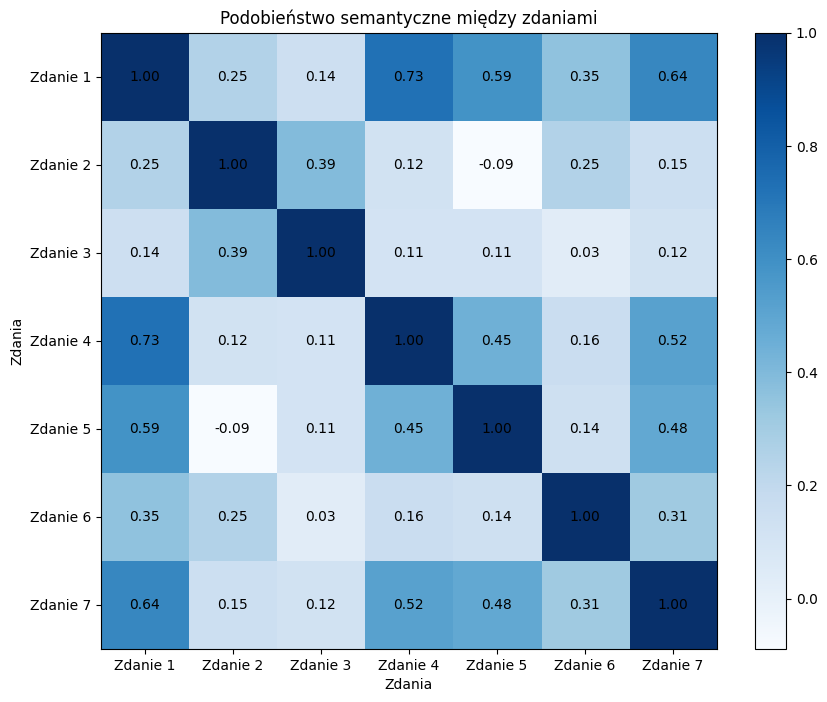

Generacja wykresu rozkładu typów jednostek...


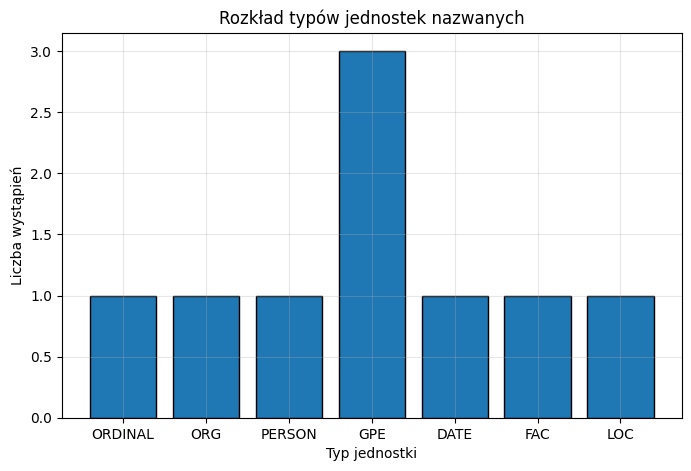

In [ ]:
import re
import spacy
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from collections import Counter

# Ładowanie modelu spacy
# Upewnij się, że model 'en_core_web_sm' jest zainstalowany:
# Wykonaj: !python -m spacy download en_core_web_sm
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    print("Błąd: Model 'en_core_web_sm' nie jest zainstalowany. Wykonaj: !python -m spacy download en_core_web_sm")
    raise

def preprocess_text(text):
    """Przygotowuje tekst: podział na zdania i tokenizacja."""
    # Podział na zdania
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if s.strip()]
    return sentences

def compute_sentence_similarity(sentences):
    """Oblicza podobieństwo semantyczne między zdaniami."""
    # Przetwarzanie zdań na wektory
    sentence_vectors = []
    for sentence in sentences:
        doc = nlp(sentence)
        # Obliczanie średniego wektora dla zdania (dla en_core_web_sm)
        vectors = [token.vector for token in doc if token.has_vector]
        if vectors:
            sentence_vector = np.mean(vectors, axis=0)
        else:
            sentence_vector = np.zeros(nlp.vocab.vectors.shape[1])
        sentence_vectors.append(sentence_vector)

    # Obliczanie podobieństwa kosinusowego
    similarity_matrix = cosine_similarity(sentence_vectors)

    return similarity_matrix

def ner_analysis(text):
    """Przeprowadza analizę jednostek nazwanych (NER)."""
    doc = nlp(text)
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    entity_counts = Counter(ent[1] for ent in entities)
    entity_details = Counter(entities)
    return entities, entity_counts, entity_details

def plot_similarity_heatmap(similarity_matrix, sentences):
    """Tworzy mapę cieplną dla podobieństwa semantycznego między zdaniami za pomocą matplotlib."""
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(similarity_matrix, cmap='Blues')

    # Dodanie etykiet
    ax.set_xticks(np.arange(len(sentences)))
    ax.set_yticks(np.arange(len(sentences)))
    ax.set_xticklabels([f"Zdanie {i+1}" for i in range(len(sentences))])
    ax.set_yticklabels([f"Zdanie {i+1}" for i in range(len(sentences))])

    # Dodanie wartości w komórkach
    for i in range(len(sentences)):
        for j in range(len(sentences)):
            text = ax.text(j, i, f"{similarity_matrix[i, j]:.2f}",
                           ha="center", va="center", color="black")

    # Dodanie tytułu i etykiet osi
    ax.set_title("Podobieństwo semantyczne między zdaniami")
    ax.set_xlabel("Zdania")
    ax.set_ylabel("Zdania")

    # Dodanie paska kolorów
    plt.colorbar(im)
    plt.show()

def plot_entity_distribution(entity_counts):
    """Tworzy wykres słupkowy dla typów jednostek nazwanych."""
    labels = list(entity_counts.keys())
    counts = list(entity_counts.values())
    plt.figure(figsize=(8, 5))
    plt.bar(labels, counts, color='#1f77b4', edgecolor='black')
    plt.title('Rozkład typów jednostek nazwanych')
    plt.xlabel('Typ jednostki')
    plt.ylabel('Liczba wystąpień')
    plt.grid(True, alpha=0.3)
    plt.show()

# Tekst do analizy
text = """For only the third time in history, a foreigner who is not a head of state addresses a joint meeting of the United States Congress. Lech Walesa visited Washington, D.C. just a few days after the fall of the Berlin Wall. He is a symbol of the bloodless and effective fight against communism. In his address, he notes that Poland's ambitions for freedom - indeed, the whole region's ambitions - have not yet been fulfilled. The transformation process can only be successful with the active involvement of the West."""

# Główna funkcja
def main():
    print("Analizowany tekst:")
    print(text)
    print("\n")

    # Przygotowanie tekstu
    sentences = preprocess_text(text)

    # Analiza podobieństwa semantycznego
    print("Podobieństwo semantyczne między zdaniami:")
    similarity_matrix = compute_sentence_similarity(sentences)
    for i, sentence in enumerate(sentences):
        print(f"Zdanie {i+1}: {sentence}")
    print("\nMacierz podobieństwa:")
    for i, row in enumerate(similarity_matrix):
        print(f"Zdanie {i+1}: {[round(val, 2) for val in row]}")

    # Analiza NER
    entities, entity_counts, entity_details = ner_analysis(text)
    print("\nZidentyfikowane jednostki nazwane:")
    for entity, label in entities:
        print(f" - {entity}: {label}")
    print("\nLiczba wystąpień typów jednostek:")
    for label, count in entity_counts.items():
        print(f" - {label}: {count}")
    print("\nSzczegółowy rozkład jednostek:")
    for (entity, label), count in entity_details.items():
        print(f" - {entity} ({label}): {count} razy")

    # Wizualizacje
    print("\nGenerowanie mapy cieplnej podobieństwa semantycznego...")
    plot_similarity_heatmap(similarity_matrix, sentences)
    print("Generacja wykresu rozkładu typów jednostek...")
    plot_entity_distribution(entity_counts)

if __name__ == "__main__":
    main()